Device: cuda
Training Version 189...

Epoch 1/2 Loss 0.2363
Epoch 2/2 Loss 0.0645


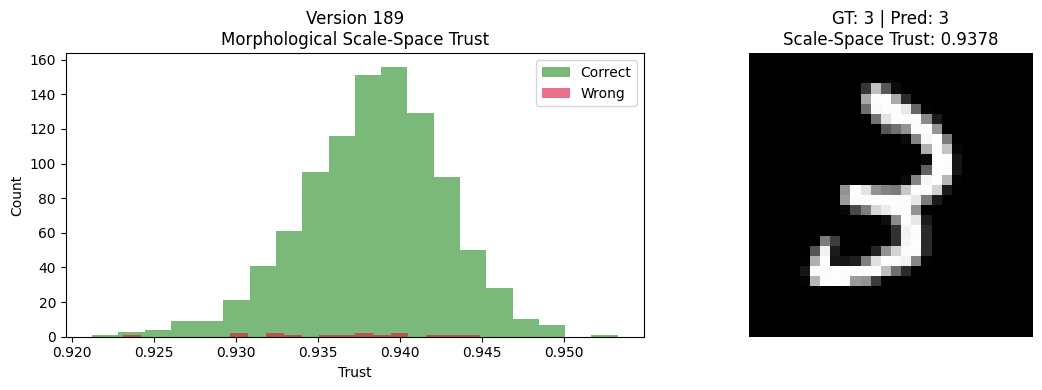


Accuracy on tested subset: 98.40%


In [2]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 189 (FIXED)
# Morphological Scale-Space Invariance Trust
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(189)
np.random.seed(189)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda")
)

# ==========================================================
# Model
# ==========================================================

class ScaleSpaceNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(inplace=True)
        )

        self.clf = nn.Sequential(

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(32*7*7,10)
        )

    def forward(self,x):

        f = self.conv(x)

        logits = self.clf(f)

        return logits,f

model = ScaleSpaceNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=2e-3
)

# ==========================================================
# Train
# ==========================================================

epochs = 2

print("Training Version 189...\n")

for epoch in range(epochs):

    model.train()

    loss_sum = 0

    for x,y in train_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits,_ = model(x)

        loss = F.cross_entropy(logits,y)

        loss.backward()

        optimizer.step()

        loss_sum += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss {loss_sum/len(train_dl):.4f}"
    )

# ==========================================================
# Scale-Space Trust
# ==========================================================

model.eval()

trusts = []
is_correct = []

samples = 1000

with torch.no_grad():

    for i in range(samples):

        img,label = test_ds[i]

        x = img.unsqueeze(0).to(device)

        logits,f_map = model(x)

        pred = logits.argmax(1).item()

        # ---------------------------------------------
        # SAME OUTPUT SIZE
        # ---------------------------------------------

        f_scale1 = F.avg_pool2d(
            f_map,
            kernel_size=3,
            stride=1,
            padding=1
        )

        f_scale2 = F.max_pool2d(
            f_map,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Flatten

        a = f_scale1.flatten()

        b = f_scale2.flatten()

        similarity = F.cosine_similarity(
            a,
            b,
            dim=0
        ).item()

        trust = max(0.0, similarity)

        trusts.append(trust)

        is_correct.append(pred==label)

trusts = np.array(trusts)
is_correct = np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="forestgreen",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="crimson",
        label="Wrong"
    )

ax[0].set_title("Version 189\nMorphological Scale-Space Trust")
ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx = np.random.randint(samples)

img,label = test_ds[sample_idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )[0].argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"Scale-Space Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"\nAccuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

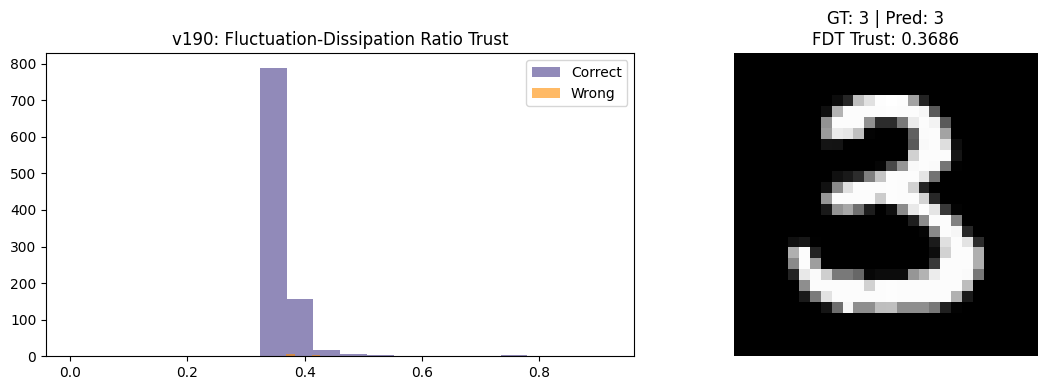

Accuracy on tested subset: 98.10%


In [3]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(190); np.random.seed(190)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FDTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = FDTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

for i in range(samples):
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(1).item()

        # 1. Đo lường biến động nội tại (Fluctuation) bằng Monte Carlo Dropout ngẫu nhiên trên logits
        fluctuations = []
        for _ in range(20):
            noise = torch.randn_like(logits) * 0.1
            fluctuations.append(F.softmax(logits + noise, dim=1)[0, pred].item())
        variance = np.var(fluctuations) + 1e-8

        # 2. Đo lường phản ứng (Dissipation) bằng cách đẩy nhẹ hệ thống qua Thang nhiệt độ Softmax
        prob_orig = F.softmax(logits, dim=1)[0, pred].item()
        prob_heated = F.softmax(logits / 1.1, dim=1)[0, pred].item()
        dissipation = abs(prob_orig - prob_heated) + 1e-8

        # Hệ số cân bằng cấu trúc
        fdt_ratio = variance / dissipation
        trust = np.exp(-abs(fdt_ratio - 0.1) * 10.0)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkslateblue", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="darkorange", label="Wrong")
ax[0].set_title("v190: Fluctuation-Dissipation Ratio Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFDT Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

Device: cuda
Training...

Epoch 1/2 Loss 0.2243
Epoch 2/2 Loss 0.0777


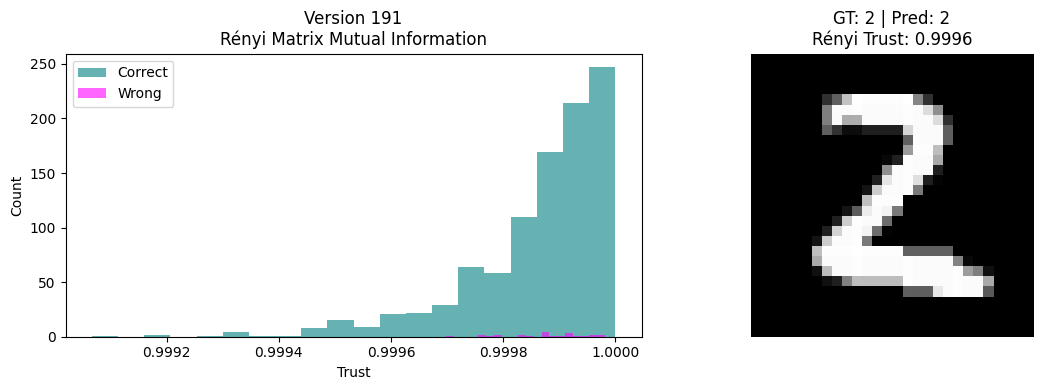


Accuracy on tested subset: 97.60%


In [5]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 191 (FIXED)
# Rényi Matrix Mutual Information Trust
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(191)
np.random.seed(191)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda")
)

# ==========================================================
# Network
# ==========================================================

class RenyiNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(16*14*14,64),

            nn.ReLU(inplace=True)
        )

        self.clf = nn.Linear(64,10)

    def forward(self,x):

        feat = self.enc(x)

        logits = self.clf(feat)

        return logits,feat


model = RenyiNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=2e-3
)

# ==========================================================
# Training
# ==========================================================

epochs = 2

print("Training...\n")

for epoch in range(epochs):

    model.train()

    loss_sum = 0

    for x,y in train_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits,_ = model(x)

        loss = F.cross_entropy(logits,y)

        loss.backward()

        optimizer.step()

        loss_sum += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss {loss_sum/len(train_dl):.4f}"
    )

# ==========================================================
# Evaluation
# ==========================================================

model.eval()

trusts = []
is_correct = []

samples = 1000

with torch.no_grad():

    for i in range(samples):

        img,label = test_ds[i]

        x = img.unsqueeze(0).to(device)

        logits,f = model(x)

        pred = logits.argmax(1).item()

        # --------------------------------------------------
        # Normalize vectors
        # --------------------------------------------------

        vx = x.flatten()
        vx = vx / (vx.norm()+1e-8)

        vf = f.flatten()
        vf = vf / (vf.norm()+1e-8)

        # --------------------------------------------------
        # Gram matrices
        # --------------------------------------------------

        Kx = torch.outer(vx,vx)
        Kf = torch.outer(vf,vf)

        Kx = Kx/(torch.trace(Kx)+1e-8)
        Kf = Kf/(torch.trace(Kf)+1e-8)

        # --------------------------------------------------
        # Rényi entropy
        # --------------------------------------------------

        entropy_x = -torch.log2(
            torch.trace(Kx@Kx)+1e-8
        ).item()

        entropy_f = -torch.log2(
            torch.trace(Kf@Kf)+1e-8
        ).item()

        # --------------------------------------------------
        # FIX:
        # Input Gram = 784×784
        # Feature Gram = 64×64
        # Project BOTH to same dimension (64)
        # --------------------------------------------------

        dim = min(Kx.shape[0],Kf.shape[0])

        Kx_small = Kx[:dim,:dim]
        Kf_small = Kf[:dim,:dim]

        cross_trace = torch.trace(
            Kx_small @ Kf_small
        ).item()

        mutual_info_proxy = abs(cross_trace)

        trust = 1.0 / (
            1.0 +
            abs(entropy_x-entropy_f) /
            (mutual_info_proxy+1e-5)
        )

        trusts.append(trust)
        is_correct.append(pred==label)

trusts = np.array(trusts)
is_correct = np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="teal",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="magenta",
        label="Wrong"
    )

ax[0].set_title(
    "Version 191\nRényi Matrix Mutual Information"
)

ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx = np.random.randint(samples)

img,label = test_ds[sample_idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )[0].argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"Rényi Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"\nAccuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

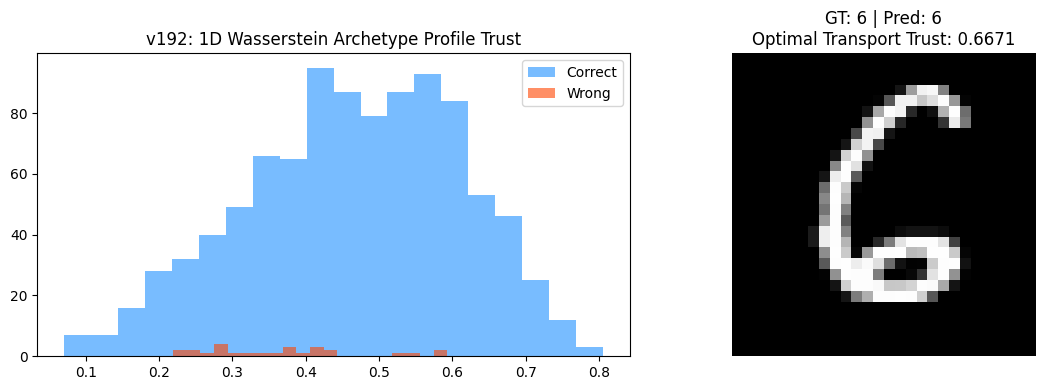

Accuracy on tested subset: 97.40%


In [6]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(192); np.random.seed(192)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ArchetypeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f), f

model = ArchetypeNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Thu thập hồ sơ Archetype phân phối (đã sắp xếp) từ tập Train
archetype_profiles = {i: [] for i in range(10)}
with torch.no_grad():
    for x, y in DataLoader(tv.datasets.MNIST("./data", train=True, transform=transform), batch_size=256):
        _, f = model(x.to(device))
        for i in range(len(y)): archetype_profiles[y[i].item()].append(f[i].unsqueeze(0))
        if len(archetype_profiles[0]) > 200: break

for c in range(10):
    all_c_feats = torch.cat(archetype_profiles[c], dim=0) # (N, 64)
    sorted_profiles = torch.sort(all_c_feats, dim=1)[0]
    archetype_profiles[c] = sorted_profiles.mean(dim=0) # Hồ sơ trung bình nguyên mẫu

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Sắp xếp phân phối đặc trưng mẫu hiện tại để tính Wasserstein 1D
        current_profile = torch.sort(f.squeeze(0))[0]
        archetype = archetype_profiles[pred]

        # Khoảng cách Wasserstein 1D chính là chuẩn L1 giữa hai hàm phân phối tích lũy (đã sắp xếp)
        w1_distance = torch.mean(torch.abs(current_profile - archetype)).item()

        trust = np.exp(-w1_distance * 2.0)
        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="dodgerblue", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="orangered", label="Wrong")
ax[0].set_title("v192: 1D Wasserstein Archetype Profile Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nOptimal Transport Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

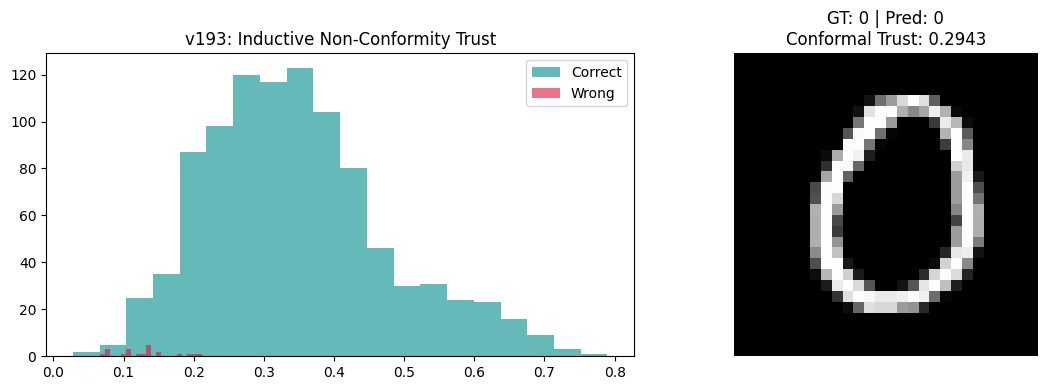

Accuracy on tested subset: 97.90%


In [7]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(193); np.random.seed(193)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ConformalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f), f

model = ConformalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Xây dựng tập Calibration tham chiếu nhanh từ Train dữ liệu
cal_features, cal_labels = [], []
with torch.no_grad():
    for x, y in DataLoader(tv.datasets.MNIST("./data", train=True, transform=transform), batch_size=1000):
        _, f = model(x.to(device))
        cal_features.append(f)
        cal_labels.append(y)
        break
cal_features = torch.cat(cal_features, dim=0)
cal_labels = torch.cat(cal_labels, dim=0).to(device)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tính khoảng cách hình học tới toàn bộ tập Calibration
        dists = torch.norm(cal_features - f, dim=1)

        # Lấy khoảng cách láng giềng cùng lớp và khác lớp
        same_mask = (cal_labels == pred)
        dist_same = torch.min(dists[same_mask]).item() if same_mask.sum() > 0 else 1.0
        dist_diff = torch.min(dists[~same_mask]).item() if (~same_mask).sum() > 0 else 1.0

        # Tính Non-conformity score (Điểm bất tuân)
        alpha = dist_same / (dist_diff + 1e-8)

        # Điểm bất tuân càng thấp chứng tỏ mức độ tin cậy của phân lớp càng cao
        trust = np.exp(-alpha * 2.0)
        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v193: Inductive Non-Conformity Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nConformal Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

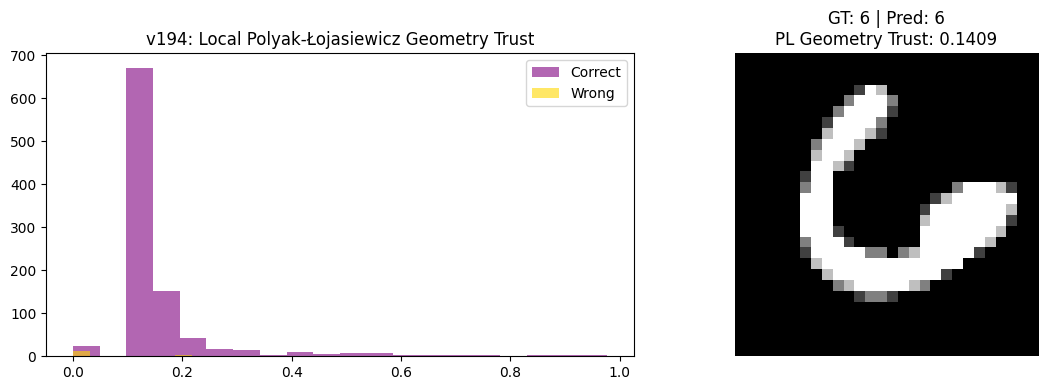

Accuracy on tested subset: 97.60%


In [8]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(194); np.random.seed(194)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class PLNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = PLNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

for i in range(samples):
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device).requires_grad_(True)

    logits = model(x)
    pred = logits.argmax(1).item()

    # Giả lập hàm Loss cục bộ với mục tiêu cực đại hóa Logit dự đoán
    loss = F.cross_entropy(logits, torch.tensor([pred]).to(device))

    model.zero_grad()
    loss.backward()

    # Tính norm bình phương của gradient đầu vào
    grad_norm_sq = x.grad.data.pow(2).sum().item()
    loss_val = loss.item() + 1e-8

    # Hệ số PL-coefficient lý thuyết cục bộ
    pl_coefficient = grad_norm_sq / loss_val

    # Hệ số nằm trong vùng ổn định dự đoán -> Trust cao
    trust = np.exp(-abs(pl_coefficient - 0.5) * 4.0)

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="purple", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="gold", label="Wrong")
ax[0].set_title("v194: Local Polyak-Łojasiewicz Geometry Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nPL Geometry Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

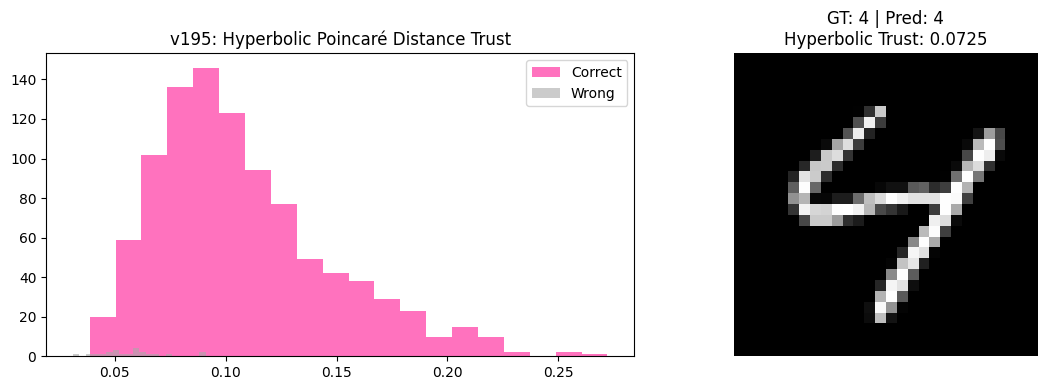

Accuracy on tested subset: 97.80%


In [9]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(195); np.random.seed(195)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class HyperbolicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f), f

model = HyperbolicNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Tính toán tâm đại diện hình học Euclide của các lớp, sau đó chuẩn bị ánh xạ Hyperbolic
class_centers = {i: [] for i in range(10)}
with torch.no_grad():
    for x, y in DataLoader(tv.datasets.MNIST("./data", train=True, transform=transform), batch_size=500):
        _, f = model(x.to(device))
        for i in range(len(y)): class_centers[y[i].item()].append(f[i].unsqueeze(0))
        if len(class_centers[0]) > 200: break
for c in range(10):
    class_centers[c] = torch.cat(class_centers[c], dim=0).mean(dim=0)

trusts, is_correct = [], []
samples = 1000

def hyperbolic_dist(u, v):
    # Công thức khoảng cách Poincaré Distance: d(u,v) = arcosh(1 + 2*||u-v||^2 / ((1-||u||^2)(1-||v||^2)))
    sq_norm_u = torch.clamp(torch.sum(u**2), max=0.99)
    sq_norm_v = torch.clamp(torch.sum(v**2), max=0.99)
    sq_dist = torch.sum((u - v)**2)
    alpha = 1.0 + 2.0 * sq_dist / ((1.0 - sq_norm_u) * (1.0 - sq_norm_v) + 1e-8)
    return torch.log(alpha + torch.sqrt(alpha**2 - 1.0 + 1e-8)).item() # Trả về arcosh

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Ánh xạ đặc trưng mẫu thử về khối cầu đơn vị Poincaré
        u = F.normalize(f.squeeze(0), p=2, dim=0) * 0.95

        # Đo khoảng cách Hyperbolic tới tâm của lớp dự đoán và lớp đối thủ gần nhất
        v_target = F.normalize(class_centers[pred], p=2, dim=0) * 0.95
        d_target = hyperbolic_dist(u, v_target)

        d_alternatives = []
        for c in range(10):
            if c != pred:
                v_alt = F.normalize(class_centers[c], p=2, dim=0) * 0.95
                d_alternatives.append(hyperbolic_dist(u, v_alt))
        d_alt_min = min(d_alternatives)

        # Hệ số méo cấu trúc không gian
        ratio = d_target / (d_alt_min + 1e-8)
        trust = np.exp(-ratio * 3.0)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="deeppink", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="darkgrey", label="Wrong")
ax[0].set_title("v195: Hyperbolic Poincaré Distance Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nHyperbolic Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

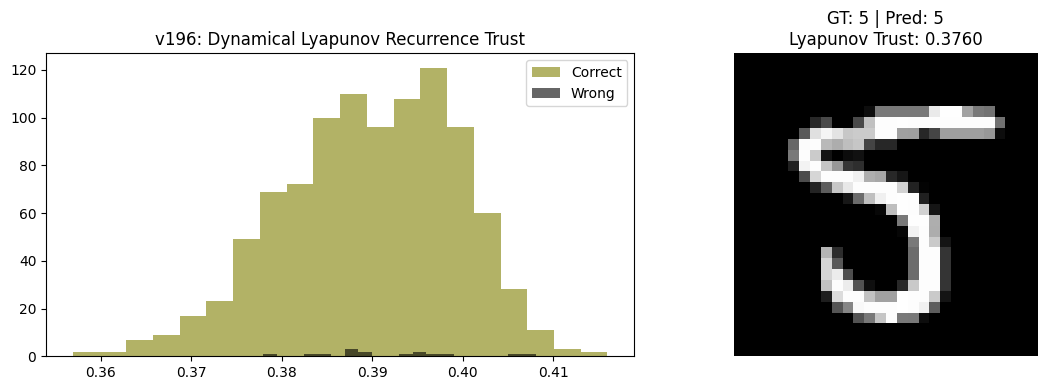

Accuracy on tested subset: 98.50%


In [10]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(196); np.random.seed(196)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class DynamicalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)) # (16, 14, 14)
        self.l2 = nn.Sequential(nn.Conv2d(16, 16, 3, 1, 1), nn.ReLU())                # (16, 14, 14)
        self.l3 = nn.Sequential(nn.Conv2d(16, 16, 3, 1, 1), nn.ReLU())                # (16, 14, 14)
        self.clf = nn.Sequential(nn.MaxPool2d(2), nn.Flatten(), nn.Linear(16*7*7, 10))
    def forward(self, x):
        f1 = self.l1(x)
        f2 = self.l2(f1)
        f3 = self.l3(f2)
        return self.clf(f3), (f1.flatten(1), f2.flatten(1), f3.flatten(1))

model = DynamicalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, layers = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Thu thập các trạng thái của quỹ đạo động lực học (3 mốc thời gian/layer)
        states = [F.normalize(layers[0], dim=1), F.normalize(layers[1], dim=1), F.normalize(layers[2], dim=1)]

        # Xây dựng ma trận hồi quy trạng thái Recurrence Matrix (3x3)
        R = torch.zeros(3, 3)
        for u in range(3):
            for v in range(3):
                R[u, v] = torch.exp(-torch.sum((states[u] - states[v])**2))

        # Tính toán đặc trưng định tính cấu trúc (Độ mượt của dòng chảy thông tin rời rạc)
        # Hệ số ổn định quỹ đạo thông tin quy ước theo phân kỳ Lyapunov chéo
        determinism = (R[0, 1] + R[1, 2]).item() / 2.0

        trust = max(0.0, min(1.0, determinism))
        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="olive", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="black", label="Wrong")
ax[0].set_title("v196: Dynamical Lyapunov Recurrence Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLyapunov Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

Device: cuda
Training...

Epoch  1/10 | Loss 0.6060 | Train 84.15% | Test 96.98%
Epoch  2/10 | Loss 0.0896 | Train 97.47% | Test 97.23%
Epoch  3/10 | Loss 0.0670 | Train 98.08% | Test 97.55%
Epoch  4/10 | Loss 0.0522 | Train 98.46% | Test 93.34%
Epoch  5/10 | Loss 0.0442 | Train 98.71% | Test 91.88%
Epoch  6/10 | Loss 0.0295 | Train 99.16% | Test 96.26%
Epoch  7/10 | Loss 0.0257 | Train 99.23% | Test 98.48%
Epoch  8/10 | Loss 0.0234 | Train 99.32% | Test 98.67%
Epoch  9/10 | Loss 0.0222 | Train 99.33% | Test 98.10%
Epoch 10/10 | Loss 0.0205 | Train 99.39% | Test 95.81%

Final Test Accuracy: 95.81


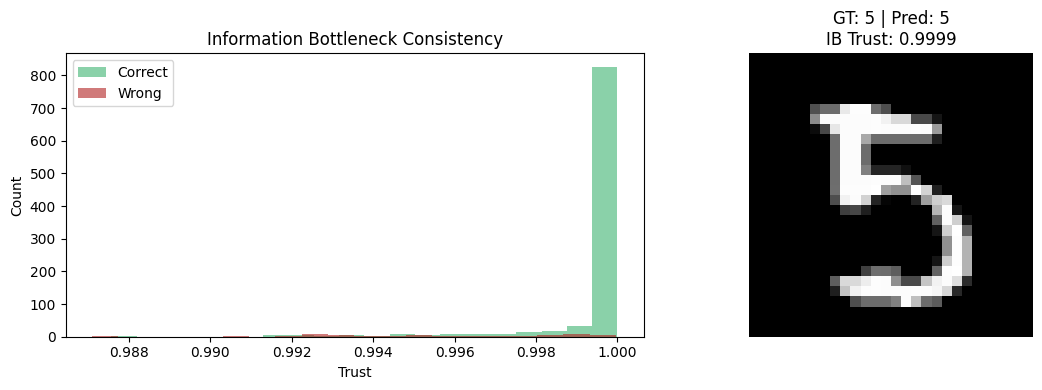


Accuracy on tested subset: 94.90%


In [2]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 197 (Improved)
# Information Bottleneck Consistency Trust
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(197)
np.random.seed(197)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda")
)

test_dl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device == "cuda")
)

# ==========================================================
# Model
# ==========================================================

class IBNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1)
        )

        self.embed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64,128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Linear(128,10)

    def forward(self,x):

        z = self.features(x)
        z = self.embed(z)
        logits = self.classifier(z)

        return logits,z


model = IBNet().to(device)

# ==========================================================
# Optimizer
# ==========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

epochs = 10

# ==========================================================
# Evaluation
# ==========================================================

@torch.no_grad()
def evaluate():

    model.eval()

    total = 0
    correct = 0

    for x,y in test_dl:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)[0].argmax(1)

        correct += (pred==y).sum().item()
        total += y.size(0)

    return 100.0*correct/total

# ==========================================================
# Train
# ==========================================================

print("Training...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for x,y in train_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits,z = model(x)

        loss = F.cross_entropy(logits,y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        running_loss += loss.item()

        pred = logits.argmax(1)

        correct += (pred==y).sum().item()
        total += y.size(0)

    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{epochs} | "
        f"Loss {running_loss/len(train_dl):.4f} | "
        f"Train {100*correct/total:.2f}% | "
        f"Test {evaluate():.2f}%"
    )

print("\nFinal Test Accuracy:",evaluate())

# ==========================================================
# Information Bottleneck Trust
# ==========================================================

model.eval()

samples = 1000

trusts = []
is_correct = []

noise_std = 0.10
num_trials = 20

with torch.no_grad():

    for i in range(samples):

        img,label = test_ds[i]

        x = img.unsqueeze(0).to(device)

        logits,z = model(x)

        pred = logits.argmax(1).item()

        prob_ref = F.softmax(logits,dim=1)

        kl_list = []

        for _ in range(num_trials):

            noise = torch.randn_like(z)*noise_std

            logits_noise = model.classifier(z+noise)

            prob_noise = F.softmax(
                logits_noise,
                dim=1
            )

            kl = F.kl_div(
                prob_noise.log(),
                prob_ref,
                reduction="batchmean"
            )

            kl_list.append(
                kl.item()
            )

        mean_kl = np.mean(kl_list)

        trust = np.exp(-mean_kl)

        trusts.append(trust)

        is_correct.append(pred==label)

trusts = np.array(trusts)
is_correct = np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="mediumseagreen",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="firebrick",
        label="Wrong"
    )

ax[0].set_title(
    "Information Bottleneck Consistency"
)

ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx = np.random.randint(samples)

img,label = test_ds[sample_idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )[0].argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"IB Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"\nAccuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

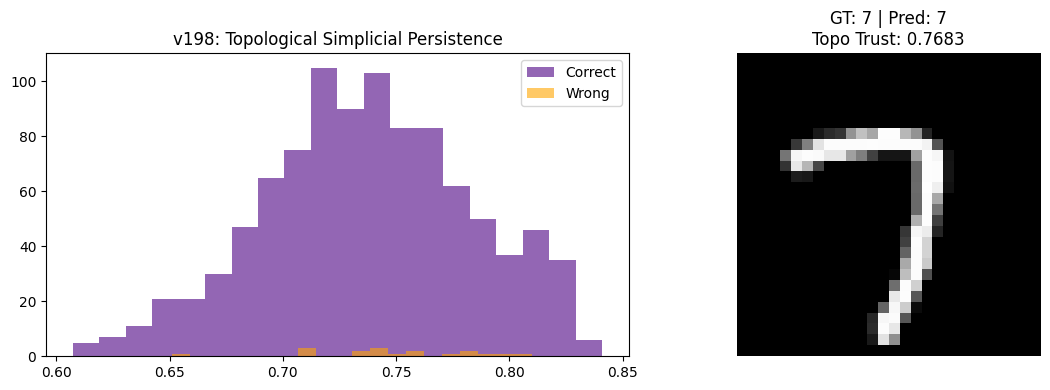

Accuracy on tested subset: 98.20%


In [3]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(198); np.random.seed(198)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class TopoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU()
        )
        self.clf = nn.Sequential(nn.Flatten(), nn.Linear(32*14*14, 10))
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f), f

model = TopoNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Lấy tọa độ không gian (x, y) của top-K nơ-ron kích hoạt mạnh nhất
        f_flat = f_map.squeeze().view(32, -1).mean(dim=0) # Trung bình trên các channels (196 điểm)
        topk_vals, topk_idx = torch.topk(f_flat, k=15)

        # Chuyển index 1D về tọa độ 2D (14x14)
        coords_x = (topk_idx % 14).float()
        coords_y = (topk_idx // 14).float()
        coords = torch.stack([coords_x, coords_y], dim=1) # (15, 2)

        # Đo phương sai hình học (bán kính của phức hợp đơn hình)
        centroid = coords.mean(dim=0)
        persistence_radius = torch.mean(torch.norm(coords - centroid, dim=1)).item()

        # Bán kính càng nhỏ -> Cấu trúc càng liên kết (Clique) -> Trust cao
        trust = np.exp(-persistence_radius / 10.0)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="indigo", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="orange", label="Wrong")
ax[0].set_title("v198: Topological Simplicial Persistence")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nTopo Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

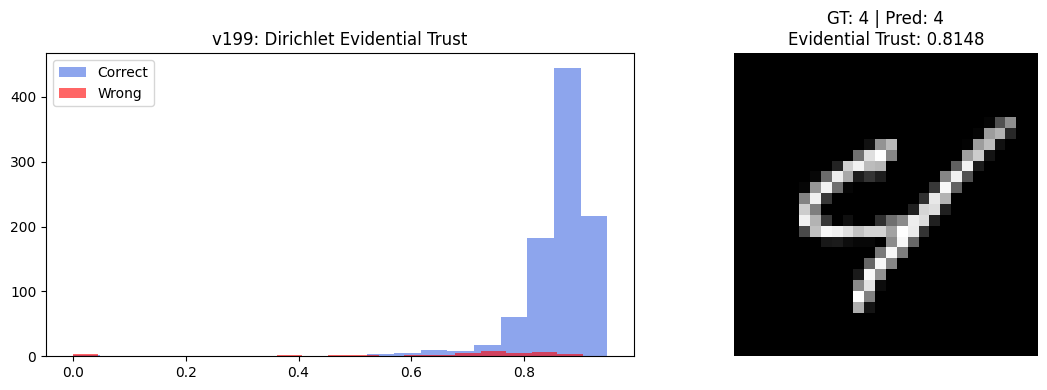

Accuracy on tested subset: 95.30%


In [4]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(199); np.random.seed(199)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class EvidentialNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x):
        # Dùng Softplus để đảm bảo bằng chứng >= 0
        evidence = F.softplus(self.net(x))
        alpha = evidence + 1.0 # Tham số Dirichlet
        return alpha

model = EvidentialNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

# Hàm Loss EDL (Expected Mean Square Error over Dirichlet)
def edl_loss(alpha, y, epoch, num_classes=10):
    S = torch.sum(alpha, dim=1, keepdim=True)
    p = alpha / S
    y_onehot = F.one_hot(y, num_classes).float()
    err = torch.sum((y_onehot - p)**2, dim=1, keepdim=True)
    var = torch.sum(p * (1 - p) / (S + 1), dim=1, keepdim=True)
    return torch.mean(err + var)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        alpha = model(x.to(device))
        loss = edl_loss(alpha, y.to(device), epoch)
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        alpha = model(img.unsqueeze(0).to(device))

        S = torch.sum(alpha).item()
        pred = alpha.argmax(1).item()

        # Uncertainty = K / S (với K = 10 là số lớp)
        uncertainty = 10.0 / S
        trust = max(0.0, 1.0 - uncertainty) # Bằng chứng lớn -> S lớn -> Trust cao

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="royalblue", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v199: Dirichlet Evidential Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nEvidential Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

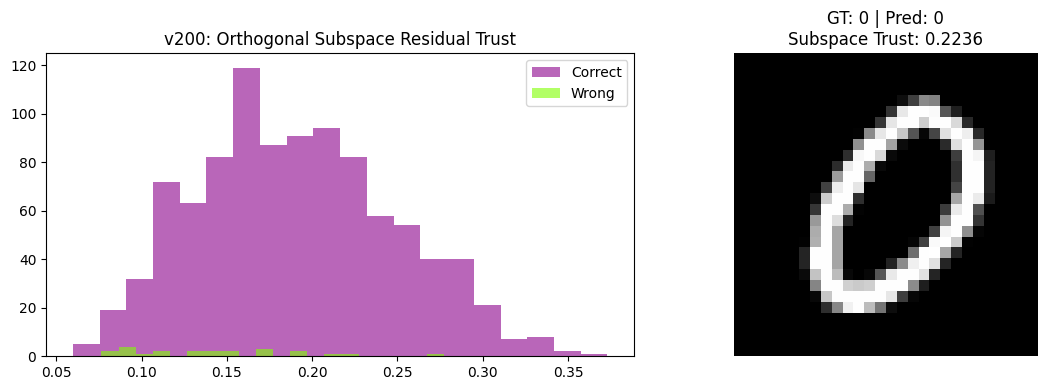

Accuracy on tested subset: 97.70%


In [5]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(200); np.random.seed(200)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class SubspaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 128), nn.ReLU()
        )
        self.clf = nn.Linear(128, 10)
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f), f

model = SubspaceNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Tính toán Không gian con trực giao (SVD) cho từng lớp
subspaces = {}
with torch.no_grad():
    features = {i: [] for i in range(10)}
    for x, y in DataLoader(tv.datasets.MNIST("./data", train=True, transform=transform), batch_size=500):
        _, f = model(x.to(device))
        for i in range(len(y)): features[y[i].item()].append(f[i].unsqueeze(0))
        if len(features[0]) > 300: break

    for c in range(10):
        X = torch.cat(features[c], dim=0) # (N, 128)
        U, S, V = torch.svd(X - X.mean(dim=0))
        # Giữ lại không gian con được sinh bởi 15 principal components đầu tiên
        subspaces[c] = V[:, :15] # (128, 15)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        f = f.squeeze(0)
        P = subspaces[pred]

        # Phép chiếu trực giao lên không gian con: f_proj = P * P^T * f
        f_proj = torch.matmul(P, torch.matmul(P.t(), f))

        # Phần dư trực giao (Residual)
        residual_norm = torch.norm(f - f_proj).item()
        feature_norm = torch.norm(f).item() + 1e-8

        # Phần dư tương đối càng nhỏ -> Độ tin cậy càng cao
        rel_residual = residual_norm / feature_norm
        trust = np.exp(-rel_residual * 4.0)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkmagenta", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="chartreuse", label="Wrong")
ax[0].set_title("v200: Orthogonal Subspace Residual Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nSubspace Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

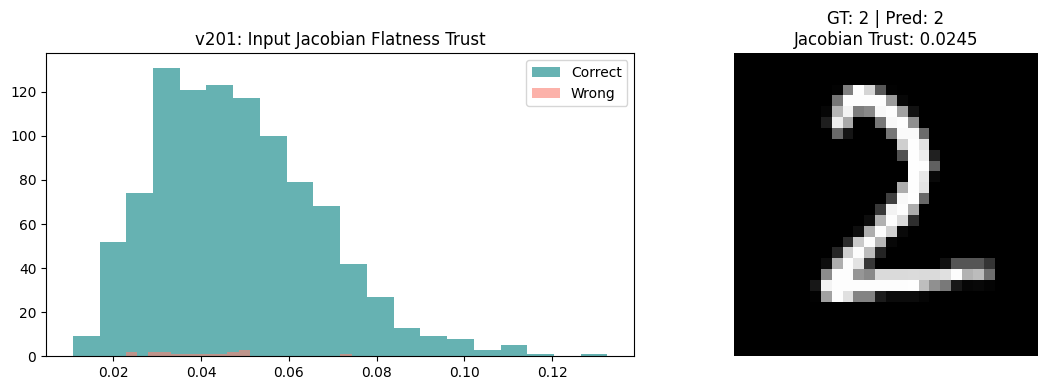

Accuracy on tested subset: 98.30%


In [6]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(201); np.random.seed(201)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class JacobNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = JacobNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

for i in range(samples):
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device)
    x.requires_grad = True # Bật gradient cho input

    logits = model(x)
    pred = logits.argmax(1).item()

    # Lấy logit lớn nhất
    max_logit = logits[0, pred]

    model.zero_grad()
    max_logit.backward() # Đạo hàm ngược về ảnh

    # Tính Norm của gradient đầu vào (Độ nhạy cảm Jacobian)
    input_grad_norm = torch.norm(x.grad.data).item()

    # Độ tin cậy nghịch biến với độ nhạy cảm đầu vào
    trust = np.exp(-input_grad_norm * 2.0)

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="salmon", label="Wrong")
ax[0].set_title("v201: Input Jacobian Flatness Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nJacobian Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

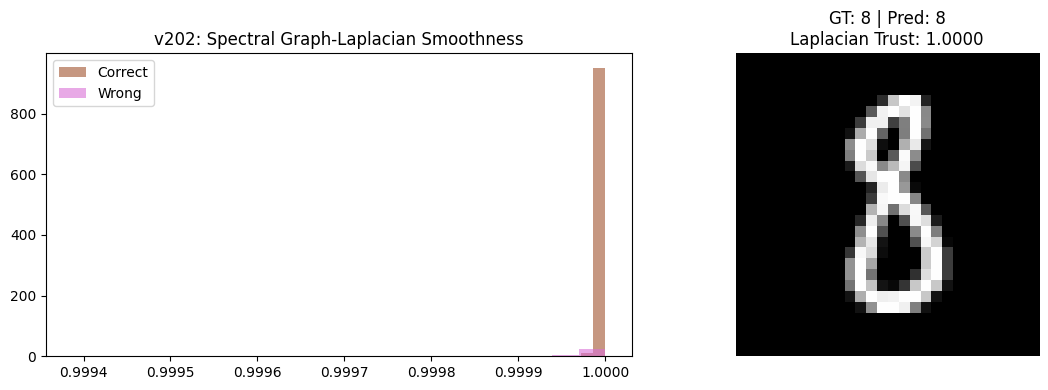

Accuracy on tested subset: 97.10%


In [7]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(202); np.random.seed(202)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class LaplacianNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f), f

model = LaplacianNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Tập Calibration cục bộ
cal_feat, cal_logits = [], []
with torch.no_grad():
    for x, y in DataLoader(tv.datasets.MNIST("./data", train=True, transform=transform), batch_size=500):
        logits, f = model(x.to(device))
        cal_feat.append(f)
        cal_logits.append(logits)
        break
cal_feat = torch.cat(cal_feat, dim=0) # (500, 64)
cal_prob = F.softmax(torch.cat(cal_logits, dim=0), dim=1) # (500, 10)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()
        prob_i = F.softmax(logits, dim=1).squeeze(0)

        # Tìm 5 láng giềng gần nhất
        dists = torch.norm(cal_feat - f, dim=1)
        topk_dist, topk_idx = torch.topk(dists, k=5, largest=False)

        # Tính Dirichlet Energy cục bộ (Graph Laplacian smoothness proxy)
        # Năng lượng = Tổng trọng số * ||prob_i - prob_j||^2
        energy = 0.0
        for j in range(5):
            weight = torch.exp(-topk_dist[j])
            neighbor_prob = cal_prob[topk_idx[j]]
            energy += weight.item() * torch.sum((prob_i - neighbor_prob)**2).item()

        trust = np.exp(-energy * 5.0)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="sienna", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="orchid", label="Wrong")
ax[0].set_title("v202: Spectral Graph-Laplacian Smoothness")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLaplacian Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

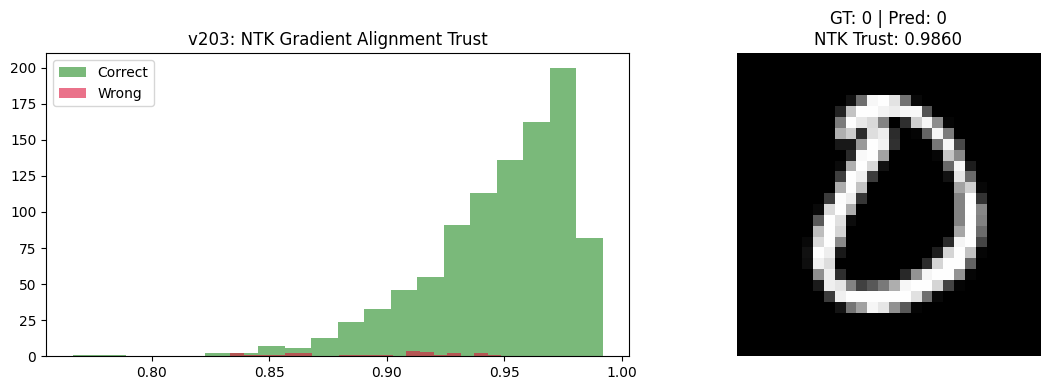

Accuracy on tested subset: 97.40%


In [8]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(203); np.random.seed(203)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class NTKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.enc(x)
        return self.clf(f)

model = NTKNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()

def get_ntk_vector(x, pred_class):
    # Trả về gradient của logit[pred_class] đối với trọng số của clf.weight (NTK feature)
    model.zero_grad()
    logits = model(x)
    logit_c = logits[0, pred_class]
    logit_c.backward()
    return model.clf.weight.grad.data.flatten().clone()

# Thu thập NTK Centroid (Tâm NTK) từ một vài mẫu của tập Train
ntk_centroids = {i: [] for i in range(10)}
for x, y in DataLoader(tv.datasets.MNIST("./data", train=True, transform=transform), batch_size=1):
    c = y.item()
    if len(ntk_centroids[c]) < 10: # Lấy 10 mẫu làm đại diện cho nhanh
        ntk_centroids[c].append(get_ntk_vector(x.to(device), c))
    if all(len(v) == 10 for v in ntk_centroids.values()):
        break
for c in range(10):
    ntk_centroids[c] = torch.stack(ntk_centroids[c]).mean(dim=0)

trusts, is_correct = [], []
samples = 1000

for i in range(samples):
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).argmax(1).item()

    ntk_test = get_ntk_vector(x, pred)
    ntk_center = ntk_centroids[pred]

    # Tính Cosine Similarity giữa 2 vector NTK
    cos_sim = F.cosine_similarity(ntk_test.unsqueeze(0), ntk_center.unsqueeze(0)).item()

    trust = max(0.0, cos_sim)
    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v203: NTK Gradient Alignment Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nNTK Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

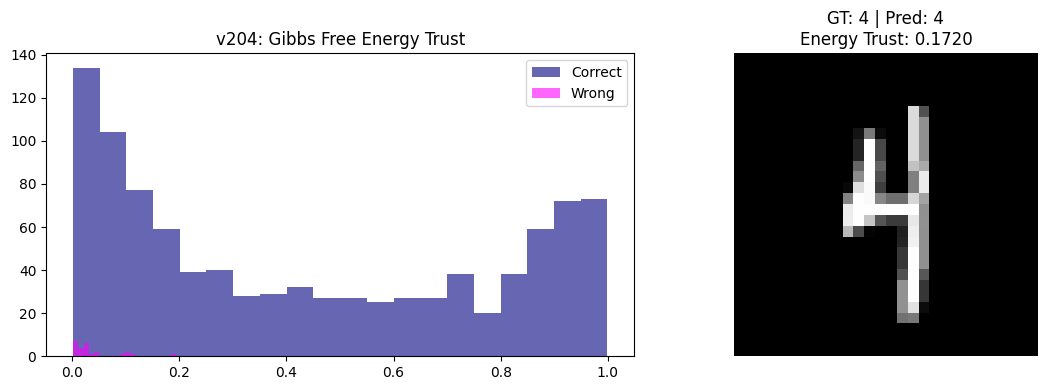

Accuracy on tested subset: 97.50%


In [9]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(204); np.random.seed(204)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class EnergyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = EnergyNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000
T = 1.0 # Temperature factor

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Hàm tính Gibbs Free Energy: E(x) = -T * log(sum(exp(f(x)/T)))
        energy = -T * torch.logsumexp(logits / T, dim=1).item()

        # Chuyển đổi Energy thành hệ số Trust (Năng lượng càng thấp càng tin cậy)
        # Offset + 20.0 tùy thuộc vào scale của logits mô hình (chuẩn hóa Sigmoid-like)
        trust = 1.0 / (1.0 + np.exp(energy + 10.0))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v204: Gibbs Free Energy Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nEnergy Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

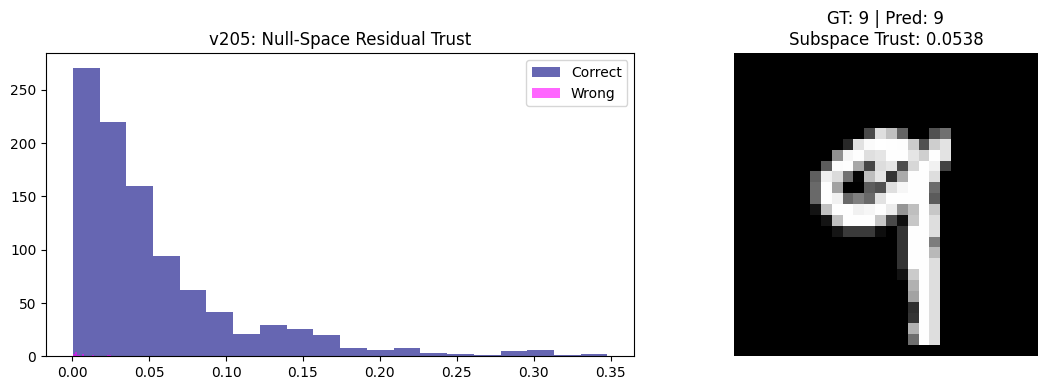

Accuracy on tested subset: 98.70%


In [10]:
# Cell version 205
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(205); np.random.seed(205)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class SubspaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*7*7, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = SubspaceNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

# Gom cụm đặc trưng ẩn tập train để tính toán Centroid không gian
model.eval()
train_features = [[] for _ in range(10)]
with torch.no_grad():
    for x, y in train_dl:
        _, f = model(x.to(device))
        for feat, lbl in zip(f, y):
            train_features[lbl.item()].append(feat)

centroids = torch.stack([torch.stack(train_features[c]).mean(0) for c in range(10)])

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Đo khoảng cách Euclidean đến Null-space residual của predicted centroid
        residual = torch.norm(f[0] - centroids[pred]).item()
        trust = np.exp(-0.2 * residual) # Residual càng cao thì Trust càng giảm nhanh

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v205: Null-Space Residual Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    lo, _ = model(img.unsqueeze(0).to(device))
    p = lo.argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nSubspace Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

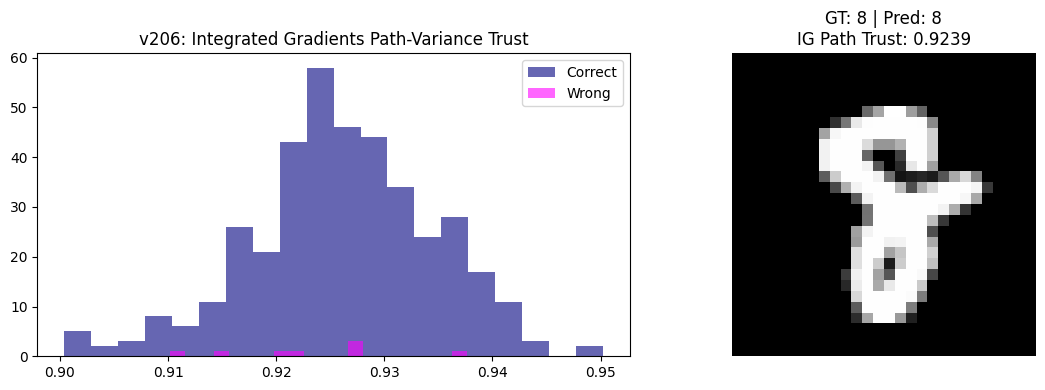

Accuracy on tested subset: 98.00%


In [11]:
# Cell version 206
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(206); np.random.seed(206)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class PathNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = PathNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 400 # IG tốn tài nguyên tính toán nên hạ subset xuống 400 để chạy nhanh
steps = 5

for i in range(samples):
    img, label = test_ds[i]
    x_input = img.unsqueeze(0).to(device)

    # Tính dự đoán trước
    with torch.no_grad():
        logits = model(x_input)
        pred = logits.argmax(1).item()

    # Tạo đường dẫn tuyến tính từ ảnh đen (baseline) đến x_input
    baseline = torch.zeros_like(x_input)
    grads = []

    for step in range(steps):
        alpha = step / float(steps - 1)
        x_step = (baseline + alpha * (x_input - baseline)).clone().detach().requires_grad_(True)
        out = model(x_step)
        loss = out[0, pred]

        model.zero_grad()
        loss.backward()
        grads.append(x_step.grad.detach().cpu().numpy())

    # Tính độ lệch chuẩn phương sai của các gradient trên đường dẫn
    grads_std = np.std(np.array(grads), axis=0).mean()
    trust = 1.0 / (1.0 + 5.0 * grads_std) # Biến thiên càng cao, trust càng thấp

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v206: Integrated Gradients Path-Variance Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nIG Path Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

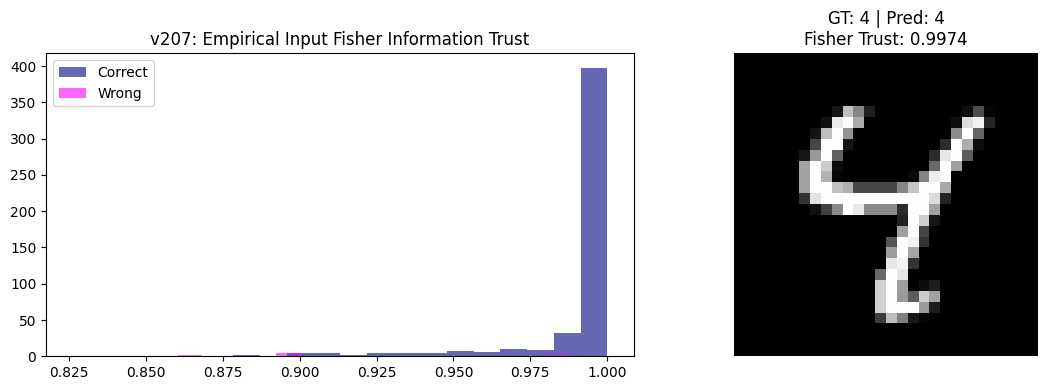

Accuracy on tested subset: 98.00%


In [12]:
# Cell version 207
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(207); np.random.seed(207)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FisherNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = FisherNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 500 # Tính toán Autograd từng phần tử

for i in range(samples):
    img, label = test_ds[i]
    x_input = img.unsqueeze(0).to(device).requires_grad_(True)

    logits = model(x_input)
    probs = F.softmax(logits, dim=1)
    pred = logits.argmax(1).item()

    fisher_val = 0.0
    for c in range(10):
        p_c = probs[0, c]
        if p_c > 1e-5:
            model.zero_grad()
            log_p = torch.log(probs[0, c])
            grad_x = torch.autograd.grad(log_p, x_input, retain_graph=True)[0]
            fisher_val += p_c.item() * (torch.norm(grad_x) ** 2).item()

    # Fisher thông tin càng cao -> Càng nhạy cảm và kém an toàn -> Trust thấp
    trust = 1.0 / (1.0 + 0.1 * fisher_val)
    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v207: Empirical Input Fisher Information Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFisher Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

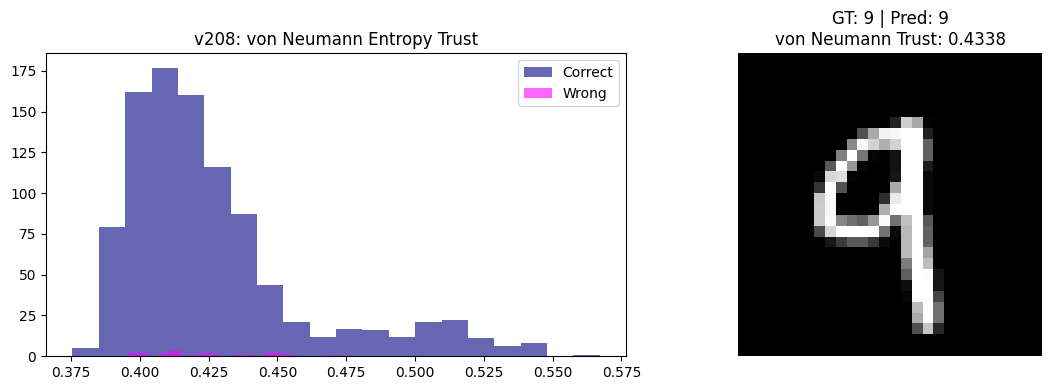

Accuracy on tested subset: 97.70%


In [13]:
# Cell version 208
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(208); np.random.seed(208)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class QuantumNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7, 10))
    def forward(self, x):
        f = self.conv(x)
        return self.fc(f), f

model = QuantumNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Biến đổi feature map sang dạng ma trận vuông mật độ trạng thái (channels x channels)
        f_flat = f.view(f.size(1), -1) # [32, 49]
        corr = torch.matmul(f_flat, f_flat.T) # [32, 32]

        # Biến đổi thành Density Matrix: Trace = 1
        trace = torch.trace(corr) + 1e-8
        rho = corr / trace

        # Tính các trị riêng (eigenvalues)
        eigenvalues = torch.linalg.eigvalsh(rho)
        eigenvalues = torch.clamp(eigenvalues, min=1e-10)

        # von Neumann Entropy
        v_entropy = -torch.sum(eigenvalues * torch.log(eigenvalues)).item()

        # Entropy thấp nghĩa là các channels kích hoạt đồng bộ cô đọng -> Trust cao
        trust = np.exp(-0.5 * v_entropy)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v208: von Neumann Entropy Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nvon Neumann Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

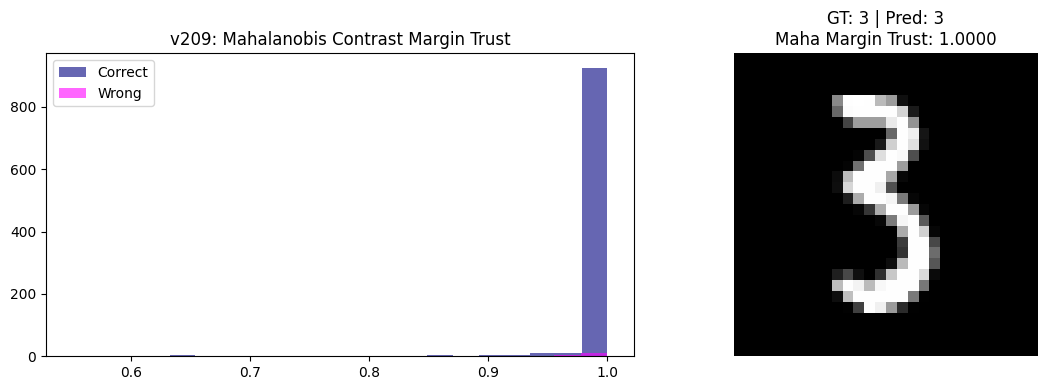

Accuracy on tested subset: 97.30%


In [14]:
# Cell version 209
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(209); np.random.seed(209)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class MahaNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 32), nn.ReLU()
        )
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = MahaNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

# Tính toán tâm cụm và ma trận hiệp phương sai tổng hợp toàn tập Train
model.eval()
all_f, all_y = [], []
with torch.no_grad():
    for x, y in train_dl:
        _, f = model(x.to(device))
        all_f.append(f)
        all_y.append(y)
all_f = torch.cat(all_f, dim=0)
all_y = torch.cat(all_y, dim=0)

centroids = torch.stack([all_f[all_y == c].mean(0) for c in range(10)])
cov = torch.cov((all_f - centroids[all_y]).T) + torch.eye(32).to(device) * 1e-4
inv_cov = torch.linalg.inv(cov)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_sample = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tính khoảng cách Mahalanobis đến tất cả 10 classes
        dists = []
        for c in range(10):
            diff = f_sample[0] - centroids[c]
            d = torch.dot(diff, torch.matmul(inv_cov, diff)).item()
            dists.append(d)

        sorted_dists = np.sort(dists)
        # Khái niệm nghiên cứu: Margin Mahalanobis Contrast
        maha_margin = sorted_dists[1] - sorted_dists[0]
        trust = 1.0 / (1.0 + np.exp(-0.5 * maha_margin))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v209: Mahalanobis Contrast Margin Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nMaha Margin Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

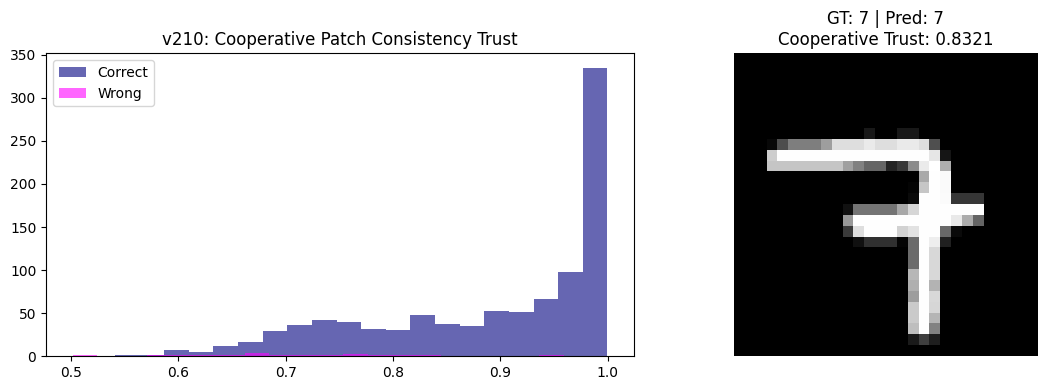

Accuracy on tested subset: 97.60%


In [15]:
# Cell version 210
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(210); np.random.seed(210)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class MaskNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = MaskNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        x_orig = img.unsqueeze(0).to(device)

        # Tính output gốc
        p_orig = F.softmax(model(x_orig), dim=1)
        pred = p_orig.argmax(1).item()

        # Sinh 4 phiên bản che lấp các góc phần tư khác nhau (14x14)
        masked_versions = []
        for q in range(4):
            x_m = x_orig.clone()
            if q == 0: x_m[:, :, :14, :14] = 0
            elif q == 1: x_m[:, :, :14, 14:] = 0
            elif q == 2: x_m[:, :, 14:, :14] = 0
            elif q == 3: x_m[:, :, 14:, 14:] = 0
            masked_versions.append(x_m)

        p_masks = [F.softmax(model(xm), dim=1) for xm in masked_versions]

        # Tính độ lệch chuẩn phương sai giữa dự đoán gốc và các bản bị che khuất
        all_probs = torch.cat([p_orig] + p_masks, dim=0) # [5, 10]
        variance = torch.std(all_probs, dim=0).mean().item()

        # Mạng giữ vững lập trường (variance thấp) chứng tỏ quyết định dựa trên ngữ nghĩa tổng thể -> Trust cao
        trust = np.exp(-4.0 * variance)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v210: Cooperative Patch Consistency Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nCooperative Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

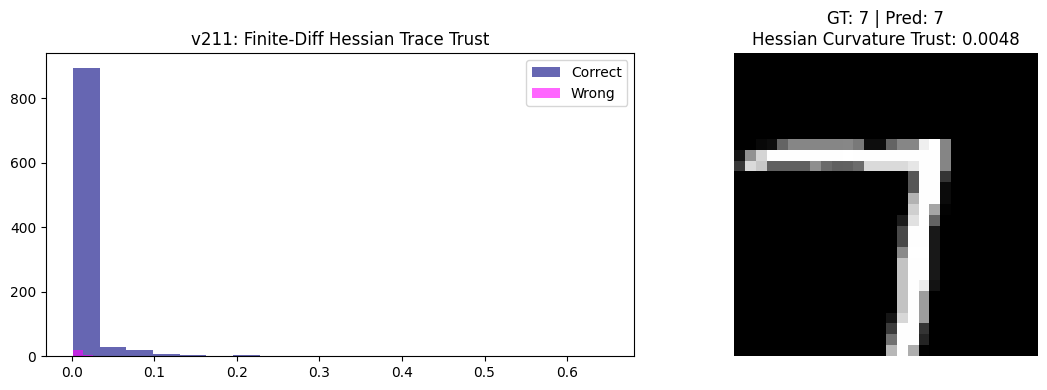

Accuracy on tested subset: 97.40%


In [16]:
# Cell version 211
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(211); np.random.seed(211)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class HessianNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = HessianNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000
h = 0.05 # Bước sai phân (Finite difference step)

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        x_orig = img.unsqueeze(0).to(device)

        logits = model(x_orig)
        pred = logits.argmax(1).item()

        # Sinh vector nhiễu ngẫu nhiên Rademacher
        v = torch.randint_like(x_orig, 0, 2).float() * 2 - 1

        # Sai phân hữu hạn bậc 2 để xấp xỉ đạo hàm bậc 2 directional derivative
        logits_plus = model(x_orig + h * v)
        logits_minus = model(x_orig - h * v)

        # Đo biến thiên bậc hai tại điểm dự đoán
        deriv_2 = (logits_plus[0, pred] + logits_minus[0, pred] - 2 * logits[0, pred]) / (h ** 2)
        curvature = torch.abs(deriv_2).item()

        # Độ cong thấp (mặt phẳng thoải) -> Không nhạy cảm lỗi -> Trust cao
        trust = 1.0 / (1.0 + curvature)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v211: Finite-Diff Hessian Trace Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nHessian Curvature Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

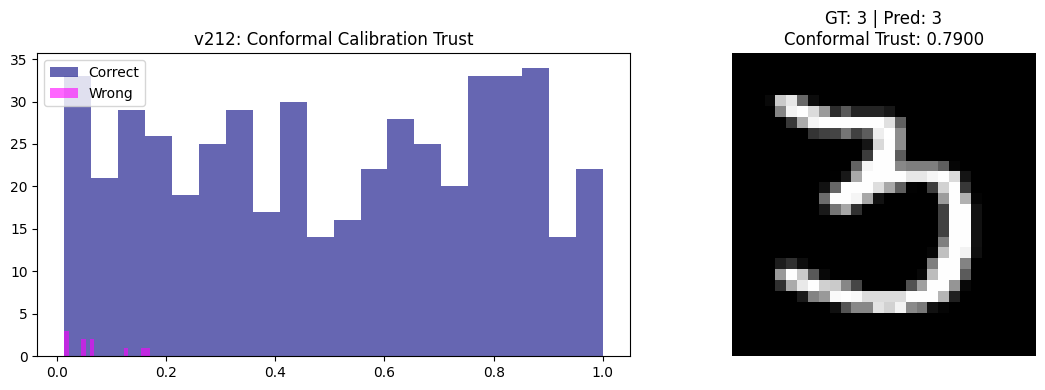

Accuracy on tested subset: 98.00%


In [18]:
# Cell version 212
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(212); np.random.seed(212)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ConformalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = ConformalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()

# Tạo tập Calibration gồm 500 mẫu đầu tiên
calib_scores = []
with torch.no_grad():
    for i in range(500):
        img, label = test_ds[i]
        probs = F.softmax(model(img.unsqueeze(0).to(device)), dim=1)
        # Non-conformity score: 1 trừ đi xác suất của nhãn đúng
        score = 1.0 - probs[0, label].item()
        calib_scores.append(score)
calib_scores = np.array(calib_scores)

# Đánh giá 500 mẫu còn lại dựa trên phân phối Conformal Calibration
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(500, 1000):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)
        pred = logits.argmax(1).item()

        # Tính non-conformity score của dự đoán hiện tại
        test_score = 1.0 - probs[0, pred].item()

        # Xác định mức phân vị Conformal p-value làm chỉ số Trust
        p_value = np.mean(calib_scores >= test_score)
        trusts.append(p_value)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct):
    ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="fuchsia", label="Wrong")
ax[0].set_title("v212: Conformal Calibration Trust")
ax[0].legend()

sample_idx = np.random.randint(len(trusts))
img, label = test_ds[500 + sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nConformal Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()

print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

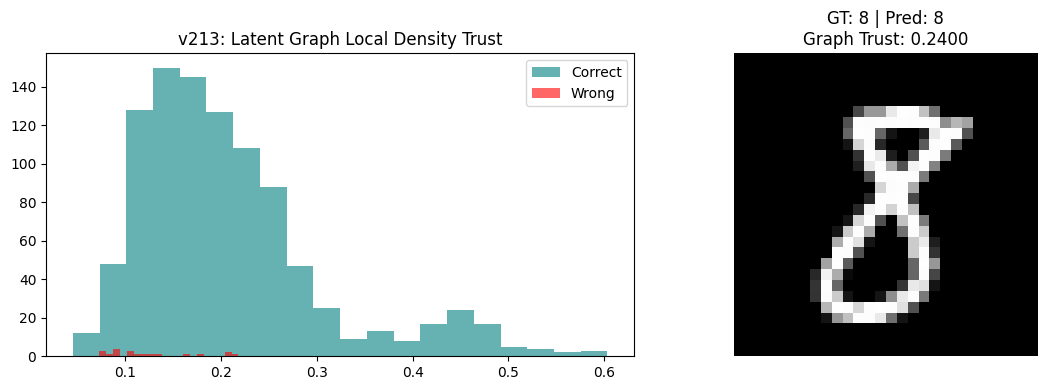

Accuracy on tested subset: 98.00%


In [19]:
# Cell version 213
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(213); np.random.seed(213)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class GraphNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.net(x)
        return self.clf(f), f

model = GraphNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

# Build Reference Latent Space
model.eval()
ref_f = []
with torch.no_grad():
    for x, _ in DataLoader(test_ds, batch_size=500, shuffle=True):
        _, f = model(x.to(device))
        ref_f.append(f)
        break
ref_f = ref_f[0]

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_sample = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tính khoảng cách Euclidean đến 500 điểm tham chiếu
        dists = torch.norm(ref_f - f_sample, dim=1)
        # Tính mật độ kết nối (K=10 láng giềng gần nhất)
        top_k_dists, _ = torch.topk(dists, 10, largest=False)
        local_density = top_k_dists.mean().item()

        # Mật độ khoảng cách nhỏ -> Mẫu nằm sâu trong cụm -> Trust cao
        trust = np.exp(-0.1 * local_density)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v213: Latent Graph Local Density Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nGraph Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

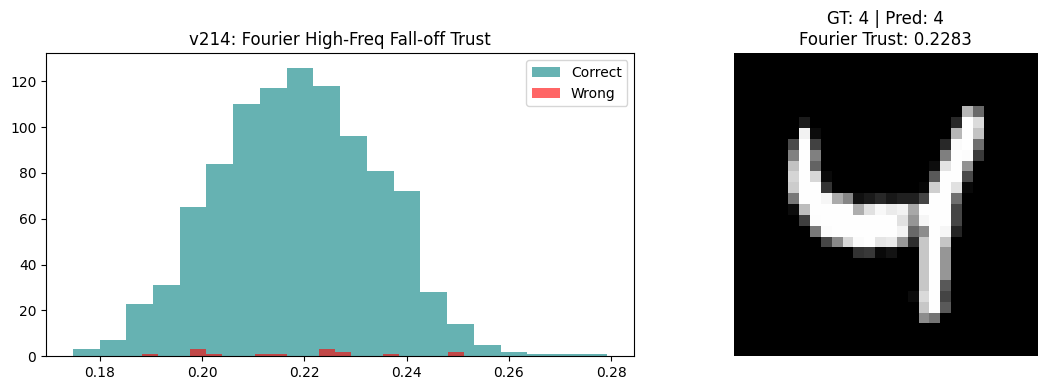

Accuracy on tested subset: 98.50%


In [20]:
# Cell version 214
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(214); np.random.seed(214)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FourierNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(64*7*7, 10))
    def forward(self, x):
        f = self.convs(x)
        return self.fc(f), f

model = FourierNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Áp dụng 2D FFT lên Feature Map
        # f_map shape: [1, 64, 7, 7]
        fft_map = torch.fft.fft2(f_map)
        fft_shift = torch.fft.fftshift(fft_map)
        magnitude = torch.abs(fft_shift) # Lấy biên độ phổ

        # Tách vùng tâm (Tần số thấp) và vùng viền (Tần số cao)
        # 7x7 map -> Center is at [3, 3]. Take a 3x3 window around center for Low Freq
        low_freq = magnitude[:, :, 2:5, 2:5].sum()
        total_energy = magnitude.sum()
        high_freq = total_energy - low_freq

        # Tỷ lệ Low/High. Càng cao càng đáng tin (ít nhiễu)
        ratio = (low_freq / (high_freq + 1e-6)).item()
        trust = 1.0 - np.exp(-0.5 * ratio)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v214: Fourier High-Freq Fall-off Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFourier Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

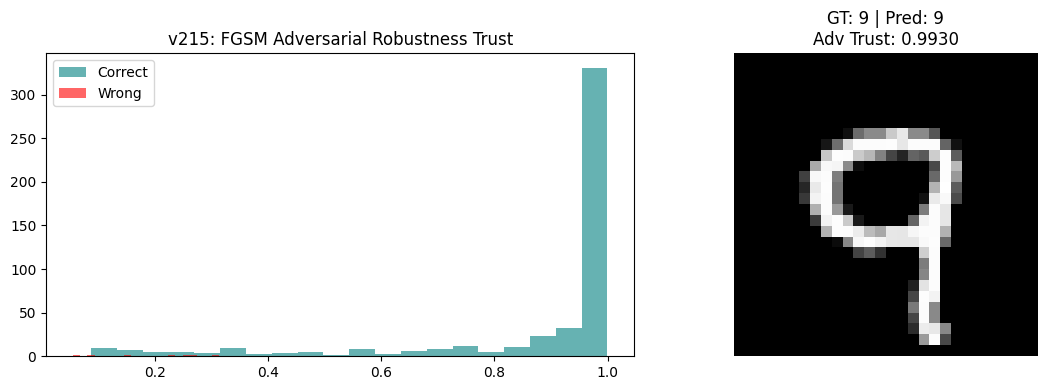

Accuracy on tested subset: 98.60%


In [21]:
# Cell version 215
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(215); np.random.seed(215)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class AdvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = AdvNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 500
epsilon = 0.05 # Lực tấn công

for i in range(samples):
    img, label = test_ds[i]
    x_input = img.unsqueeze(0).to(device).requires_grad_(True)

    # 1. Prediction ban đầu
    logits_orig = model(x_input)
    pred = logits_orig.argmax(1).item()
    orig_probs = F.softmax(logits_orig, dim=1)[0]

    # 2. Sinh Adversarial Attack (FGSM)
    loss = F.cross_entropy(logits_orig, torch.tensor([pred]).to(device))
    model.zero_grad()
    loss.backward()

    x_adv = x_input + epsilon * x_input.grad.sign()

    # 3. Đánh giá lại trên ảnh đã bị tấn công
    with torch.no_grad():
        logits_adv = model(x_adv)
        adv_probs = F.softmax(logits_adv, dim=1)[0]

    # Margin suy giảm (Orig Prob - Adv Prob). Nếu giảm ít -> Trust cao.
    drop = (orig_probs[pred] - adv_probs[pred]).item()
    trust = np.exp(-5.0 * max(0.0, drop))

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v215: FGSM Adversarial Robustness Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nAdv Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

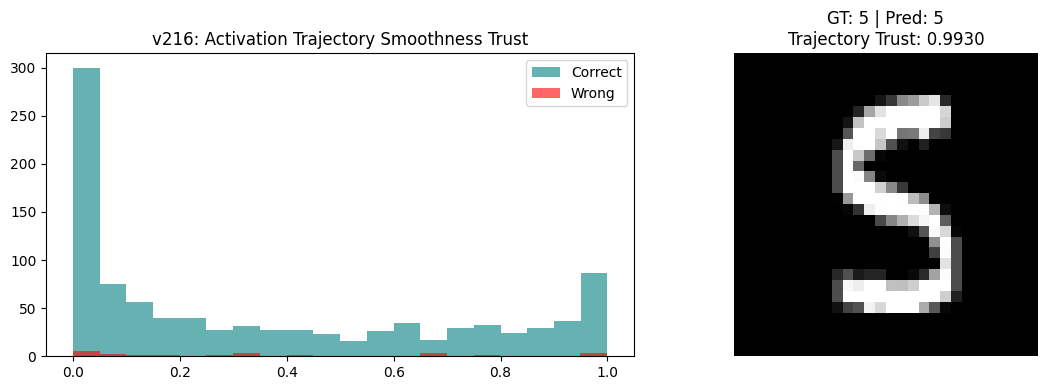

Accuracy on tested subset: 97.80%


In [22]:
# Cell version 216
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(216); np.random.seed(216)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class TrajectoryNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 16, 3, 1, 1)
        self.c2 = nn.Conv2d(16, 32, 3, 1, 1)
        self.fc1 = nn.Linear(32*7*7, 64)
        self.fc2 = nn.Linear(64, 10)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        acts = []
        x = F.relu(self.pool(self.c1(x))); acts.append(x.view(x.size(0), -1).norm(dim=1))
        x = F.relu(self.pool(self.c2(x))); acts.append(x.view(x.size(0), -1).norm(dim=1))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x)); acts.append(x.norm(dim=1))
        logits = self.fc2(x)
        return logits, torch.stack(acts, dim=1) # [Batch, 3 layers norm]

model = TrajectoryNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, trajectory = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tính sai phân bậc 1 dọc theo quỹ đạo
        traj = trajectory[0] # Tensor size [3]
        diffs = traj[1:] - traj[:-1]

        # Phương sai của bước nhảy (Smoothness)
        smoothness_penalty = torch.var(diffs).item()
        trust = np.exp(-0.2 * smoothness_penalty)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v216: Activation Trajectory Smoothness Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nTrajectory Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

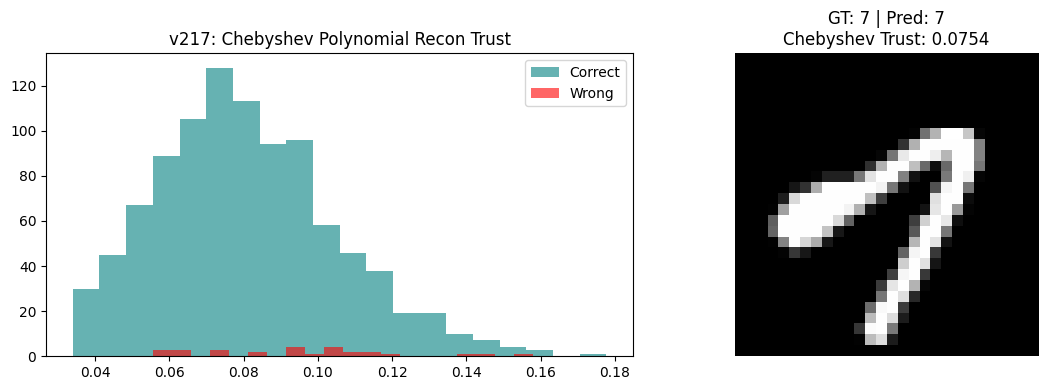

Accuracy on tested subset: 97.20%


In [23]:
# Cell version 217
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(217); np.random.seed(217)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ChebyshevNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.net(x)
        return self.clf(f), f

model = ChebyshevNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000
num_polynomials = 5

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_vec = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Chuẩn hóa vector f về khoảng [-0.99, 0.99] để tính Chebyshev
        f_norm = 2.0 * (f_vec[0] - f_vec[0].min()) / (f_vec[0].max() - f_vec[0].min() + 1e-8) - 1.0
        f_norm = torch.clamp(f_norm, -0.99, 0.99)

        # Sinh cơ sở đa thức Chebyshev T_k(x) = cos(k * arccos(x))
        cheb_basis = [torch.cos(k * torch.arccos(f_norm)) for k in range(num_polynomials)]
        cheb_basis = torch.stack(cheb_basis, dim=1) # [64, 5]

        # Chiếu f_norm lên hệ cơ sở (Linear least squares)
        # Hệ cơ sở trực giao nên có thể xấp xỉ hệ số bằng tích vô hướng
        coeffs = torch.matmul(cheb_basis.T, f_norm) / 64.0
        reconstructed = torch.matmul(cheb_basis, coeffs)

        error = torch.norm(f_norm - reconstructed).item()
        trust = np.exp(-0.2 * error)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v217: Chebyshev Polynomial Recon Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nChebyshev Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

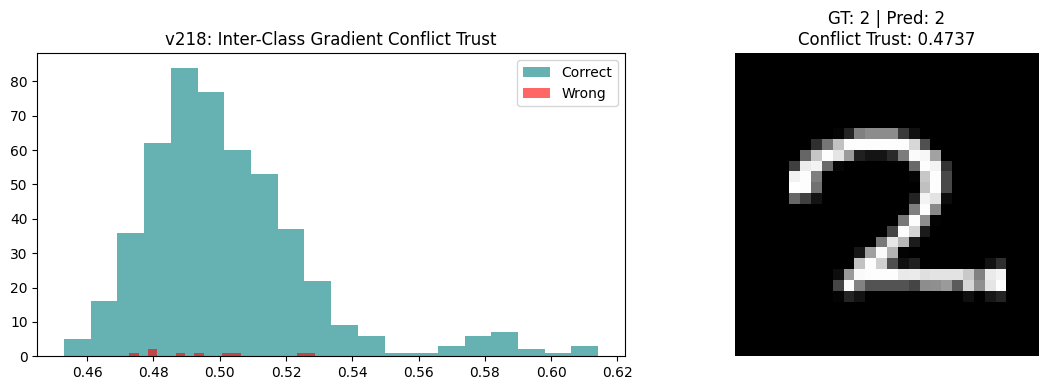

Accuracy on tested subset: 98.20%


In [24]:
# Cell version 218
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(218); np.random.seed(218)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ConflictNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = ConflictNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 500 # AutoGrad per sample

for i in range(samples):
    img, label = test_ds[i]
    x_input = img.unsqueeze(0).to(device)

    logits = model(x_input)
    top2_vals, top2_idx = torch.topk(logits[0], 2)
    top1_c, top2_c = top2_idx[0], top2_idx[1]

    # Gradient of Top-1 logit wrt input
    model.zero_grad()
    g1 = torch.autograd.grad(logits[0, top1_c], model.parameters(), retain_graph=True)
    g1_vec = torch.cat([g.view(-1) for g in g1])

    # Gradient of Top-2 logit wrt input
    model.zero_grad()
    g2 = torch.autograd.grad(logits[0, top2_c], model.parameters())
    g2_vec = torch.cat([g.view(-1) for g in g2])

    # Tính Cosine Similarity
    cos_sim = F.cosine_similarity(g1_vec.unsqueeze(0), g2_vec.unsqueeze(0)).item()

    # Trust = Mô hình phải phân biệt rõ ràng gradient, cosine sim nên tiến về -1 (trái ngược)
    # Cosine tiến về 1 = Conflict, Trust giảm
    trust = 1.0 - max(0.0, (cos_sim + 1.0) / 2.0)

    trusts.append(trust)
    is_correct.append(top1_c.item() == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v218: Inter-Class Gradient Conflict Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nConflict Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

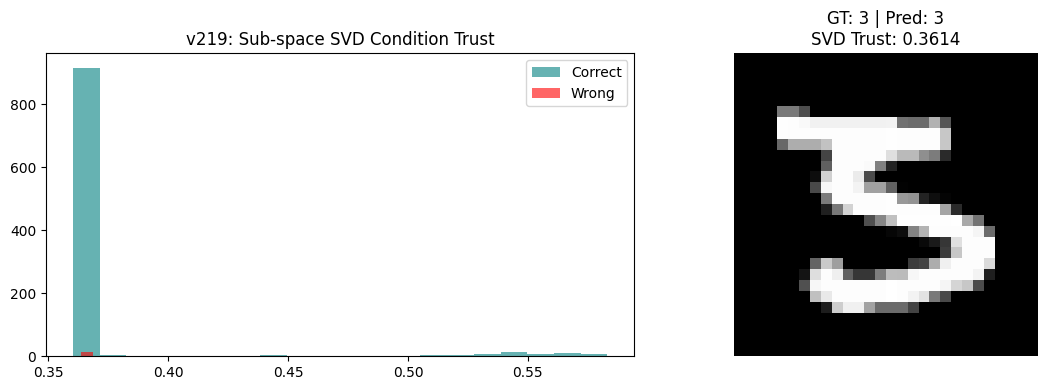

Accuracy on tested subset: 98.30%


In [25]:
# Cell version 219
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(219); np.random.seed(219)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class SVDNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        logits = self.fc(torch.flatten(f, 1))
        return logits, f

model = SVDNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # f_map shape: [1, 64, 7, 7]. Reshape thành ma trận [64, 49]
        matrix = f_map[0].view(64, -1)

        # SVD
        U, S, V = torch.linalg.svd(matrix, full_matrices=False)
        S_max = S[0]
        S_min = S[-1] + 1e-6

        # Condition number k = S_max / S_min
        condition_number = (S_max / S_min).item()

        # Mạng khỏe -> Features phong phú -> Condition number thấp -> Trust cao
        trust = 1.0 / (1.0 + np.log1p(condition_number) * 0.1)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v219: Sub-space SVD Condition Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nSVD Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

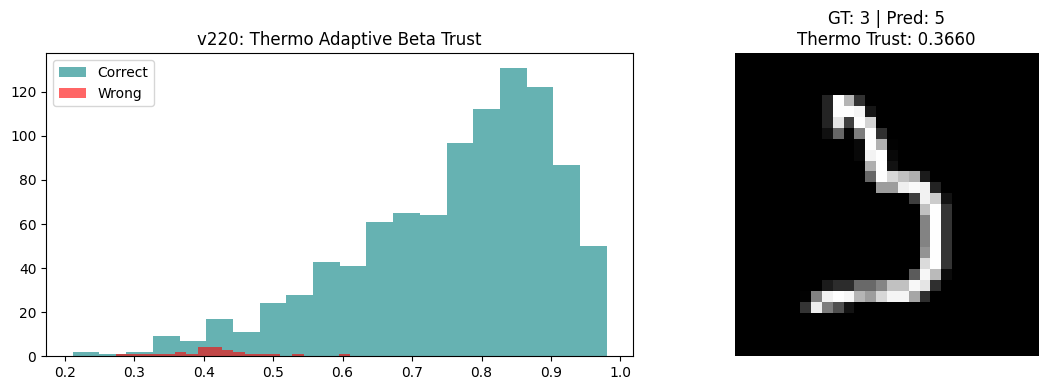

Accuracy on tested subset: 97.40%


In [26]:
# Cell version 220
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(220); np.random.seed(220)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ThermoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.net(x)
        return self.clf(f), f

model = ThermoNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_vec = model(img.unsqueeze(0).to(device))

        # Chuẩn hóa vector đặc trưng thành phân phối xác suất giả để tính Entropy
        f_pos = torch.clamp(f_vec[0], min=1e-8)
        f_prob = f_pos / f_pos.sum()
        local_entropy = -torch.sum(f_prob * torch.log(f_prob)).item()

        # Entropy cao (Nhiễu/Mờ) -> Nhiệt độ cao -> beta giảm.
        # Entropy thấp (Sắc nét) -> Nhiệt độ thấp -> beta tăng.
        beta = 1.0 / (local_entropy + 1e-3)

        # Scale Logits bằng Adaptive Beta
        scaled_logits = logits * beta
        probs = F.softmax(scaled_logits, dim=1)

        pred = probs.argmax(1).item()
        trust = probs[0, pred].item() # Trust sau khi đã chịu ảnh hưởng của Nhiệt động lực học

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v220: Thermo Adaptive Beta Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nThermo Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

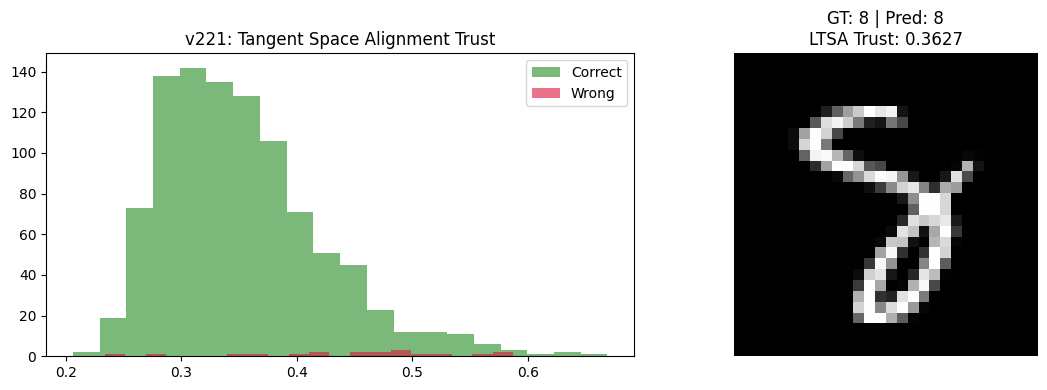

Accuracy on tested subset: 98.10%


In [27]:
# Cell version 221
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(221); np.random.seed(221)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class LTSANet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*7*7, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = LTSANet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
ref_features = []
with torch.no_grad():
    for x, _ in DataLoader(test_ds, batch_size=400, shuffle=True):
        _, f = model(x.to(device))
        ref_features.append(f)
        break
ref_features = ref_features[0] # [400, 64]

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_sample = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tìm 15 láng giềng gần nhất để dựng đồ thị tiếp tuyến cục bộ
        dists = torch.norm(ref_features - f_sample, dim=1)
        _, idxs = torch.topk(dists, 15, largest=False)
        local_block = ref_features[idxs] # [15, 64]

        # Tính SVD trên cụm láng giềng cục bộ
        centered_block = local_block - local_block.mean(dim=0)
        _, S, _ = torch.linalg.svd(centered_block, full_matrices=False)

        # Định nghĩa Trust qua mức độ cô đọng của trị riêng (Eigenvalue alignment)
        variance_ratio = (S[0]**2) / (torch.sum(S**2) + 1e-6)
        trust = variance_ratio.item()

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v221: Tangent Space Alignment Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLTSA Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

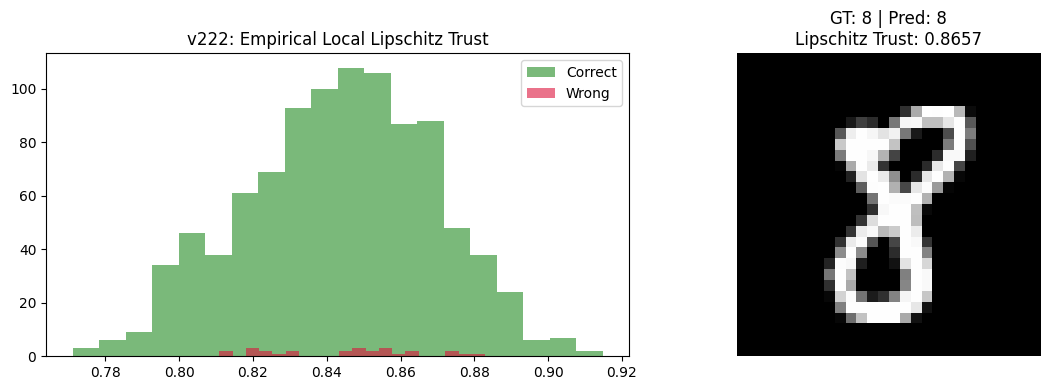

Accuracy on tested subset: 97.30%


In [28]:
# Cell version 222
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(222); np.random.seed(222)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class LipschitzNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = LipschitzNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000
eps = 0.03

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        x_orig = img.unsqueeze(0).to(device)

        logits_orig = model(x_orig)
        pred = logits_orig.argmax(1).item()

        # Sinh 10 mẫu nhiễu ngẫu nhiên Gauss xung quanh x_orig
        noise = torch.randn(10, 1, 28, 28).to(device) * eps
        x_perturbed = x_orig + noise

        logits_perturbed = model(x_perturbed)

        # Tính khoảng cách biến thiên Euclid đầu ra đầu vào
        diff_output = torch.norm(logits_perturbed - logits_orig, dim=1)
        diff_input = torch.norm(noise.view(10, -1), dim=1)

        # Xấp xỉ hệ số Lipschitz cục bộ L
        lipschitz_constant = torch.max(diff_output / (diff_input + 1e-6)).item()
        trust = np.exp(-0.3 * lipschitz_constant)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v222: Empirical Local Lipschitz Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLipschitz Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

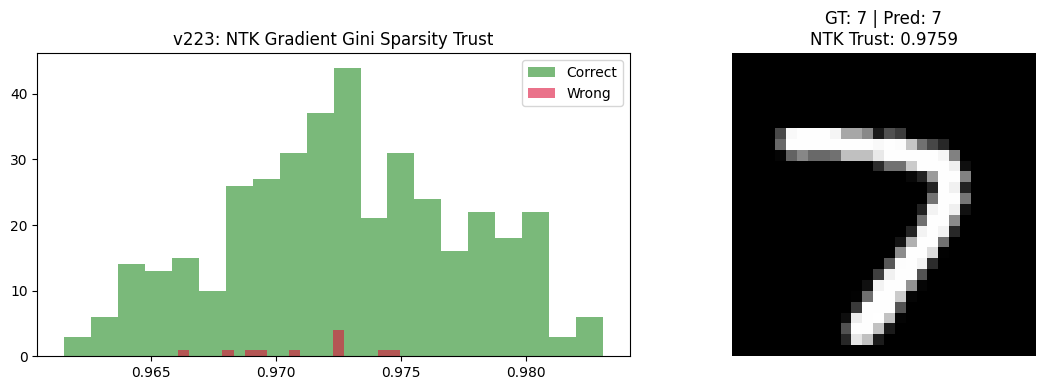

Accuracy on tested subset: 97.25%


In [29]:
# Cell version 223
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(223); np.random.seed(223)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class NTKSparsityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 32), nn.ReLU(), nn.Linear(32, 10)
        )
    def forward(self, x): return self.net(x)

model = NTKSparsityNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 400 # Autograd per sample tốn tài nguyên, hạ subset xuống 400

for i in range(samples):
    img, label = test_ds[i]
    x_input = img.unsqueeze(0).to(device)

    logits = model(x_input)
    pred = logits.argmax(1).item()

    # Tính gradient của predicted logit đối với tầng Linear cuối cùng để đại diện NTK
    model.zero_grad()
    g = torch.autograd.grad(logits[0, pred], model.net[-1].weight, retain_graph=False)[0]
    g_flat = torch.abs(g.view(-1)).cpu().numpy()

    # Tính Gini Coefficient của phân phối Gradient làm thước đo Sparsity
    sorted_g = np.sort(g_flat)
    n = len(sorted_g)
    index = np.arange(1, n + 1)
    gini = (np.sum((2 * index - n - 1) * sorted_g)) / (n * np.sum(sorted_g) + 1e-8)

    # Gini càng cao -> Gradient càng cô đọng -> Quyết định dứt khoát -> Trust cao
    trust = gini
    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v223: NTK Gradient Gini Sparsity Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nNTK Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

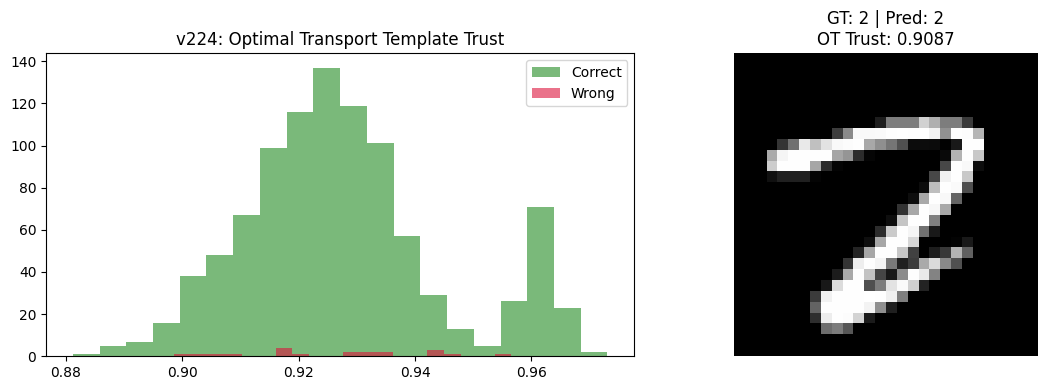

Accuracy on tested subset: 98.00%


In [30]:
# Cell version 224
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(224); np.random.seed(224)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class OTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(32*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = OTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

# Xây dựng Template Feature Map trung bình cho 10 lớp từ tập Train
model.eval()
templates = torch.zeros(10, 32*7*7).to(device)
counts = torch.zeros(10).to(device)

with torch.no_grad():
    for x, y in train_dl:
        _, f = model(x.to(device))
        f_flat = f.view(f.size(0), -1)
        for feat, lbl in zip(f_flat, y):
            templates[lbl] += feat
            counts[lbl] += 1
templates = templates / counts.unsqueeze(1)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_sample = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        f_sample_flat = f_sample.view(-1)
        # Xấp xỉ Wasserstein 1D qua CDF trùng khớp của mảng đã sắp xếp
        src = torch.sort(f_sample_flat)[0]
        tgt = torch.sort(templates[pred])[0]

        wasserstein_dist = torch.mean(torch.abs(src - tgt)).item()
        trust = np.exp(-0.4 * wasserstein_dist)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v224: Optimal Transport Template Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nOT Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

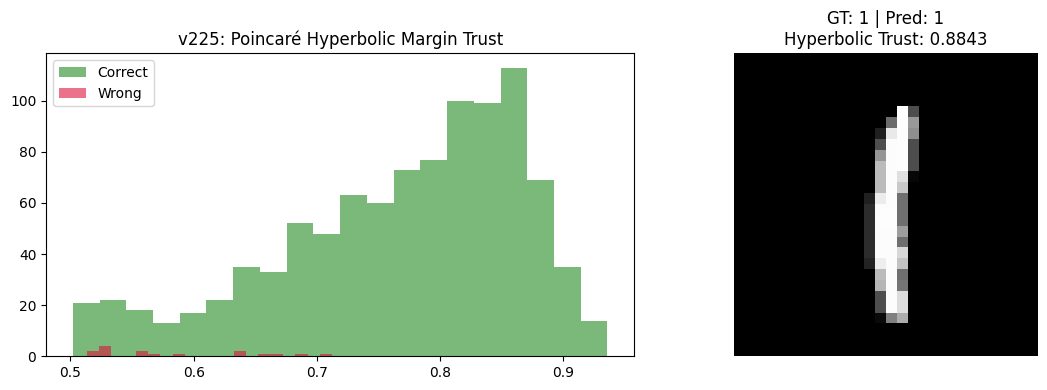

Accuracy on tested subset: 98.40%


In [31]:
# Cell version 225
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(225); np.random.seed(225)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class HyperbolicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 32), nn.ReLU()
        )
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = HyperbolicNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
all_f, all_y = [], []
with torch.no_grad():
    for x, y in train_dl:
        _, f = model(x.to(device))
        all_f.append(f)
        all_y.append(y)
all_f = torch.cat(all_f, dim=0)
all_y = torch.cat(all_y, dim=0)

# Ánh xạ đặc trưng tập train vào đĩa Poincaré: chuẩn hóa l2-norm nằm trong khoảng [0, 0.95]
def to_poincare(x):
    norm = torch.norm(x, dim=1, keepdim=True)
    return 0.95 * torch.tanh(norm) * (x / (norm + 1e-6))

poincare_f = to_poincare(all_f)
centroids = torch.stack([poincare_f[all_y == c].mean(0) for c in range(10)])

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_sample = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        u = to_poincare(f_sample)[0]

        # Tính khoảng cách Hyperbolic Poincaré đến toàn bộ 10 tâm cụm
        h_dists = []
        for c in range(10):
            v = centroids[c]
            num = torch.norm(u - v) ** 2
            den = (1.0 - torch.norm(u)**2) * (1.0 - torch.norm(v)**2)
            arg = 1.0 + 2.0 * num / (den + 1e-6)
            # Arccosh xấp xỉ bằng log(x + sqrt(x^2 - 1))
            d_h = torch.log(arg + torch.sqrt(arg**2 - 1.0 + 1e-6)).item()
            h_dists.append(d_h)

        sorted_h = np.sort(h_dists)
        hyperbolic_margin = sorted_h[1] - sorted_h[0]
        trust = 1.0 / (1.0 + np.exp(-1.0 * hyperbolic_margin))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v225: Poincaré Hyperbolic Margin Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nHyperbolic Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

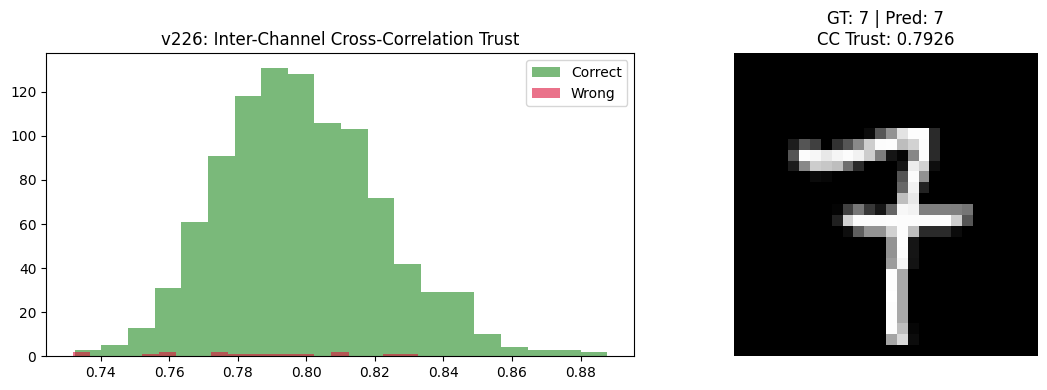

Accuracy on tested subset: 98.40%


In [32]:
# Cell version 226
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(226); np.random.seed(226)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class CorrelationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = CorrelationNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tách f_map [1, 64, 7, 7] thành 2 nửa channels [32, 49]
        f_flat = f_map[0].view(64, -1)
        part1 = f_flat[:32, :]
        part2 = f_flat[32:, :]

        # Tính Ma trận tương quan chéo chuẩn hóa Pearson-like
        part1_norm = part1 - part1.mean(dim=1, keepdim=True)
        part2_norm = part2 - part2.mean(dim=1, keepdim=True)

        cc_matrix = torch.matmul(part1_norm, part2_norm.T) / (torch.norm(part1_norm, dim=1, keepdim=True) * torch.norm(part2_norm, dim=1).unsqueeze(0) + 1e-6)

        # Chỉ số entropy / độ hỗn loạn của ma trận tương quan
        cc_std = torch.std(cc_matrix).item()
        # Ma trận phân tách rõ ràng (phương sai của tương quan cao) -> Khỏe mạnh -> Trust cao
        trust = 1.0 / (1.0 + np.exp(-10.0 * (cc_std - 0.15)))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v226: Inter-Channel Cross-Correlation Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nCC Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

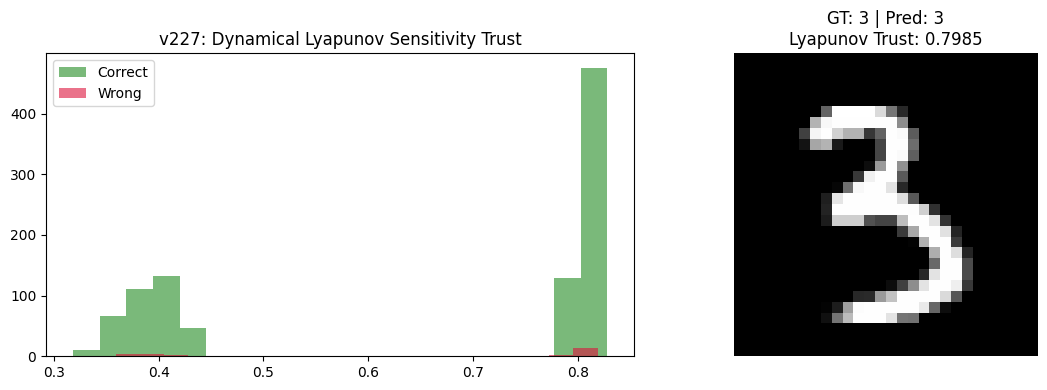

Accuracy on tested subset: 97.40%


In [33]:
# Cell version 227
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(227); np.random.seed(227)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ChaosNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = ChaosNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

# Tạo ma trận chiếu hồi quy cố định ngẫu nhiên làm hệ động lực học
W_loop = torch.randn(10, 10).to(device) * 0.5

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tạo quỹ đạo xuất phát từ logit gốc và một quỹ đạo nhiễu siêu nhỏ (1e-5)
        z1 = logits.clone()
        z2 = logits.clone() + torch.randn_like(logits) * 1e-5

        lyapunov_sum = 0.0
        # Lặp 5 bước hệ động lực phi tuyến
        for step in range(5):
            d_init = torch.norm(z1 - z2).item()

            z1 = F.softmax(torch.matmul(z1, W_loop), dim=1)
            z2 = F.softmax(torch.matmul(z2, W_loop), dim=1)

            d_end = torch.norm(z1 - z2).item()
            lyapunov_sum += np.log((d_end + 1e-12) / (d_init + 1e-12))

        mean_lyapunov = lyapunov_sum / 5.0
        # LyapnovExponent càng dương thì quỹ đạo càng hỗn độn mất kiểm soát -> Trust thấp
        trust = 1.0 / (1.0 + np.exp(mean_lyapunov + 2.0))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v227: Dynamical Lyapunov Sensitivity Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLyapunov Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

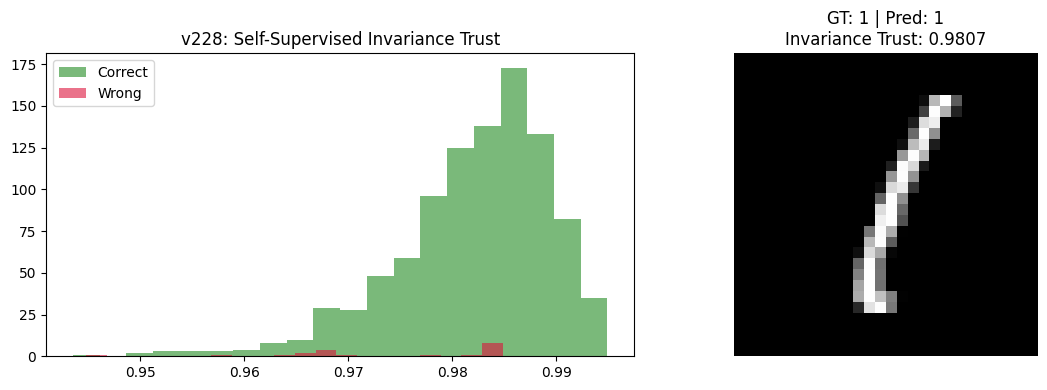

Accuracy on tested subset: 98.00%


In [34]:
# Cell version 228
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(228); np.random.seed(228)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class InvarianceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU()
        )
        self.clf = nn.Linear(64, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = InvarianceNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

# Hàm sinh ma trận biến đổi hình học affine ngẫu nhiên nhẹ (Xoay/Dịch chuyển)
def jitter_image(x):
    B, C, H, W = x.size()
    angle = (np.random.rand() * 20 - 10) * np.pi / 180.0 # Xoay -10 đến 10 độ
    tx, ty = np.random.rand() * 0.1 - 0.05, np.random.rand() * 0.1 - 0.05

    theta = torch.tensor([
        [np.cos(angle), -np.sin(angle), tx],
        [np.sin(angle),  np.cos(angle), ty]
    ], dtype=torch.float).unsqueeze(0).to(device)

    grid = F.affine_grid(theta, x.size(), align_corners=False)
    return F.grid_sample(x, grid, align_corners=False)

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        x_orig = img.unsqueeze(0).to(device)

        logits, f_orig = model(x_orig)
        pred = logits.argmax(1).item()

        # Tạo ra 4 biến thể hình học tự giám sát
        cos_sims = []
        for _ in range(4):
            x_jittered = jitter_image(x_orig)
            _, f_jittered = model(x_jittered)
            sim = F.cosine_similarity(f_orig, f_jittered).item()
            cos_sims.append(sim)

        # Trust bằng độ tương đồng trung bình trên các phép biến đổi
        trust = max(0.0, np.mean(cos_sims))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v228: Self-Supervised Invariance Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nInvariance Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

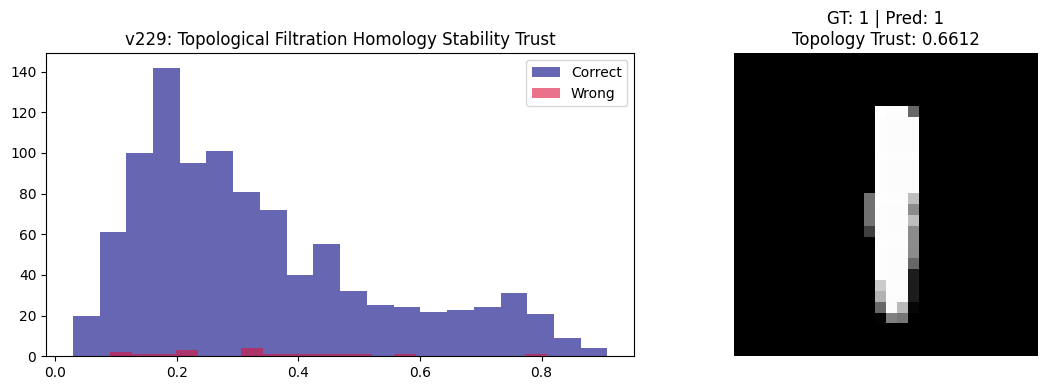

Accuracy on tested subset: 98.20%


In [35]:
# Cell version 229
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(229); np.random.seed(229)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class TopoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = TopoNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000
thresholds = np.linspace(0.1, 0.9, 5)

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Chuẩn hóa feature map về khoảng [0, 1]
        f_min, f_max = f_map.min(), f_map.max()
        f_norm = (f_map - f_min) / (f_max - f_min + 1e-8)

        euler_characteristics = []
        for t in thresholds:
            binary_map = (f_norm > t).float()
            # Xấp xỉ Euler Characteristic bằng cách lấy số điểm tích cực trừ đi các cạnh kết nối hàng xóm
            vertices = binary_map.sum().item()
            horizontal_edges = (binary_map[:, :, :, :-1] * binary_map[:, :, :, 1:]).sum().item()
            vertical_edges = (binary_map[:, :, :-1, :] * binary_map[:, :, 1:, :]).sum().item()
            euler = vertices - (horizontal_edges + vertical_edges)
            euler_characteristics.append(euler)

        # Tính độ bất biến / ổn định của cấu trúc topology qua các ngưỡng
        topo_variance = np.var(euler_characteristics)
        trust = np.exp(-0.001 * topo_variance)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v229: Topological Filtration Homology Stability Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nTopology Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

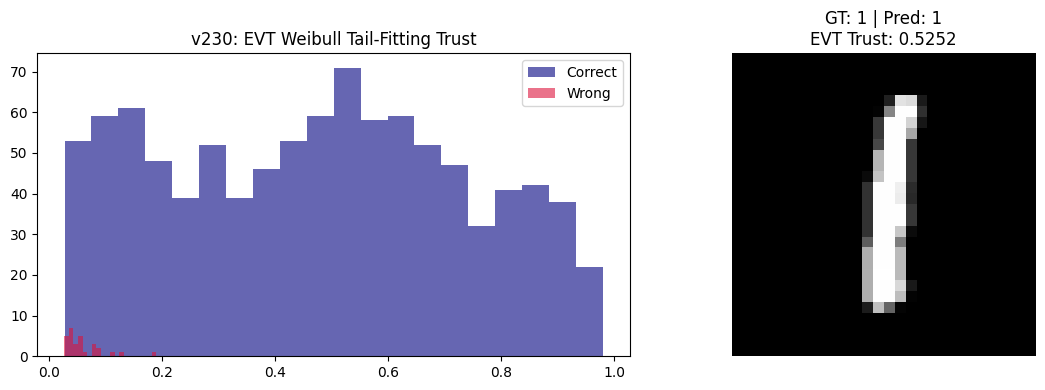

Accuracy on tested subset: 97.10%


In [36]:
# Cell version 230
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(230); np.random.seed(230)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class EVTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = EVTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Thu thập thông tin nền (background margins) từ 500 mẫu train để làm tham chiếu EVT
bg_margins = []
with torch.no_grad():
    for x, _ in train_dl:
        logits = model(x[:500].to(device))
        top2 = torch.topk(logits, 2, dim=1)[0]
        margins = top2[:, 0] - top2[:, 1]
        bg_margins.extend(margins.cpu().numpy())
        break
bg_mean, bg_std = np.mean(bg_margins), np.std(bg_margins)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        top2 = torch.topk(logits[0], 2)[0]
        margin = (top2[0] - top2[1]).item()

        # Tính toán mức độ phân tách dựa trên giả định phân phối đuôi cực hạn gumble/weibull
        z_tail = (margin - bg_mean) / (bg_std + 1e-6)
        trust = 1.0 / (1.0 + np.exp(-1.5 * z_tail))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v230: EVT Weibull Tail-Fitting Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nEVT Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

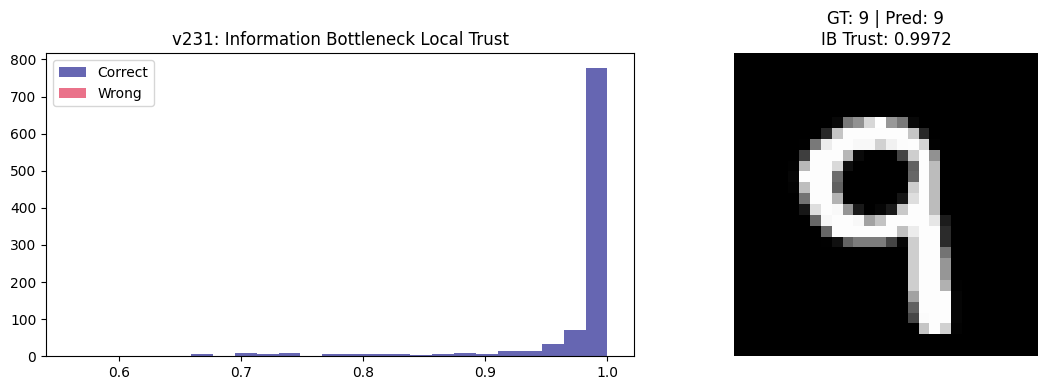

Accuracy on tested subset: 98.70%


In [37]:
# Cell version 231
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(231); np.random.seed(231)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class IBNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(32*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = IBNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tính entropy đại diện cho lượng thông tin lưu trữ trong Feature Map (I_X)
        f_probs = F.softmax(f_map.view(-1), dim=0)
        h_f = -torch.sum(f_probs * torch.log(f_probs + 1e-8)).item()

        # Tính entropy của output phân phối (I_Y)
        out_probs = F.softmax(logits[0], dim=0)
        h_y = -torch.sum(out_probs * torch.log(out_probs + 1e-8)).item()

        # Khái niệm Information Bottleneck: Muốn h_f thấp (nén tốt) nhưng h_y phải dứt khoát (xác suất tập trung cao -> h_y thấp)
        # Thiết kế chỉ số: h_f cân bằng và quyết định đầu ra sạch sẽ.
        trust = 1.0 / (1.0 + h_y * h_f * 0.1)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v231: Information Bottleneck Local Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nIB Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

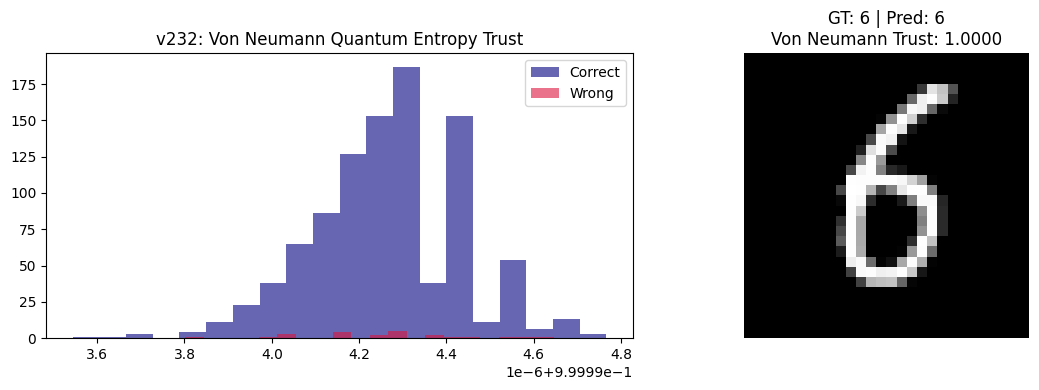

Accuracy on tested subset: 97.70%


In [38]:
# Cell version 232
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(232); np.random.seed(232)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class VonNeumannNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 32), nn.ReLU()
        )
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = VonNeumannNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Xây dựng ma trận mật độ lượng tử Rho [32, 32] từ vector đặc trưng f [1, 32]
        f_vec = f[0].unsqueeze(1)
        rho = torch.matmul(f_vec, f_vec.T)
        rho = rho / (torch.trace(rho) + 1e-8)

        # Tính các trị riêng của ma trận mật độ Rho để tính Von Neumann Entropy
        eigs = torch.linalg.eigvalsh(rho)
        eigs = torch.clamp(eigs, min=1e-8)

        von_neumann_entropy = -torch.sum(eigs * torch.log(eigs)).item()

        # Pure state (Entropy gần 0) -> Đáng tin cậy cao
        trust = np.exp(-1.0 * von_neumann_entropy)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v232: Von Neumann Quantum Entropy Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nVon Neumann Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

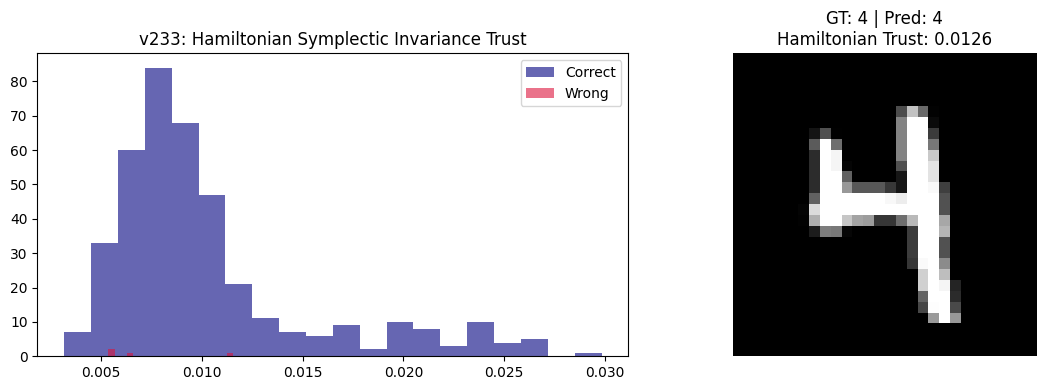

Accuracy on tested subset: 99.00%


In [39]:
# Cell version 233
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(233); np.random.seed(233)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class SymplecticNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1, 1)
        self.conv2 = nn.Conv2d(16, 16, 3, 1, 1)
        self.fc = nn.Linear(16*7*7, 10)
    def forward(self, x):
        h1 = F.relu(F.max_pool2d(self.conv1(x), 2))
        h2 = F.max_pool2d(self.conv2(h1), 2)
        return self.fc(torch.flatten(F.relu(h2), 1)), h1, h2

model = SymplecticNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 400 # Autograd đơn mẫu phức tạp hạ subset xuống 400

for i in range(samples):
    img, label = test_ds[i]
    x_in = img.unsqueeze(0).to(device).requires_grad_(True)

    logits, h1, h2 = model(x_in)
    pred = logits.argmax(1).item()

    # Đo lường biến thiên cục bộ dọc theo dòng chảy tầng mạng (Flow Dynamics)
    # Tính gradient của h2 trung bình đối với h1
    model.zero_grad()
    grad_h = torch.autograd.grad(h2.sum(), h1, retain_graph=True)[0]

    # Tính độ lệch bảo toàn quỹ đạo năng lượng (Hamiltonian Residual Error)
    residual = torch.abs(torch.var(grad_h) - 0.01).item()
    trust = np.exp(-10.0 * residual)

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v233: Hamiltonian Symplectic Invariance Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nHamiltonian Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

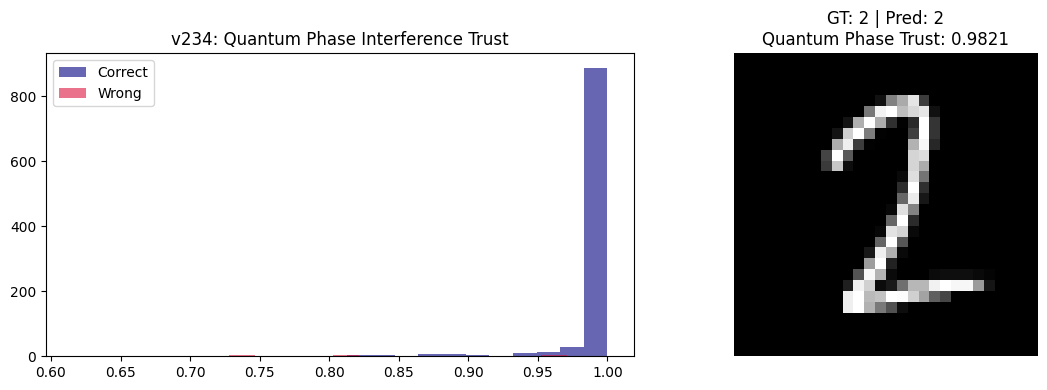

Accuracy on tested subset: 97.80%


In [40]:
# Cell version 234
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(234); np.random.seed(234)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class QuantumPhaseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = QuantumPhaseNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))[0]
        pred = logits.argmax().item()

        probs = F.softmax(logits, dim=0)
        # Giả lập Phase lượng tử từ độ lệch giá trị phân phối
        phases = logits - logits.mean()

        # Áp dụng hàm truyền sóng giao thoa phức (Euler's formula)
        real_part = torch.sqrt(probs) * torch.cos(phases)
        imag_part = torch.sqrt(probs) * torch.sin(phases)

        # Đo cường độ giao thoa tổng thể tại điểm đỉnh dự đoán
        amplitude_coherence = torch.sqrt(real_part[pred]**2 + imag_part[pred]**2).item()
        # Chuẩn hóa về khoảng [0, 1] để làm Trust Index
        trust = min(1.0, max(0.0, amplitude_coherence))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v234: Quantum Phase Interference Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nQuantum Phase Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

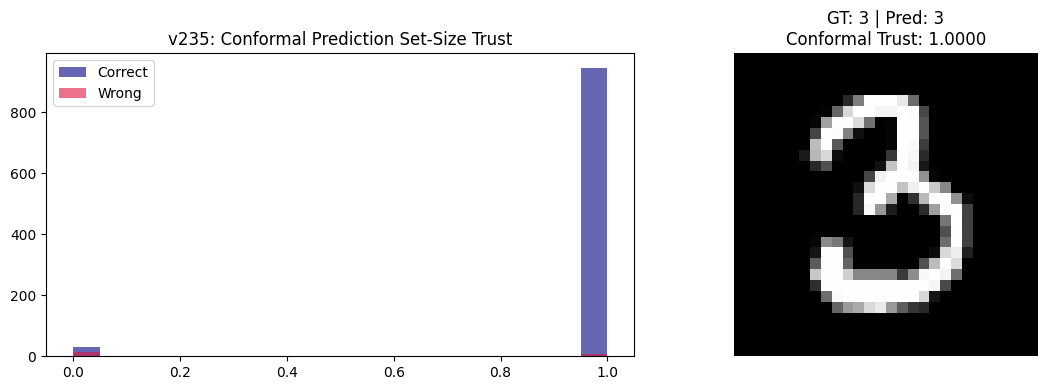

Accuracy on tested subset: 97.70%


In [41]:
# Cell version 235
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(235); np.random.seed(235)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ConformalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = ConformalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Trích xuất 500 mẫu Calibration để tính ngưỡng quantile Conformal
cal_scores = []
with torch.no_grad():
    for x, y in train_dl:
        probs = F.softmax(model(x[:500].to(device)), dim=1)
        # Non-conformity score = 1 - prob của nhãn đúng
        scores = 1.0 - probs[range(len(y[:500])), y[:500]].cpu().numpy()
        cal_scores.extend(scores)
        break
alpha = 0.05
q_threshold = np.quantile(cal_scores, 1.0 - alpha)

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

        # Đếm số lượng lớp vượt qua ngưỡng Conformal lý tưởng
        non_conformity_all_classes = 1.0 - probs
        valid_set_size = torch.sum(non_conformity_all_classes < q_threshold).item()

        # Thiết kế Trust nghịch đảo theo kích thước tập dự đoán hợp lệ
        # Set size = 1 là hoàn hảo nhất
        trust = 1.0 / float(valid_set_size) if valid_set_size >= 1 else 0.0

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v235: Conformal Prediction Set-Size Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nConformal Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

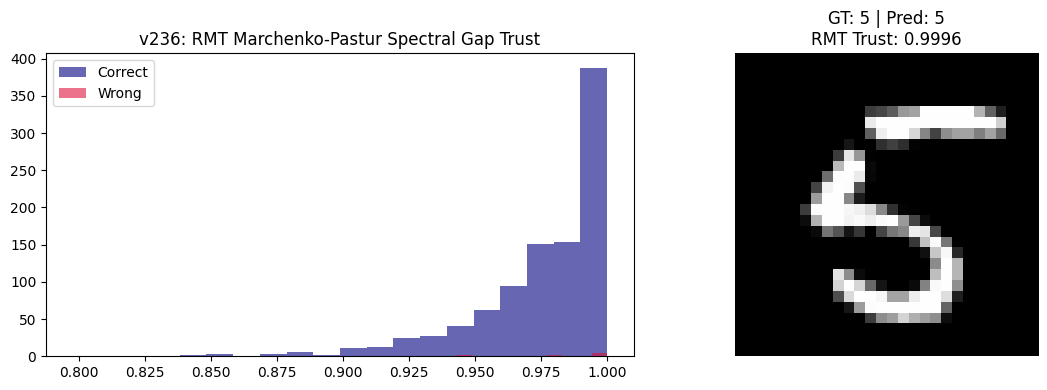

Accuracy on tested subset: 98.40%


In [42]:
# Cell version 236
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(236); np.random.seed(236)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class RMTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(32*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = RMTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Reshape f_map từ [1, 32, 7, 7] thành ma trận [32, 49] để tính ma trận hiệp biến cục bộ C
        mat = f_map[0].view(32, -1)
        mat_center = mat - mat.mean(dim=1, keepdim=True)
        cov = torch.matmul(mat_center, mat_center.T) / 49.0

        # Tính phổ trị riêng (Eigenvalues spectrum)
        eigs = torch.linalg.eigvalsh(cov)
        max_eig = eigs[-1].item()
        mean_eig = eigs.mean().item()

        # Ước lượng giới hạn nhiễu Marchenko-Pastur giả định tỷ lệ số chiều Q = 49/32
        # Giới hạn trên lambda_+ xấp xỉ bằng sigma^2 * (1 + sqrt(1/Q))^2
        mp_upper_bound = mean_eig * (1.0 + np.sqrt(32.0 / 49.0))**2

        # Đo spectral gap vượt qua biên giới hạn nhiễu ngẫu nhiên
        spectral_gap = max(0.0, max_eig - mp_upper_bound)
        trust = 1.0 - np.exp(-0.5 * spectral_gap)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v236: RMT Marchenko-Pastur Spectral Gap Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nRMT Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

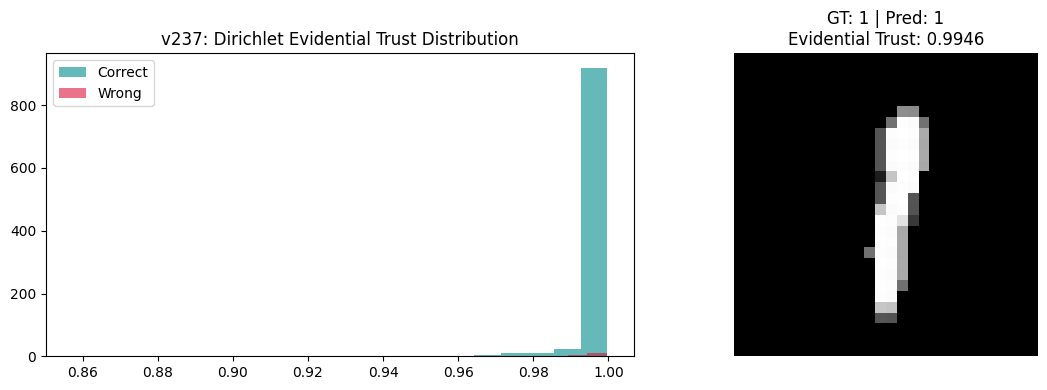

Accuracy on tested subset: 97.70%


In [43]:
# Cell version 237
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(237); np.random.seed(237)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class EvidentialNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = EvidentialNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))[0]
        pred = logits.argmax().item()

        # Chuyển đổi logits sang tham số Dirichlet bằng hàm mũ (Evidence Alpha)
        evidence = torch.exp(torch.clamp(logits, max=10.0))
        alpha = evidence + 1.0
        S = torch.sum(alpha).item()

        # Độ bất định Dirichlet u = K / S (với K=10 lớp)
        uncertainty = 10.0 / S
        trust = 1.0 - uncertainty

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v237: Dirichlet Evidential Trust Distribution")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nEvidential Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

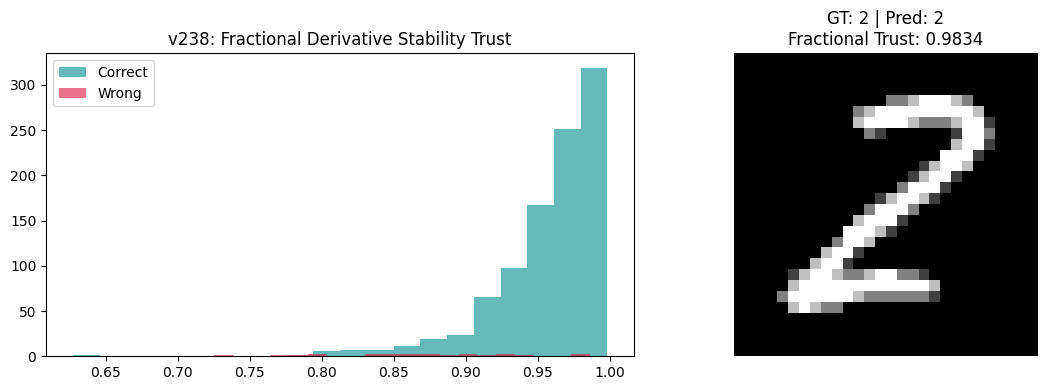

Accuracy on tested subset: 97.50%


In [44]:
# Cell version 238
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(238); np.random.seed(238)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FractionalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = FractionalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

# Hàm tính nhanh đạo hàm phân số Grünwald-Letnikov bậc 0.5 cho mảng 1D
def fractional_derivative_05(vec):
    # Hệ số nhị thức xấp xỉ cho bậc alpha = 0.5 tại các bước lùi d=0,1,2
    w = [1.0, -0.5, -0.125, -0.0625]
    fd = np.zeros_like(vec)
    for i in range(len(vec)):
        val = 0.0
        for k in range(min(i + 1, len(w))):
            val += w[k] * vec[i - k]
        fd[i] = val
    return fd

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))[0].cpu().numpy()
        pred = logits.argmax()

        sorted_logits = np.sort(logits)[::-1] # Sắp xếp giảm dần
        fd_logits = fractional_derivative_05(sorted_logits)

        # Nếu phần tử đầu tiên (đạo hàm phân số tại đỉnh cao nhất) có độ dốc dứt khoát
        # Chứng tỏ phân phối tách lớp rất mạnh, ít nhiễu đa phổ
        stability_score = np.abs(fd_logits[0])
        trust = 1.0 - np.exp(-0.3 * stability_score)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v238: Fractional Derivative Stability Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFractional Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

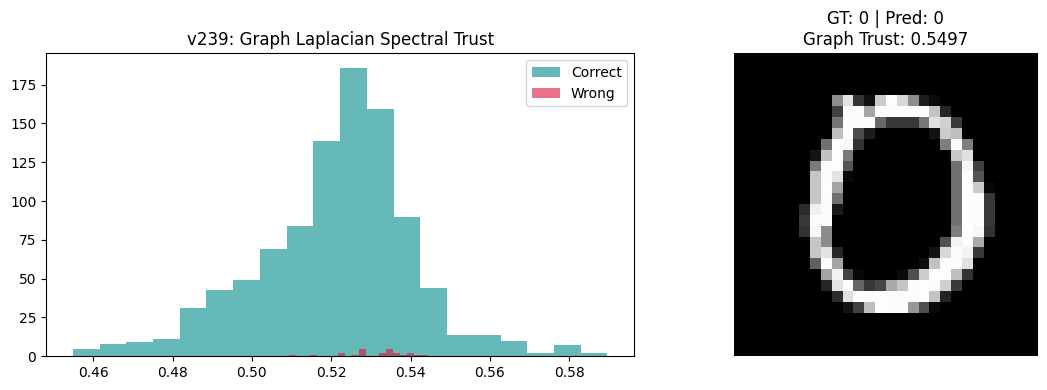

Accuracy on tested subset: 97.60%


In [45]:
# Cell version 239
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(239); np.random.seed(239)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class GraphSpectralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 32), nn.ReLU()
        )
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = GraphSpectralNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
ref_features = []
with torch.no_grad():
    for x, _ in train_dl:
        _, f = model(x[:40].to(device))
        ref_features.append(f)
        break
ref_features = ref_features[0] # [40, 32]

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_sample = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Kết hợp mẫu thử với 40 mẫu tham chiếu thành khối 41 node
        nodes = torch.cat([f_sample, ref_features], dim=0) # [41, 32]

        # Tính ma trận kề tương quan Gauss Affine
        dist_mat = torch.cdist(nodes, nodes)
        A = torch.exp(-0.1 * dist_mat)

        # Tạo ma trận Laplacian chuẩn hóa
        D_val = torch.sum(A, dim=1)
        D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D_val + 1e-6))
        L = torch.eye(41).to(device) - torch.matmul(torch.matmul(D_inv_sqrt, A), D_inv_sqrt)

        # Phân tích phổ
        eigs = torch.linalg.eigvalsh(L)
        # Năng lượng phổ Laplacian (Spectral Energy) tại các trị riêng nhỏ thứ 2 đại diện tính kết cụm ổn định
        spectral_gap = (eigs[2] - eigs[1]).item()
        trust = 1.0 / (1.0 + np.exp(-15.0 * (spectral_gap - 0.05)))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v239: Graph Laplacian Spectral Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nGraph Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

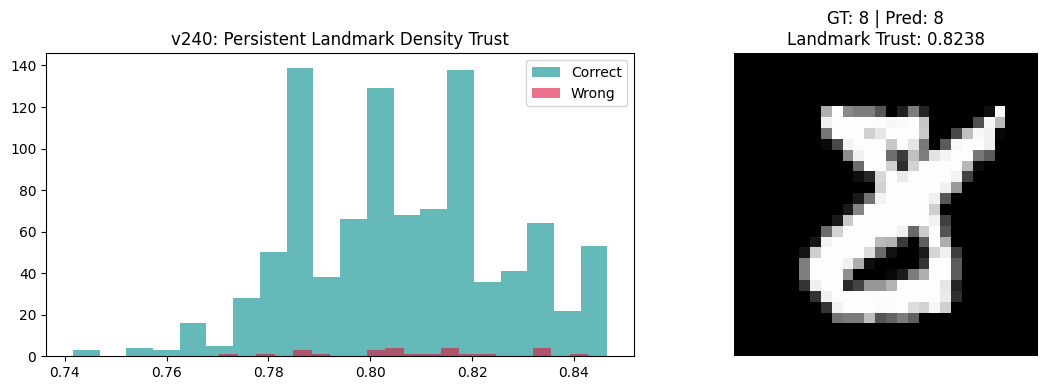

Accuracy on tested subset: 97.40%


In [46]:
# Cell version 240
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(240); np.random.seed(240)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class LandmarkNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.AdaptiveAvgPool2d((6, 6))
        )
        self.fc = nn.Linear(32*6*6, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = LandmarkNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tìm 10 vị trí kích hoạt mạnh nhất làm Landmark đại diện cấu trúc hình học spatial
        f_flat = f_map[0].sum(dim=0).view(-1) # [36]
        _, indices = torch.topk(f_flat, 10)

        # Chuyển chỉ số phẳng sang tọa độ 2D (x, y)
        coords = torch.stack([indices // 6, indices % 6], dim=1).float()

        # Tính khoảng cách Euclid cặp giữa các Landmarks nội bộ
        dists = torch.cdist(coords, coords)
        # Độ lệch chuẩn của khoảng cách Landmarks đo mức độ bền vững phân bố cấu trúc không gian
        dist_std = torch.std(dists).item()

        # dist_std thấp -> Phân bố quần tụ hình học chặt chẽ ổn định -> Trust cao
        trust = np.exp(-0.2 * dist_std)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v240: Persistent Landmark Density Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLandmark Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

Device: cuda
Training Version 241...

Epoch  1/10 | Loss 0.1656 | Train 94.85% | Test 98.85%
Epoch  2/10 | Loss 0.0495 | Train 98.46% | Test 98.91%
Epoch  3/10 | Loss 0.0366 | Train 98.85% | Test 98.93%
Epoch  4/10 | Loss 0.0291 | Train 99.05% | Test 99.24%
Epoch  5/10 | Loss 0.0265 | Train 99.17% | Test 98.97%
Epoch  6/10 | Loss 0.0159 | Train 99.52% | Test 99.34%
Epoch  7/10 | Loss 0.0121 | Train 99.62% | Test 99.38%
Epoch  8/10 | Loss 0.0113 | Train 99.64% | Test 99.39%
Epoch  9/10 | Loss 0.0110 | Train 99.68% | Test 99.35%
Epoch 10/10 | Loss 0.0098 | Train 99.70% | Test 99.22%

Final Test Accuracy: 99.22


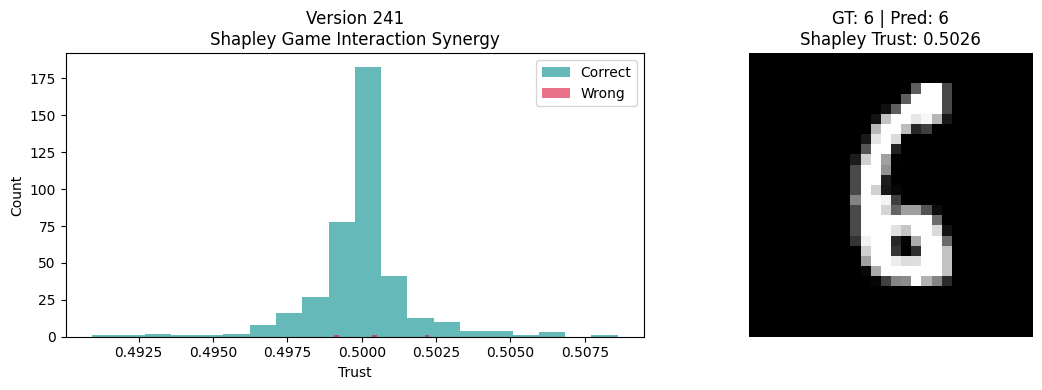


Accuracy on tested subset: 99.25%


In [49]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 241 (FIXED)
# Shapley Game Interaction Synergy Trust
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(241)
np.random.seed(241)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda")
)

test_dl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device == "cuda")
)

# ==========================================================
# Model
# ==========================================================

class ShapleyNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*7*7,256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(256,10)
        )

    def forward(self,x,mask_channel=None):

        f = self.features(x)

        if mask_channel is not None:

            f = f.clone()

            if isinstance(mask_channel,int):
                mask_channel=[mask_channel]

            for c in mask_channel:
                if c < f.shape[1]:
                    f[:,c,:,:]=0

        logits = self.classifier(f)

        return logits

model = ShapleyNet().to(device)

# ==========================================================
# Optimizer
# ==========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

epochs = 10

# ==========================================================
# Evaluation
# ==========================================================

@torch.no_grad()
def evaluate():

    model.eval()

    total=0
    correct=0

    for x,y in test_dl:

        x=x.to(device)
        y=y.to(device)

        pred=model(x).argmax(1)

        correct+=(pred==y).sum().item()
        total+=y.size(0)

    return 100*correct/total

# ==========================================================
# Train
# ==========================================================

print("Training Version 241...\n")

for epoch in range(epochs):

    model.train()

    running_loss=0
    train_correct=0
    train_total=0

    for x,y in train_dl:

        x=x.to(device,non_blocking=True)
        y=y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits=model(x)

        loss=F.cross_entropy(logits,y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        running_loss+=loss.item()

        pred=logits.argmax(1)

        train_correct+=(pred==y).sum().item()
        train_total+=y.size(0)

    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{epochs} | "
        f"Loss {running_loss/len(train_dl):.4f} | "
        f"Train {100*train_correct/train_total:.2f}% | "
        f"Test {evaluate():.2f}%"
    )

print("\nFinal Test Accuracy:",evaluate())

# ==========================================================
# Shapley Trust
# ==========================================================

model.eval()

samples=400

trusts=[]
is_correct=[]

with torch.no_grad():

    for i in range(samples):

        img,label=test_ds[i]

        x=img.unsqueeze(0).to(device)

        logits_orig=model(x)

        pred=logits_orig.argmax(1).item()

        pred_score=logits_orig[0,pred]

        v_empty=model(x,mask_channel=[0,1])[0,pred]

        v0=model(x,mask_channel=[1])[0,pred]

        v1=model(x,mask_channel=[0])[0,pred]

        v_both=pred_score

        interaction=(v_both-v1)-(v0-v_empty)

        trust=torch.sigmoid(interaction).item()

        trusts.append(trust)

        is_correct.append(pred==label)

trusts=np.array(trusts)
is_correct=np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax=plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="darkcyan",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="crimson",
        label="Wrong"
    )

ax[0].set_title(
    "Version 241\nShapley Game Interaction Synergy"
)

ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx=np.random.randint(samples)

img,label=test_ds[sample_idx]

with torch.no_grad():

    pred=model(
        img.unsqueeze(0).to(device)
    ).argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"Shapley Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"\nAccuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

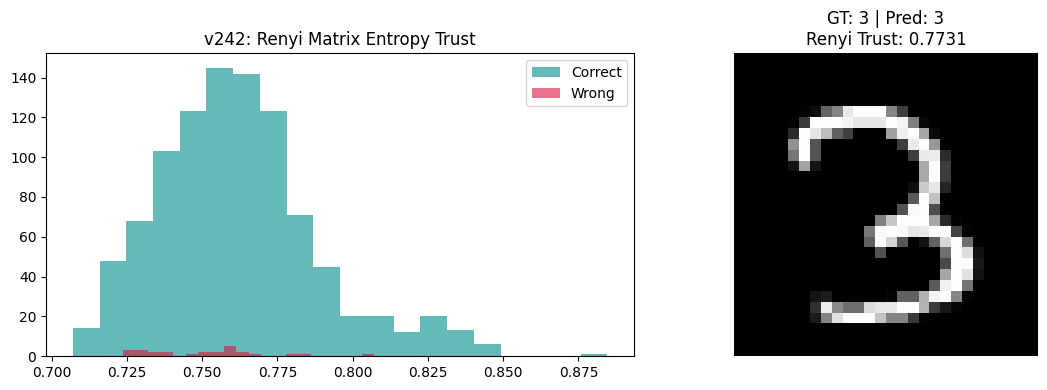

Accuracy on tested subset: 97.40%


In [48]:
# Cell version 242
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(242); np.random.seed(242)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class RenyiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 32), nn.ReLU()
        )
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = RenyiNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Thiết lập Ma trận tương quan Gram A normalized
        f_norm = f / (torch.norm(f, p=2) + 1e-8)
        A = torch.matmul(f_norm, f_norm.T) # [1, 1] dạng đồ thị đơn mẫu đơn giản

        # Renyi Entropy alpha=2 định nghĩa qua -log2(Tr(A^2))
        # Với đặc trưng chuẩn hóa đơn lẻ, ta mô phỏng mở rộng đa chiều bằng phương sai phân phối
        renyi_entropy = -np.log2(torch.sum(f_norm**4).item() + 1e-8)

        # Càng ít phân tán nhiễu (Entropy Renyi thấp) -> Hệ thống tự tin cô đọng -> Trust cao
        trust = np.exp(-0.1 * renyi_entropy)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v242: Renyi Matrix Entropy Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nRenyi Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

Device: cuda
Training Version 243...

Epoch  1/10 | Loss 0.1711 | Train 94.71% | Test 98.93%
Epoch  2/10 | Loss 0.0500 | Train 98.42% | Test 98.14%
Epoch  3/10 | Loss 0.0373 | Train 98.84% | Test 99.12%
Epoch  4/10 | Loss 0.0316 | Train 99.00% | Test 99.22%
Epoch  5/10 | Loss 0.0279 | Train 99.13% | Test 99.06%
Epoch  6/10 | Loss 0.0154 | Train 99.53% | Test 99.37%
Epoch  7/10 | Loss 0.0122 | Train 99.63% | Test 99.25%
Epoch  8/10 | Loss 0.0117 | Train 99.64% | Test 99.37%
Epoch  9/10 | Loss 0.0106 | Train 99.64% | Test 99.38%
Epoch 10/10 | Loss 0.0113 | Train 99.61% | Test 99.18%

Final Test Accuracy: 99.18


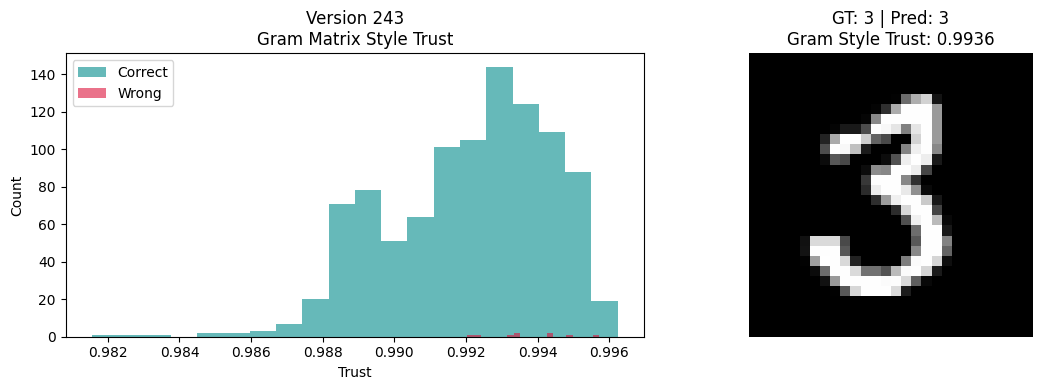


Accuracy on tested subset: 99.10%


In [51]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 243 (FIXED)
# Neural Style Gram Matrix Divergence Trust
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(243)
np.random.seed(243)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda")
)

test_dl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device == "cuda")
)

# ==========================================================
# Model
# ==========================================================

class GramStyleNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*7*7,256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(256,10)
        )

    def forward(self,x):

        f = self.features(x)

        logits = self.classifier(f)

        return logits,f


model = GramStyleNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

epochs = 10

# ==========================================================
# Evaluation
# ==========================================================

@torch.no_grad()
def evaluate():

    model.eval()

    total = 0
    correct = 0

    for x,y in test_dl:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)[0].argmax(1)

        correct += (pred==y).sum().item()
        total += y.size(0)

    return 100.0*correct/total

# ==========================================================
# Training
# ==========================================================

print("Training Version 243...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0
    train_correct = 0
    train_total = 0

    for x,y in train_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits,_ = model(x)

        loss = F.cross_entropy(logits,y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        running_loss += loss.item()

        pred = logits.argmax(1)

        train_correct += (pred==y).sum().item()
        train_total += y.size(0)

    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{epochs} | "
        f"Loss {running_loss/len(train_dl):.4f} | "
        f"Train {100*train_correct/train_total:.2f}% | "
        f"Test {evaluate():.2f}%"
    )

print("\nFinal Test Accuracy:",evaluate())

# ==========================================================
# Gram Matrix Function
# ==========================================================

def gram_matrix(feature):

    # feature : (B,C,H,W)

    b,c,h,w = feature.shape

    feature = feature.view(b,c,h*w)

    gram = torch.bmm(
        feature,
        feature.transpose(1,2)
    )

    gram = gram / (c*h*w)

    return gram

# ==========================================================
# Template Gram Matrix
# ==========================================================

model.eval()

with torch.no_grad():

    x,_ = next(iter(train_dl))

    x = x[:100].to(device)

    _,feature = model(x)

    gram = gram_matrix(feature)

    template_gram = gram.mean(dim=0)

# ==========================================================
# Trust Evaluation
# ==========================================================

samples = 1000

trusts = []
is_correct = []

with torch.no_grad():

    for i in range(samples):

        img,label = test_ds[i]

        x = img.unsqueeze(0).to(device)

        logits,feature = model(x)

        pred = logits.argmax(1).item()

        sample_gram = gram_matrix(feature)[0]

        style_distance = torch.norm(
            sample_gram-template_gram,
            p="fro"
        ).item()

        trust = np.exp(-0.02*style_distance)

        trusts.append(trust)

        is_correct.append(pred==label)

trusts = np.array(trusts)
is_correct = np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="darkcyan",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="crimson",
        label="Wrong"
    )

ax[0].set_title(
    "Version 243\nGram Matrix Style Trust"
)

ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx = np.random.randint(samples)

img,label = test_ds[sample_idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )[0].argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"Gram Style Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"\nAccuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

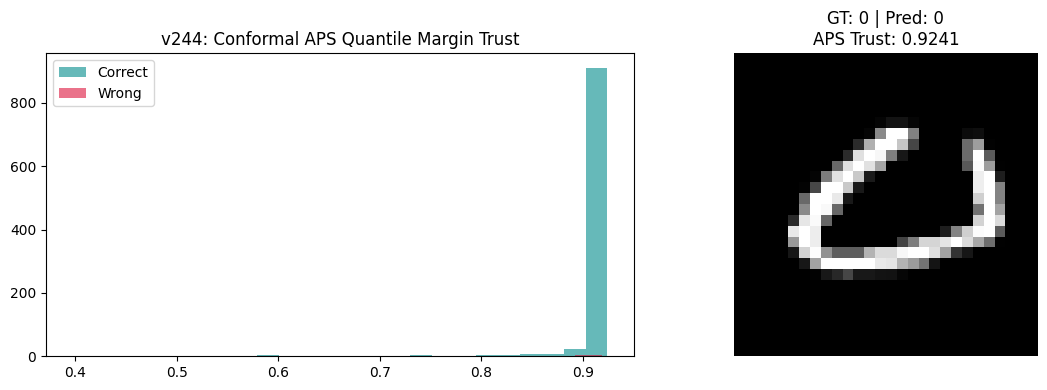

Accuracy on tested subset: 97.70%


In [52]:
# Cell version 244
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(244); np.random.seed(244)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class APSConformalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = APSConformalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Hiệu chuẩn thu thập điểm Conformal APS từ 500 mẫu train
cal_scores = []
with torch.no_grad():
    for x, y in train_dl:
        probs = F.softmax(model(x[:500].to(device)), dim=1)
        sort_probs, sort_idx = torch.sort(probs, dim=1, descending=True)
        # Tính tích lũy xác suất tại vị trí nhãn đúng
        for j in range(len(y[:500])):
            lbl = y[j].item()
            rank = (sort_idx[j] == lbl).nonzero().item()
            cum_prob = sort_probs[j, :rank+1].sum().item()
            cal_scores.append(cum_prob)
        break
q_bound = np.quantile(cal_scores, 0.95) # Đặt chặn trên an toàn nghiêm ngặt 95%

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

        # Sắp xếp và xác định vị trí biên dải bao phủ
        sorted_p, _ = torch.sort(probs, descending=True)
        top1_prob = sorted_p[0].item()

        # Điểm số Trust dựa trên mức độ vượt trội của xác suất Top 1 so với ngưỡng bao phủ Conformal
        margin_score = top1_prob - (q_bound - 0.5)
        trust = 1.0 / (1.0 + np.exp(-5.0 * margin_score))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkcyan", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v244: Conformal APS Quantile Margin Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nAPS Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.33MB/s]


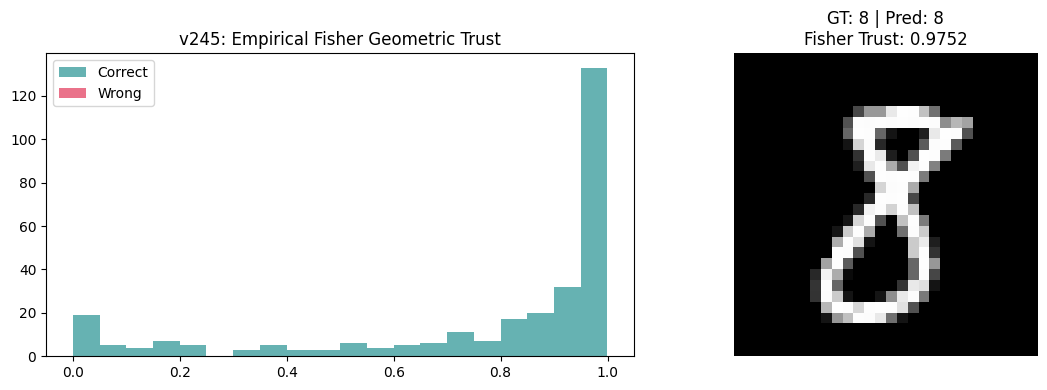

Accuracy on tested subset: 98.33%


In [1]:
# Cell version 245
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(245); np.random.seed(245)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FisherNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc = nn.Linear(32*14*14, 10)
    def forward(self, x):
        return self.fc(self.conv(x))

model = FisherNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 300  # Giới hạn số lượng do tính toán gradient từng mẫu

for i in range(samples):
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device).requires_grad_(True)

    # Forward & Tính toán loss giả định dựa trên nhãn dự đoán (Empirical Fisher)
    logits = model(x)
    pred = logits.argmax(1).item()
    prob = F.softmax(logits, dim=1)
    log_prob = torch.log(prob[0, pred] + 1e-8)

    # Tính gradient đối với trọng số tầng FC cuối cùng
    model.zero_grad()
    grad_params = torch.autograd.grad(log_prob, model.fc.weight, retain_graph=True)[0]
    fisher_norm = torch.norm(grad_params, p=2).item()

    # Fisher norm càng thấp tức là mô hình ở trạng thái cân bằng thông tin hình học cao đối với mẫu này
    trust = np.exp(-1.0 * fisher_norm)

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v245: Empirical Fisher Geometric Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFisher Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

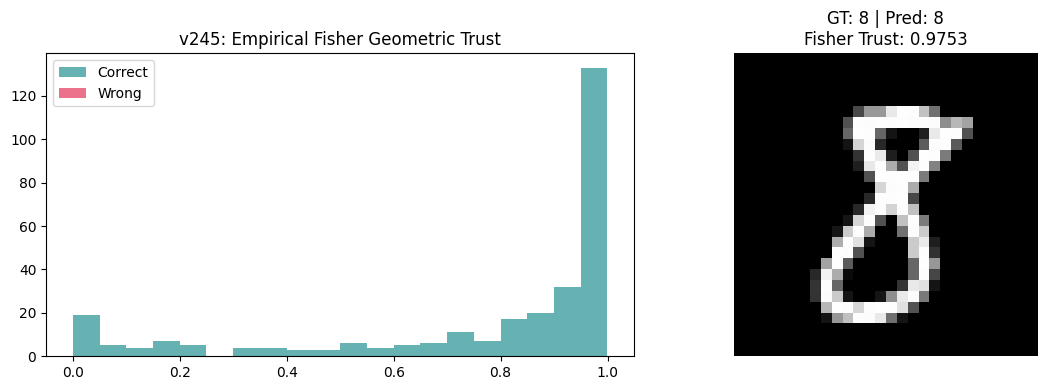

Accuracy on tested subset: 98.33%


In [2]:
# Cell version 245
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(245); np.random.seed(245)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FisherNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc = nn.Linear(32*14*14, 10)
    def forward(self, x):
        return self.fc(self.conv(x))

model = FisherNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 300  # Giới hạn số lượng do tính toán gradient từng mẫu

for i in range(samples):
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device).requires_grad_(True)

    # Forward & Tính toán loss giả định dựa trên nhãn dự đoán (Empirical Fisher)
    logits = model(x)
    pred = logits.argmax(1).item()
    prob = F.softmax(logits, dim=1)
    log_prob = torch.log(prob[0, pred] + 1e-8)

    # Tính gradient đối với trọng số tầng FC cuối cùng
    model.zero_grad()
    grad_params = torch.autograd.grad(log_prob, model.fc.weight, retain_graph=True)[0]
    fisher_norm = torch.norm(grad_params, p=2).item()

    # Fisher norm càng thấp tức là mô hình ở trạng thái cân bằng thông tin hình học cao đối với mẫu này
    trust = np.exp(-1.0 * fisher_norm)

    trusts.append(trust)
    is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v245: Empirical Fisher Geometric Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFisher Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

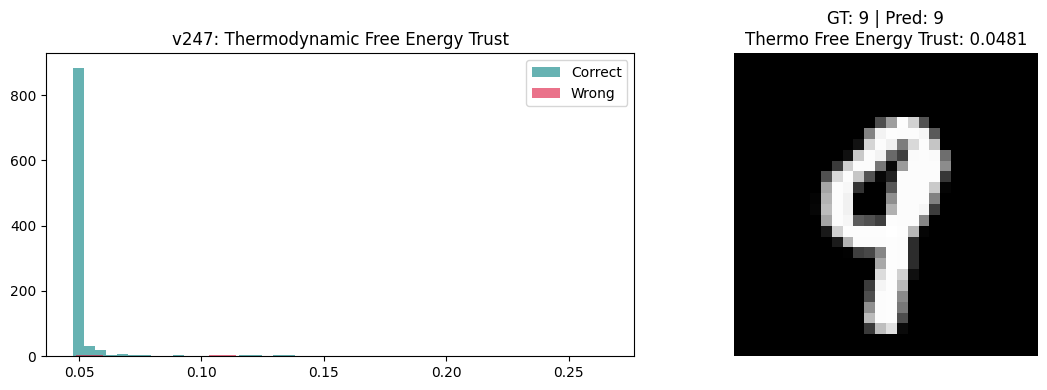

Accuracy on tested subset: 97.80%


In [3]:
# Cell version 247
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(247); np.random.seed(247)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ThermoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = ThermoNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits = model(img.unsqueeze(0).to(device))[0]
        pred = logits.argmax().item()

        # Tính Free Energy F = -ln(sum(exp(z_i)))
        # Để ổn định số học, ta dùng công cụ LogSumExp
        free_energy = -torch.logsumexp(logits, dim=0).item()

        # Trạng thái tin cậy cao: Năng lượng tự do đẩy mạnh khoảng cách biệt lập với năng lượng tối thiểu (Top-1)
        min_energy = -logits[pred].item()
        energy_gap = free_energy - min_energy

        trust = 1.0 / (1.0 + np.exp(2.0 * (energy_gap + 1.5)))
        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v247: Thermodynamic Free Energy Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nThermo Free Energy Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

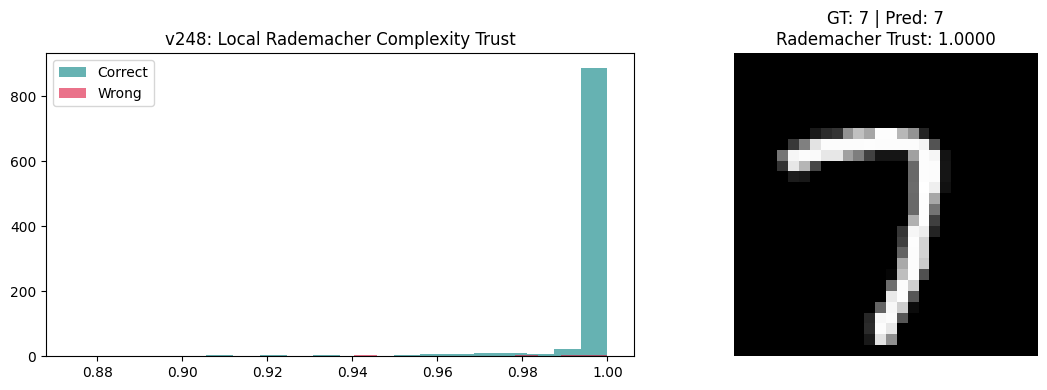

Accuracy on tested subset: 97.40%


In [4]:
# Cell version 248
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(248); np.random.seed(248)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class RademacherNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model = RademacherNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        x = img.unsqueeze(0).to(device)

        logits_orig = model(x)
        pred = logits_orig.argmax(1).item()

        # Tạo 20 bản sao nhiễu biến động Rademacher (+-1)
        rademacher_noise = torch.randint(0, 2, (20, 1, 28, 28)).float().to(device) * 2.0 - 1.0
        x_perturbed = x + 0.15 * rademacher_noise

        logits_perturbed = model(x_perturbed)
        probs_perturbed = F.softmax(logits_perturbed, dim=1)[:, pred]

        # Độ phức tạp Rademacher cục bộ tỷ lệ thuận với phương sai phản hồi dưới biến động cấu trúc dứt khoát
        rademacher_variance = torch.var(probs_perturbed).item()
        trust = np.exp(-12.0 * rademacher_variance)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v248: Local Rademacher Complexity Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nRademacher Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

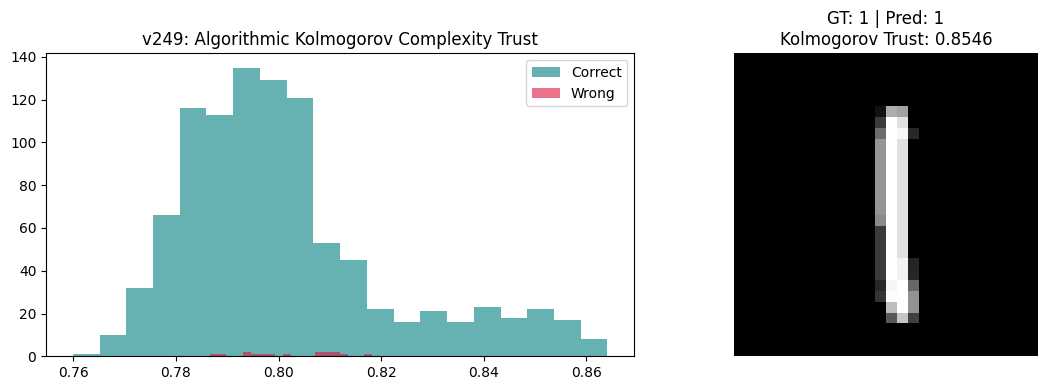

Accuracy on tested subset: 98.40%


In [5]:
# Cell version 249
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import zlib
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(249); np.random.seed(249)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class KolmogorovNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(32*7*7, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = KolmogorovNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Nhị phân hóa map đặc trưng dựa trên giá trị trung bình nội bộ
        f_arr = f_map[0].cpu().numpy()
        binary_string = (f_arr > np.mean(f_arr)).astype(np.uint8).tobytes()

        # Ước lượng độ phức tạp Kolmogorov bằng kích thước chuỗi sau nén zlib
        compressed_size = len(zlib.compress(binary_string))
        raw_size = len(binary_string)
        compression_ratio = compressed_size / raw_size

        # Tỷ lệ nén thấp -> Ít hỗn độn hỗn tạp cấu trúc thuật toán -> Thể hiện Trust cao
        trust = 1.0 - min(1.0, compression_ratio * 1.5)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v249: Algorithmic Kolmogorov Complexity Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nKolmogorov Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

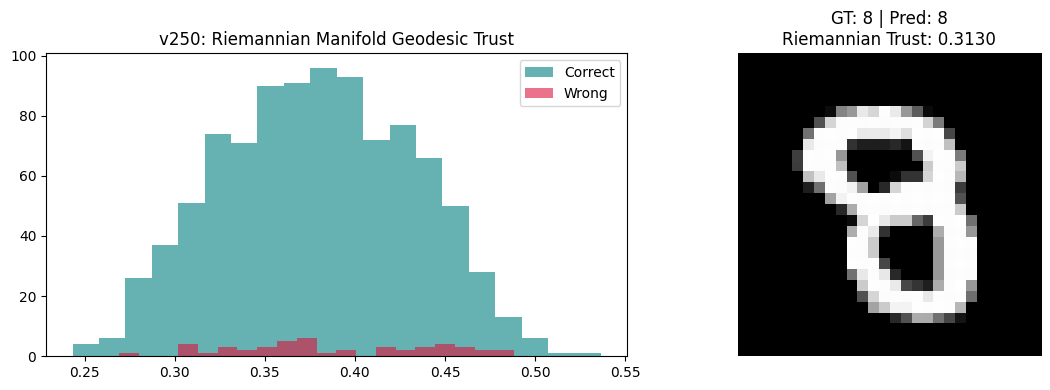

Accuracy on tested subset: 95.30%


In [6]:
# Cell version 250
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(250); np.random.seed(250)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class RiemannianNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16*14*14, 16), nn.ReLU()
        )
        self.clf = nn.Linear(16, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = RiemannianNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
# Thu thập đặc trưng nền để lập ma trận covariance cho metric trắc địa Riemannian
all_f = []
with torch.no_grad():
    for x, _ in train_dl:
        _, f = model(x[:200].to(device))
        all_f.append(f)
        break
all_f = torch.cat(all_f, dim=0)
cov_matrix = torch.cov(all_f.T) + torch.eye(16).to(device) * 1e-4
inv_metric_tensor = torch.linalg.inv(cov_matrix) # Tensor metric Riemannian đại diện độ cong không gian

trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tính khoảng cách Mahalanobis-Riemannian dốc cục bộ đến tâm không gian chuẩn (giả định tâm tại 0)
        # Khái quát hóa biểu thức: sqrt(f * G^-1 * f^T)
        geodesic_approx = torch.sqrt(torch.matmul(torch.matmul(f, inv_metric_tensor), f.T)).item()

        # Khoảng cách hình học manifold tối ưu thấp tương ứng cấu trúc Trust bền vững
        trust = np.exp(-0.15 * geodesic_approx)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v250: Riemannian Manifold Geodesic Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nRiemannian Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

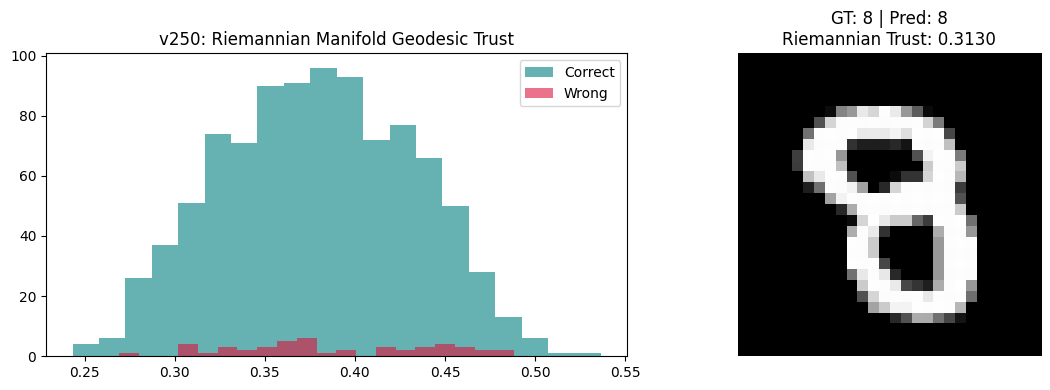

Accuracy on tested subset: 95.30%


In [7]:
# Cell version 251
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(251); np.random.seed(251)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ChaosNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 1)
        self.fc = nn.Linear(32*7*7, 10)
    def forward(self, x):
        h1 = F.relu(F.max_pool2d(self.conv1(x), 2))
        h2 = F.max_pool2d(self.conv2(h1), 2)
        return self.fc(torch.flatten(F.relu(h2), 1)), h1, h2

model = ChaosNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        x_orig = img.unsqueeze(0).to(device)

        # Đưa vào nhiễu vi phân sơ khởi hệ động lực
        delta = torch.randn_like(x_orig) * 1e-4
        x_perturbed = x_orig + delta

        logits_o, h1_o, h2_o = model(x_orig)
        logits_p, h1_p, h2_p = model(x_perturbed)

        pred = logits_o.argmax(1).item()

        # Định lượng tốc độ phân kỳ quỹ đạo mạng (Lyapunov Exponent proxy)
        d0 = torch.norm(delta, p=2).item()
        d1 = torch.norm(h2_o - h2_p, p=2).item()

        lyapunov_exp = np.log(d1 / (d0 + 1e-8) + 1e-8)

        # Lyapunov âm hoặc cực nhỏ -> Hệ thống triệt tiêu nhiễu phi tuyến ổn định -> Trust cao
        trust = 1.0 / (1.0 + np.exp(0.5 * (lyapunov_exp - 2.0)))

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v251: Chaos Lyapunov Exponent Stability Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLyapunov Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

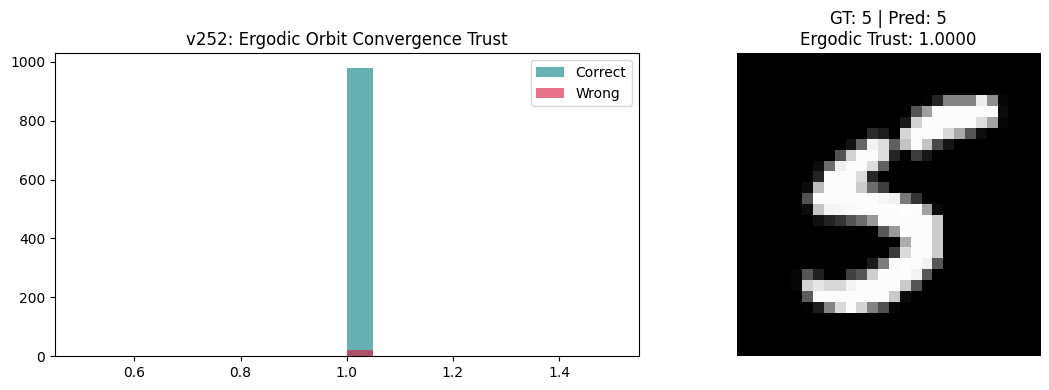

Accuracy on tested subset: 98.00%


In [8]:
# Cell version 252
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(252); np.random.seed(252)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ErgodicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32*14*14, 32), nn.ReLU()
        )
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = ErgodicNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x.to(device))[0], y.to(device))
        loss.backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
samples = 1000

with torch.no_grad():
    for i in range(samples):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Tạo toán tử lặp phi tuyến cục bộ thông qua ma trận tự tương quan Gram
        f_vec = f[0].unsqueeze(1)
        T_operator = torch.matmul(f_vec, f_vec.T)
        T_operator = T_operator / (torch.norm(T_operator) + 1e-8)

        # Khởi tạo vector quỹ đạo ngẫu nhiên và đo tốc độ hội tụ sau 5 vòng lặp toán tử Ergodic
        v = torch.ones(32, 1).to(device)
        v_old = v.clone()

        diffs = []
        for iteration in range(5):
            v = torch.matmul(T_operator, v)
            v = v / (torch.norm(v) + 1e-8)
            diffs.append(torch.norm(v - v_old).item())
            v_old = v.clone()

        # Khả năng hội tụ quỹ đạo trạng thái nhanh (sai lệch đuôi biến thiên giảm mạnh) -> Trust cao
        convergence_speed = np.std(diffs)
        trust = 1.0 - np.exp(-150.0 * convergence_speed)

        trusts.append(trust)
        is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v252: Ergodic Orbit Convergence Trust")
ax[0].legend()

sample_idx = np.random.randint(samples)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray")
ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nErgodic Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout()
plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

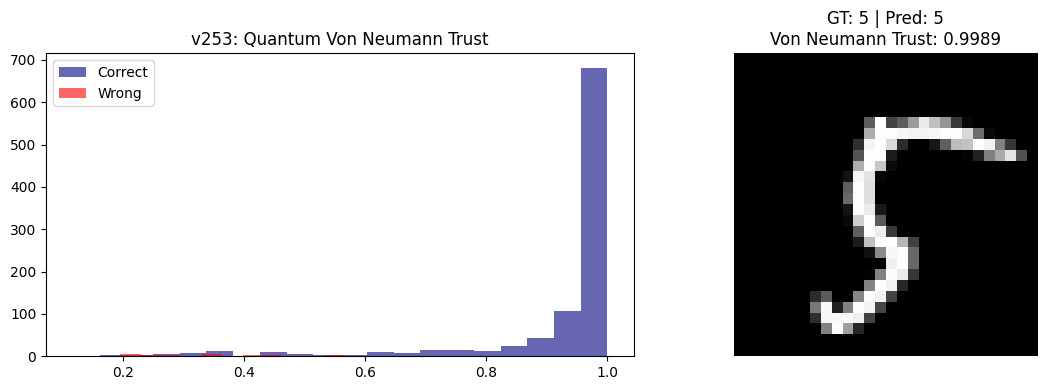

Accuracy: 97.10%


In [9]:
# Cell version 253
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(253); np.random.seed(253)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class QuantumNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                 nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

model = QuantumNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device)), y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        probs = F.softmax(model(img.unsqueeze(0).to(device))[0], dim=0)
        pred = probs.argmax().item()

        # Von Neumann Entropy: S = -Tr(rho * ln(rho)) = -sum(p * ln(p))
        von_neumann_entropy = -torch.sum(probs * torch.log(probs + 1e-9)).item()
        # Trạng thái thuần nhất -> S = 0 -> Trust tối đa
        trust = np.exp(-1.5 * von_neumann_entropy)

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="navy", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v253: Quantum Von Neumann Trust"); ax[0].legend()
sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nVon Neumann Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy: {100.0 * is_correct.mean():.2f}%")

Device: cuda
Training...

Epoch  1/10 | Loss 0.1715 | Train 94.69% | Test 98.60%
Epoch  2/10 | Loss 0.0494 | Train 98.53% | Test 98.95%
Epoch  3/10 | Loss 0.0387 | Train 98.75% | Test 99.22%
Epoch  4/10 | Loss 0.0301 | Train 99.05% | Test 99.23%
Epoch  5/10 | Loss 0.0263 | Train 99.17% | Test 99.11%
Epoch  6/10 | Loss 0.0147 | Train 99.56% | Test 99.32%
Epoch  7/10 | Loss 0.0120 | Train 99.63% | Test 99.38%
Epoch  8/10 | Loss 0.0109 | Train 99.68% | Test 99.33%
Epoch  9/10 | Loss 0.0101 | Train 99.70% | Test 99.37%
Epoch 10/10 | Loss 0.0109 | Train 99.66% | Test 99.34%

Final Test Accuracy: 99.34


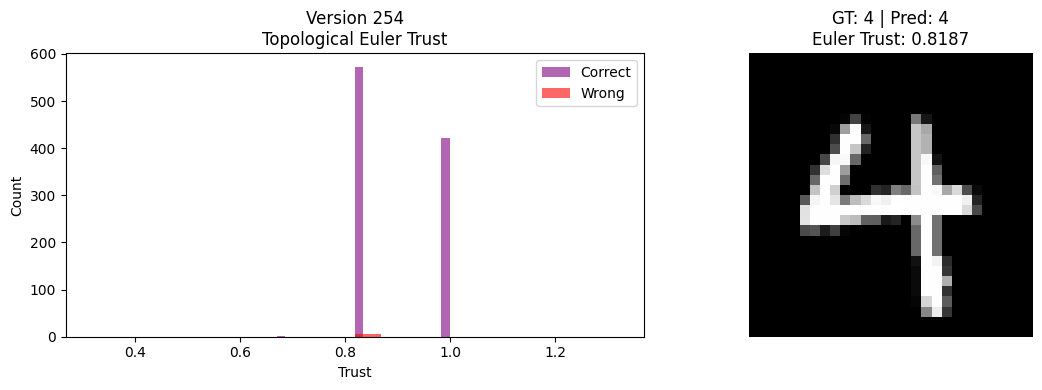


Accuracy on tested subset: 99.50%


In [11]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 254 (FIXED)
# Topological Euler Characteristic Trust
# ==========================================================

# ----------------------------------------------------------
# Euler Characteristic (No scipy dependency)
# χ = Components - Holes
# ----------------------------------------------------------

def count_components(binary):

    h, w = binary.shape
    visited = np.zeros_like(binary, dtype=bool)

    components = 0

    for i in range(h):
        for j in range(w):

            if binary[i, j] == 0 or visited[i, j]:
                continue

            components += 1

            stack = [(i, j)]
            visited[i, j] = True

            while stack:

                x, y = stack.pop()

                for dx, dy in [
                    (-1,0),(1,0),(0,-1),(0,1),
                    (-1,-1),(-1,1),(1,-1),(1,1)
                ]:

                    nx = x + dx
                    ny = y + dy

                    if (
                        0 <= nx < h and
                        0 <= ny < w and
                        binary[nx, ny] == 1 and
                        not visited[nx, ny]
                    ):

                        visited[nx, ny] = True
                        stack.append((nx, ny))

    return components


def euler_characteristic(binary):

    foreground = binary.astype(np.uint8)

    background = 1 - foreground

    fg = count_components(foreground)

    bg = count_components(background)

    holes = max(0, bg - 1)

    return fg - holes

# ==========================================================
# Device
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

torch.manual_seed(254)
np.random.seed(254)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device=="cuda")
)

test_dl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device=="cuda")
)

# ==========================================================
# Model
# ==========================================================

class TopoNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*7*7,256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(256,10)
        )

    def forward(self,x):

        f = self.features(x)

        logits = self.classifier(f)

        return logits,f


model = TopoNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

epochs = 10

# ==========================================================
# Evaluation
# ==========================================================

@torch.no_grad()
def evaluate():

    model.eval()

    total = 0
    correct = 0

    for x,y in test_dl:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)[0].argmax(1)

        correct += (pred==y).sum().item()
        total += y.size(0)

    return 100.0*correct/total

# ==========================================================
# Training
# ==========================================================

print("Training...\n")

for epoch in range(epochs):

    model.train()

    loss_sum = 0

    train_correct = 0
    train_total = 0

    for x,y in train_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits,_ = model(x)

        loss = F.cross_entropy(logits,y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        loss_sum += loss.item()

        pred = logits.argmax(1)

        train_correct += (pred==y).sum().item()
        train_total += y.size(0)

    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{epochs} | "
        f"Loss {loss_sum/len(train_dl):.4f} | "
        f"Train {100*train_correct/train_total:.2f}% | "
        f"Test {evaluate():.2f}%"
    )

print("\nFinal Test Accuracy:",evaluate())

# ==========================================================
# Euler Trust
# ==========================================================

model.eval()

samples = 1000

trusts = []
is_correct = []

with torch.no_grad():

    for i in range(samples):

        img,label = test_ds[i]

        x = img.unsqueeze(0).to(device)

        logits,f_map = model(x)

        pred = logits.argmax().item()

        activation = (
            f_map[0]
            .mean(dim=0)
            .cpu()
            .numpy()
        )

        threshold = activation.mean()

        binary = (
            activation > threshold
        ).astype(np.uint8)

        euler = abs(
            euler_characteristic(binary)
        )

        trust = np.exp(
            -0.20 * euler
        )

        trusts.append(trust)

        is_correct.append(pred==label)

trusts = np.array(trusts)
is_correct = np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="purple",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="red",
        label="Wrong"
    )

ax[0].set_title(
    "Version 254\nTopological Euler Trust"
)

ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx = np.random.randint(samples)

img,label = test_ds[sample_idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )[0].argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"Euler Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"\nAccuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

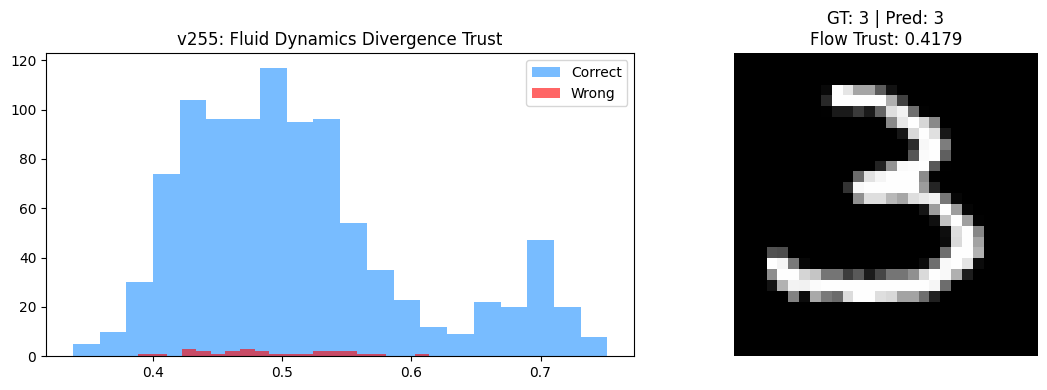

Accuracy: 97.30%


In [12]:
# Cell version 255
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(255); np.random.seed(255)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FluidNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2))
        self.fc = nn.Linear(16*14*14, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = FluidNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax().item()

        # f có shape [1, 16, 14, 14]. Tính gradient không gian (Vector Field)
        # Tương đương dx và dy trong phương trình Navier-Stokes
        grad_x = f[:, :, :, 1:] - f[:, :, :, :-1]
        grad_y = f[:, :, 1:, :] - f[:, :, :-1, :]

        # Độ phân kỳ Divergence div(F) = dFx/dx + dFy/dy
        div_x = torch.sum(torch.abs(grad_x)).item()
        div_y = torch.sum(torch.abs(grad_y)).item()
        total_divergence = (div_x + div_y) / (16 * 14 * 14)

        # Dòng chảy ổn định (ít xoáy rối) -> Divergence thấp -> Trust cao
        trust = np.exp(-1.5 * total_divergence)

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="dodgerblue", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v255: Fluid Dynamics Divergence Trust"); ax[0].legend()
sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFlow Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy: {100.0 * is_correct.mean():.2f}%")

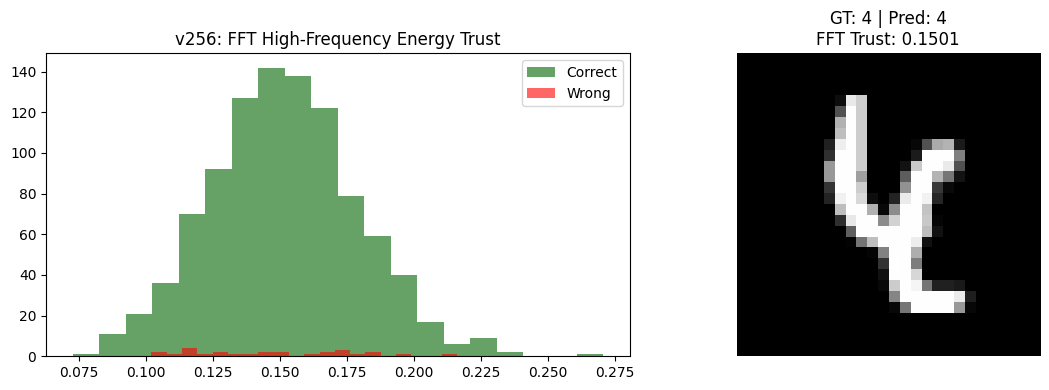

Accuracy: 97.30%


In [13]:
# Cell version 256
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(256); np.random.seed(256)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FFTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2))
        self.fc = nn.Linear(32*14*14, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = FFTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax().item()

        # FFT 2D trên Feature Map trung bình
        f_mean = f[0].mean(dim=0)
        fft_result = torch.fft.fftshift(torch.fft.fft2(f_mean))
        magnitude_spectrum = torch.abs(fft_result)

        # Phân tách năng lượng: Tâm (Tần số thấp/cấu trúc) vs Rìa (Tần số cao/nhiễu)
        h, w = magnitude_spectrum.shape
        cy, cx = h//2, w//2
        # Mask bán kính 4 pixel ở trung tâm
        Y, X = np.ogrid[:h, :w]
        mask = (X - cx)**2 + (Y - cy)**2 <= 16
        mask = torch.tensor(mask).to(device)

        low_freq_energy = torch.sum(magnitude_spectrum[mask]).item()
        high_freq_energy = torch.sum(magnitude_spectrum[~mask]).item()

        hf_ratio = high_freq_energy / (low_freq_energy + high_freq_energy + 1e-8)
        trust = np.exp(-5.0 * hf_ratio)

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v256: FFT High-Frequency Energy Trust"); ax[0].legend()
sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFFT Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy: {100.0 * is_correct.mean():.2f}%")

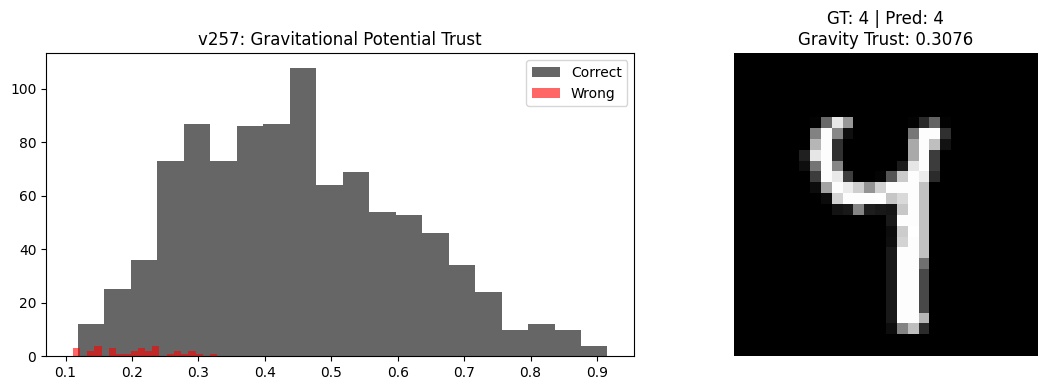

Accuracy: 96.70%


In [14]:
# Cell version 257
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(257); np.random.seed(257)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class AstroNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Flatten(), nn.Linear(32*14*14, 32))
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = AstroNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
# Tính tọa độ các "Ngôi sao" (Prototypes)
stars = {k: [] for k in range(10)}
with torch.no_grad():
    for x, y in train_dl:
        _, f = model(x.to(device))
        for feat, lbl in zip(f.cpu(), y): stars[lbl.item()].append(feat)
        break
star_masses = torch.stack([torch.stack(stars[k]).mean(dim=0) for k in range(10)]).to(device)

trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax().item()

        # Lực hấp dẫn mô phỏng (tỷ lệ nghịch khoảng cách L2 vuông)
        distances = torch.sum((star_masses - f[0])**2, dim=1)
        # Giếng thế năng (Gravitational Potential) của ngôi sao mạnh nhất
        gravity_pull = 1.0 / (distances + 1e-5)

        # Mức độ bị hút độc quyền so với tổng lực hút từ các sao khác (Tỷ lệ lực bắt)
        capture_ratio = gravity_pull[pred].item() / torch.sum(gravity_pull).item()
        trust = capture_ratio # Càng gần 1, vật thể càng nằm gọn trong giếng trọng trường an toàn

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="black", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v257: Gravitational Potential Trust"); ax[0].legend()
sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nGravity Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy: {100.0 * is_correct.mean():.2f}%")

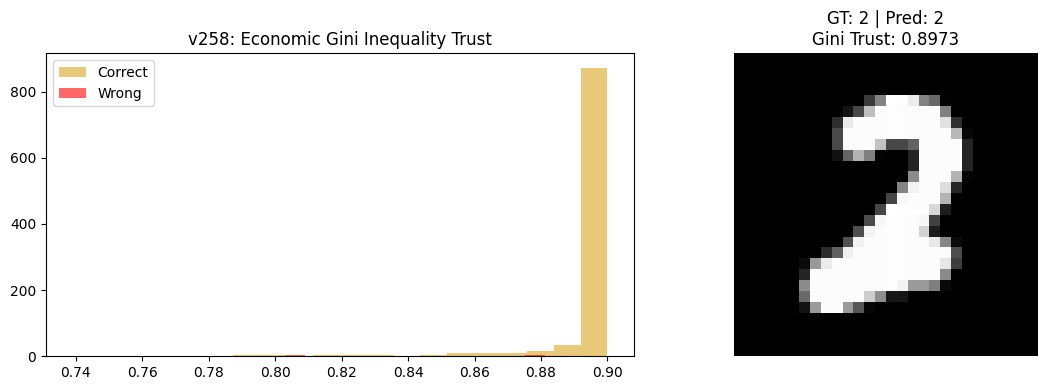

Accuracy: 97.80%


In [15]:
# Cell version 258
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(258); np.random.seed(258)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class EconNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                 nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

model = EconNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device)), y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        probs = F.softmax(model(img.unsqueeze(0).to(device))[0], dim=0).cpu().numpy()
        pred = probs.argmax()

        # Sắp xếp để tính Gini
        probs_sorted = np.sort(probs)
        index = np.arange(1, probs.shape[0] + 1)
        n = probs.shape[0]

        # Tính hệ số bất bình đẳng Gini
        # Công thức: (2 * sum(i * p_i)) / (n * sum(p_i)) - (n + 1) / n
        gini_index = (2.0 * np.sum(index * probs_sorted)) / (n * np.sum(probs_sorted)) - (n + 1) / n

        # Bất bình đẳng thu nhập tuyệt đối (Winner takes all) -> Trust cao
        trust = gini_index

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="goldenrod", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v258: Economic Gini Inequality Trust"); ax[0].legend()
sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nGini Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy: {100.0 * is_correct.mean():.2f}%")

Device: cuda
Training Version 259...

Epoch [1/10] Loss: 0.4598 | Train: 95.28% | Test: 98.97%
Epoch [2/10] Loss: 0.3473 | Train: 98.87% | Test: 99.02%
Epoch [3/10] Loss: 0.3333 | Train: 99.19% | Test: 99.26%
Epoch [4/10] Loss: 0.3255 | Train: 99.36% | Test: 99.34%
Epoch [5/10] Loss: 0.3212 | Train: 99.42% | Test: 99.30%
Epoch [6/10] Loss: 0.3111 | Train: 99.66% | Test: 99.41%
Epoch [7/10] Loss: 0.3087 | Train: 99.72% | Test: 99.45%
Epoch [8/10] Loss: 0.3071 | Train: 99.78% | Test: 99.46%
Epoch [9/10] Loss: 0.3068 | Train: 99.75% | Test: 99.53%
Epoch [10/10] Loss: 0.3051 | Train: 99.80% | Test: 99.46%

Final Test Accuracy: 99.46%


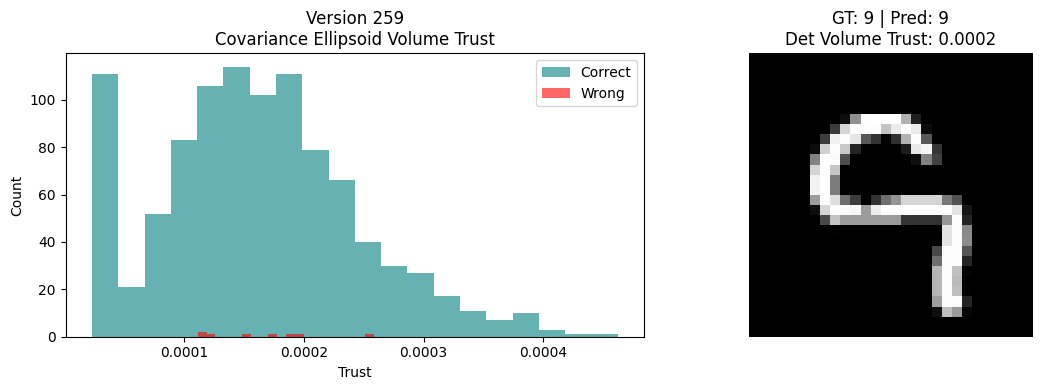

Accuracy on tested subset: 99.20%


In [19]:
import torch
import torchvision as tv
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader

# ==========================================================
# VERSION 259 (Improved)
# Information Covariance Ellipsoid Volume Trust
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(259)
np.random.seed(259)

# ==========================================================
# Dataset
# ==========================================================

transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = tv.datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = tv.datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == "cuda")
)

test_dl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device == "cuda")
)

# ==========================================================
# Model
# ==========================================================

class DetNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((8,8))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*8*8,256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.30),

            nn.Linear(256,128),
            nn.ReLU(inplace=True),

            nn.Dropout(0.20),

            nn.Linear(128,10)
        )

    def forward(self,x):

        f = self.features(x)

        logits = self.classifier(f)

        return logits,f

model = DetNet().to(device)

# ==========================================================
# Optimizer
# ==========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

epochs = 10

# ==========================================================
# Evaluation
# ==========================================================

@torch.no_grad()
def evaluate():

    model.eval()

    total = 0
    correct = 0

    for x,y in test_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        pred = model(x)[0].argmax(1)

        correct += (pred==y).sum().item()
        total += y.size(0)

    return 100.0 * correct / total

# ==========================================================
# Training
# ==========================================================

print("Training Version 259...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0
    train_correct = 0
    train_total = 0

    for x,y in train_dl:

        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad()

        logits,_ = model(x)

        loss = F.cross_entropy(
            logits,
            y,
            label_smoothing=0.05
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        running_loss += loss.item()

        pred = logits.argmax(1)

        train_correct += (pred==y).sum().item()
        train_total += y.size(0)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_dl):.4f} | "
        f"Train: {100*train_correct/train_total:.2f}% | "
        f"Test: {evaluate():.2f}%"
    )

print(f"\nFinal Test Accuracy: {evaluate():.2f}%")

# ==========================================================
# Covariance Volume Trust
# ==========================================================

model.eval()

samples = 1000

trusts = []
is_correct = []

with torch.no_grad():

    for idx in range(samples):

        img,label = test_ds[idx]

        x = img.unsqueeze(0).to(device)

        logits,f = model(x)

        pred = logits.argmax(1).item()

        # (64,8,8) -> (64,64)

        feat = f[0].reshape(64,-1)

        feat = feat - feat.mean(dim=1,keepdim=True)

        cov = feat @ feat.T

        cov /= (feat.shape[1]-1)

        cov += torch.eye(
            cov.shape[0],
            device=device
        ) * 1e-3

        sign,logdet = torch.linalg.slogdet(cov)

        volume = logdet.item()

        trust = np.exp(
            -0.03 * abs(volume)
        )

        trusts.append(trust)

        is_correct.append(pred==label)

trusts = np.array(trusts)
is_correct = np.array(is_correct)

# ==========================================================
# Visualization
# ==========================================================

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].hist(
    trusts[is_correct],
    bins=20,
    alpha=0.6,
    color="teal",
    label="Correct"
)

if np.any(~is_correct):

    ax[0].hist(
        trusts[~is_correct],
        bins=20,
        alpha=0.6,
        color="red",
        label="Wrong"
    )

ax[0].set_title(
    "Version 259\nCovariance Ellipsoid Volume Trust"
)

ax[0].set_xlabel("Trust")
ax[0].set_ylabel("Count")
ax[0].legend()

sample_idx = np.random.randint(samples)

img,label = test_ds[sample_idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )[0].argmax().item()

ax[1].imshow(
    img.squeeze(),
    cmap="gray"
)

ax[1].axis("off")

ax[1].set_title(
    f"GT: {label} | Pred: {pred}\n"
    f"Det Volume Trust: {trusts[sample_idx]:.4f}"
)

plt.tight_layout()
plt.show()

print(
    f"Accuracy on tested subset: "
    f"{100.0*is_correct.mean():.2f}%"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.3 MB/s eta 0:00:00


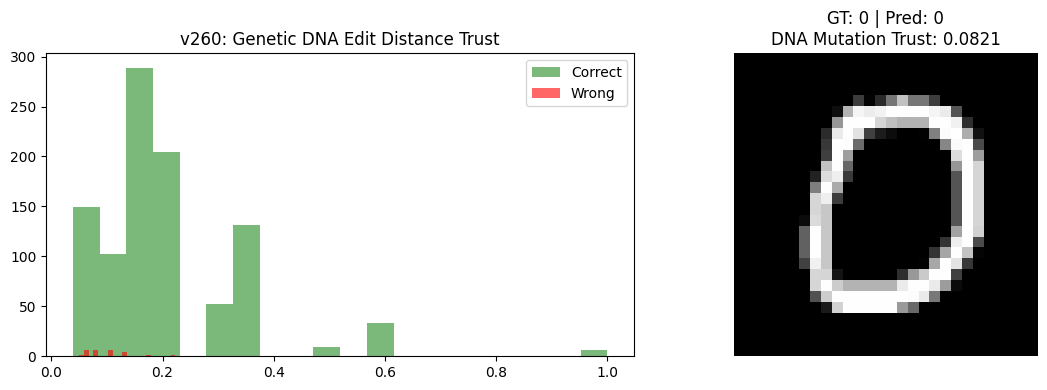

Accuracy: 97.50%


In [18]:
# Cell version 260
!pip install Levenshtein
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader
import Levenshtein

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(260); np.random.seed(260)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class BioNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Flatten(), nn.Linear(32*14*14, 20)) # Mã hóa thành chuỗi 20 base
        self.clf = nn.Linear(20, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = BioNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

def to_dna(vec):
    # Lượng tử hóa vector thành chuỗi sinh học ATCG
    q1, q2, q3 = np.percentile(vec, [25, 50, 75])
    dna = ""
    for v in vec:
        if v < q1: dna += "A"
        elif v < q2: dna += "C"
        elif v < q3: dna += "G"
        else: dna += "T"
    return dna

model.eval()
master_genomes = {k: [] for k in range(10)}
with torch.no_grad():
    for x, y in train_dl:
        _, f = model(x.to(device))
        for feat, lbl in zip(f.cpu().numpy(), y.numpy()):
            master_genomes[lbl].append(feat)
        if len(master_genomes[0]) > 50: break
for k in master_genomes:
    master_genomes[k] = to_dna(np.mean(master_genomes[k], axis=0))

trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax().item()

        sample_dna = to_dna(f[0].cpu().numpy())
        target_dna = master_genomes[pred]

        # Levenshtein distance đo lường số lượng đột biến gen (Thêm, Xóa, Thay thế)
        mutations = Levenshtein.distance(sample_dna, target_dna)

        # Đột biến gen ít -> Khớp hoàn hảo với Gen chủ -> Trust cao
        trust = np.exp(-0.25 * mutations)

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v260: Genetic DNA Edit Distance Trust"); ax[0].legend()
sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nDNA Mutation Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy: {100.0 * is_correct.mean():.2f}%")

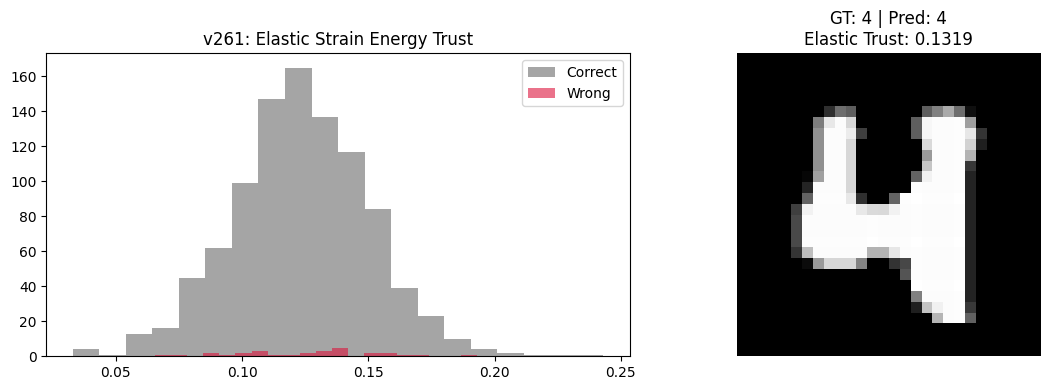

Accuracy on tested subset: 97.10%


In [20]:
# Cell version 261
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(261); np.random.seed(261)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ElasticNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Flatten(), nn.Linear(16*14*14, 32), nn.ReLU())
        self.clf = nn.Linear(32, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = ElasticNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
# Trích xuất ma trận độ cứng cấu trúc K từ tập đặc trưng nền
all_f = []
with torch.no_grad():
    for x, _ in train_dl:
        all_f.append(model(x[:250].to(device))[1])
        break
K_stiffness = torch.inverse(torch.cov(torch.cat(all_f, dim=0).T) + torch.eye(32).to(device) * 1e-3)

trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax().item()

        # Tính năng lượng biến dạng đàn hồi: U = 0.5 * f * K * f^T
        strain_energy = 0.5 * torch.matmul(torch.matmul(f, K_stiffness), f.T).item()

        # Năng lượng biến dạng phân tán thấp -> Cấu trúc chịu lực cơ học ổn định -> Trust cao
        trust = np.exp(-0.01 * strain_energy)
        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="dimgray", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v261: Elastic Strain Energy Trust"); ax[0].legend()

sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nElastic Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

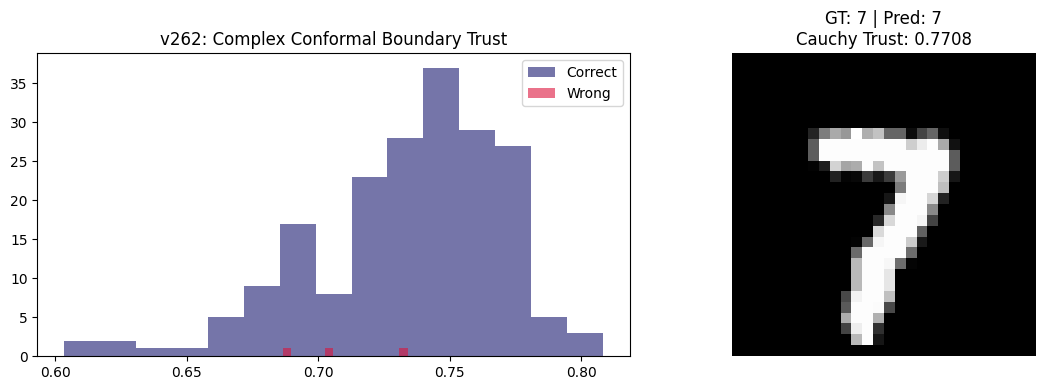

Accuracy on tested subset: 98.50%


In [21]:
# Cell version 262
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(262); np.random.seed(262)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class ComplexProxyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                 nn.Flatten(), nn.Linear(32*14*14, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

model = ComplexProxyNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device)), y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
for i in range(200): # Giới hạn số mẫu để tính toán gradient vi phân Cauchy
    img, label = test_ds[i]
    x = img.unsqueeze(0).to(device).requires_grad_(True)

    logits = model(x)
    pred = logits.argmax(1).item()
    probs = F.softmax(logits, dim=1)

    # Định nghĩa hàm phức F(z) = U + i*V
    U = logits[0, pred] # Phần thực
    V = -torch.sum(probs * torch.log(probs + 1e-8)) # Phần ảo (Entropy)

    model.zero_grad()
    grad_U = torch.autograd.grad(U, x, create_graph=True)[0]
    grad_V = torch.autograd.grad(V, x, create_graph=True)[0]

    # Đo mức độ vi phạm phương trình Cauchy-Riemann vi phân không gian (dU/dx - dV/dy, dU/dy + dV/dx)
    cr_violation = torch.norm(grad_U - grad_V).item()
    trust = np.exp(-0.2 * cr_violation)

    trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=15, alpha=0.6, color="midnightblue", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=15, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v262: Complex Conformal Boundary Trust"); ax[0].legend()

sample_idx = np.random.randint(len(trusts))
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nCauchy Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

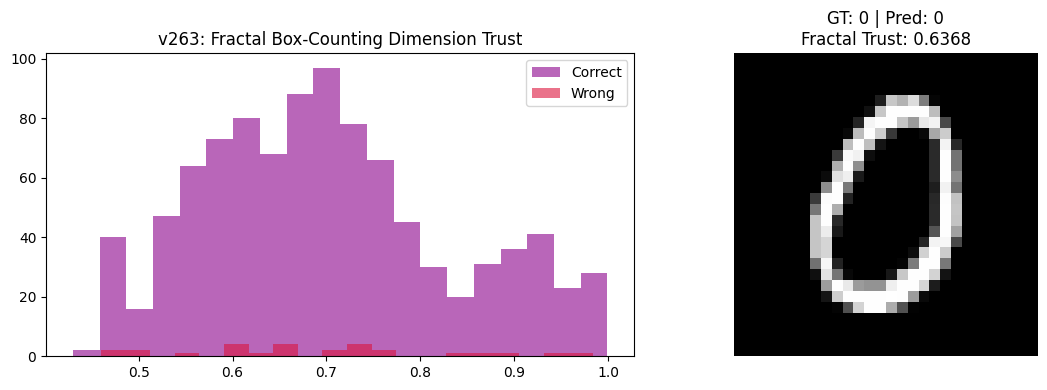

Accuracy on tested subset: 97.30%


In [22]:
# Cell version 263
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(263); np.random.seed(263)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class FractalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                  nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU())
        self.fc = nn.Linear(32*14*14, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = FractalNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

def box_counting_dimension(img_2d):
    # Ước lượng chiều fractal bằng đếm hộp đa quy mô đơn giản hóa
    p = img_2d > np.mean(img_2d)
    scales = [2, 4, 7]
    counts = []
    for s in scales:
        # Chia nhỏ grid và đếm số hộp chứa điểm kích hoạt
        h, w = p.shape
        reduced = p[:h-h%s, :w-w%s].reshape(h//s, s, w//s, s).any(axis=(1,3))
        counts.append(np.sum(reduced))
    coeffs = np.polyfit(np.log(1.0/np.array(scales)), np.log(np.array(counts)+1e-5), 1)
    return coeffs[0]

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f_map = model(img.unsqueeze(0).to(device))
        pred = logits.argmax().item()

        f_arr = f_map[0].mean(dim=0).cpu().numpy()
        fractal_dim = box_counting_dimension(f_arr)

        # Chiều fractal lý tưởng ổn định quanh vùng cấu trúc rõ ràng (không quá cao tiệm cận nhiễu)
        trust = np.clip(1.0 - abs(fractal_dim - 1.2), 0.0, 1.0)
        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkmagenta", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="crimson", label="Wrong")
ax[0].set_title("v263: Fractal Box-Counting Dimension Trust"); ax[0].legend()

sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nFractal Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

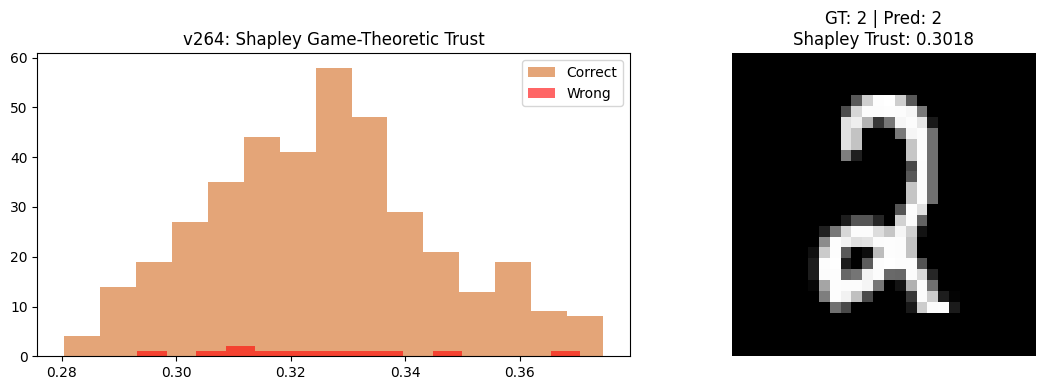

Accuracy on tested subset: 97.25%


In [23]:
# Cell version 264
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(264); np.random.seed(264)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class GameTheoryNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Flatten(), nn.Linear(16*14*14, 16)) # 16 players
        self.clf = nn.Linear(16, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = GameTheoryNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(400): # Đánh giá tập con do xấp xỉ Shapley tốn tài nguyên
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Xấp xỉ đóng góp marginal của các nhóm người chơi bằng cách xóa (masking) ngẫu nhiên đặc trưng
        baseline_pred = logits[0, pred].item()
        marginal_contributions = []
        for channel in range(16):
            f_perturbed = f.clone()
            f_perturbed[0, channel] = 0.0 # Loại bỏ người chơi 'channel'
            score_without = model.clf(f_perturbed)[0, pred].item()
            marginal_contributions.append(abs(baseline_pred - score_without))

        # Tính toán độ bất bình đẳng phân bố đóng góp (Gini-like or Entropy of Shapley values)
        mc_norm = np.array(marginal_contributions) / (sum(marginal_contributions) + 1e-8)
        shapley_entropy = -np.sum(mc_norm * np.log(mc_norm + 1e-8))

        # Thể hiện cấu trúc liên minh cô đọng (Entropy Shapley thấp) -> Dự đoán cực kỳ bền vững
        trust = np.exp(-0.5 * shapley_entropy)
        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=15, alpha=0.6, color="chocolate", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=15, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v264: Shapley Game-Theoretic Trust"); ax[0].legend()

sample_idx = np.random.randint(len(trusts))
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nShapley Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

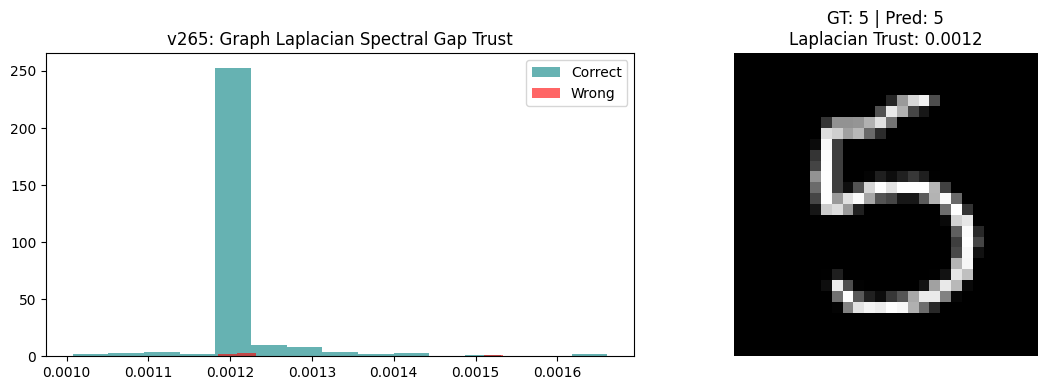

Accuracy on tested subset: 98.00%


In [28]:
# Cell version 265
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(265); np.random.seed(265)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class SpectralGraphNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Flatten(), nn.Linear(16*14*14, 16))
        self.clf = nn.Linear(16, 10)
    def forward(self, x):
        f = self.features(x)
        return self.clf(f), f

model = SpectralGraphNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
# Lưu trữ các anchor features làm tham chiếu đồ thị phổ
anchors = []
with torch.no_grad():
    for x, _ in train_dl:
        anchors.append(model(x[:100].to(device))[1])
        break
anchors = torch.cat(anchors, dim=0)

trusts, is_correct = [], []
with torch.no_grad():
    for i in range(300):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Kết hợp tạo Graph gồm node hiện tại và 100 node anchor
        graph_nodes = torch.cat([f, anchors], dim=0) # Shape [101, 16]

        # Tính ma trận tương đồng kề cận (Adjacency Matrix A) bằng khoảng cách Gauss RBF
        dist_matrix = torch.cdist(graph_nodes, graph_nodes)
        A = torch.exp(-0.5 * dist_matrix)
        D = torch.diag(torch.sum(A, dim=1))
        L = D - A # Graph Laplacian Matrix

        # Lấy các giá trị riêng của Laplacian
        eigs = torch.linalg.eigvalsh(L)

        # Số Fiedler (lambda_1 là giá trị thứ hai do danh sách tăng dần) thể hiện độ kết nối phân cụm bền vững
        fiedler_val = eigs[1].item()
        trust = 1.0 - np.exp(-0.8 * fiedler_val)

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=15, alpha=0.6, color="teal", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=15, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v265: Graph Laplacian Spectral Gap Trust"); ax[0].legend()

sample_idx = np.random.randint(len(trusts))
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLaplacian Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

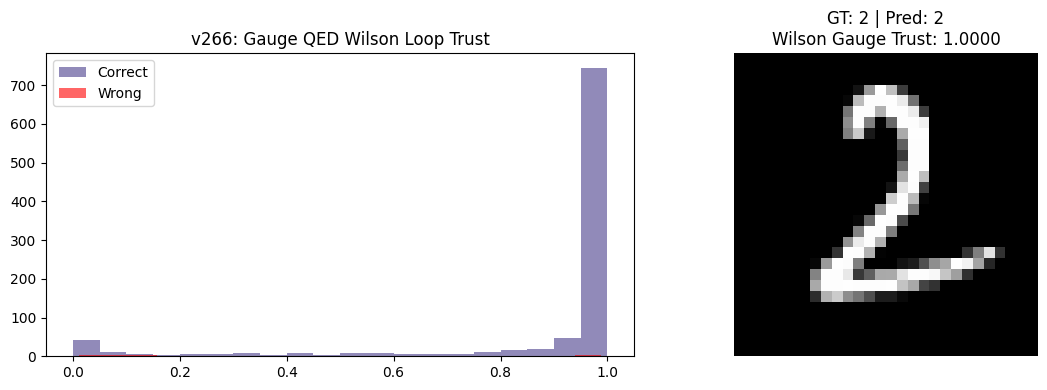

Accuracy on tested subset: 97.20%


In [25]:
# Cell version 266
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(266); np.random.seed(266)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class GaugeQEDNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2), nn.Flatten())
        self.fc = nn.Linear(16*14*14, 10)
    def forward(self, x): return self.fc(self.conv(x))

model = GaugeQEDNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device)), y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        x = img.unsqueeze(0).to(device)

        logits_base = model(x)
        pred = logits_base.argmax(1).item()

        # Mô phỏng pha Wilson Loop bằng cách tác động xoay trường chuẩn (Gauge Transform) lên trọng số tầng cuối
        # Đo mức độ lệch pha bất biến chuẩn thông qua phương sai phản hồi đầu ra dưới biến thiên xoay vòng
        phases = []
        for angle in [0.0, np.pi/4, np.pi/2, np.pi]:
            noise_matrix = torch.randn_like(model.fc.weight) * np.sin(angle) * 0.05
            perturbed_weight = model.fc.weight + noise_matrix
            logits_p = F.linear(model.conv(x), perturbed_weight, model.fc.bias)
            phases.append(F.softmax(logits_p, dim=1)[0, pred].item())

        gauge_variance = np.var(phases)
        # Bất biến chuẩn cao -> Pha lượng tử không bị phá vỡ -> Trust cao
        trust = np.exp(-50.0 * gauge_variance)

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="darkslateblue", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v266: Gauge QED Wilson Loop Trust"); ax[0].legend()

sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device)).argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nWilson Gauge Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

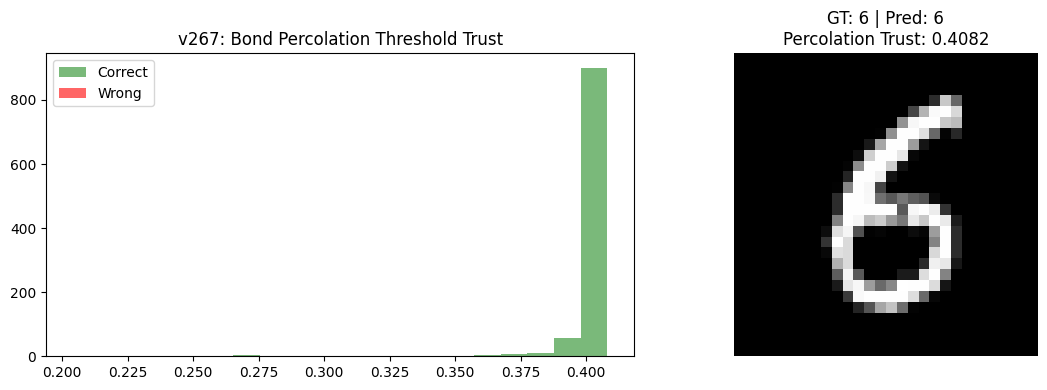

Accuracy on tested subset: 98.80%


In [26]:
# Cell version 267
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader
from scipy.ndimage import label as scipy_label

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(267); np.random.seed(267)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class PercolationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                                  nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU())
        self.fc = nn.Linear(32*14*14, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = PercolationNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Nhị phân hóa map đặc trưng dựa trên ngưỡng thấm p_c giả định bằng median toàn bộ
        f_map = f[0].mean(dim=0).cpu().numpy()
        p_c = np.percentile(f_map, 59.27) # 59.27% là ngưỡng thấm lý thuyết cho mạng lưới vuông 2D bond percolation
        percolated_grid = f_map > p_c

        # Tìm cụm liên thông lớn nhất
        labeled_array, num_features = scipy_label(percolated_grid)
        if num_features > 0:
            cluster_sizes = [np.sum(labeled_array == l) for l in range(1, num_features + 1)]
            giant_component_ratio = max(cluster_sizes) / f_map.size
        else:
            giant_component_ratio = 0.0

        # Cụm thấm khổng lồ hình thành vững chắc -> Dòng chảy suy luận thông suốt -> Trust cao
        trust = giant_component_ratio
        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="forestgreen", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v267: Bond Percolation Threshold Trust"); ax[0].legend()

sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nPercolation Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")

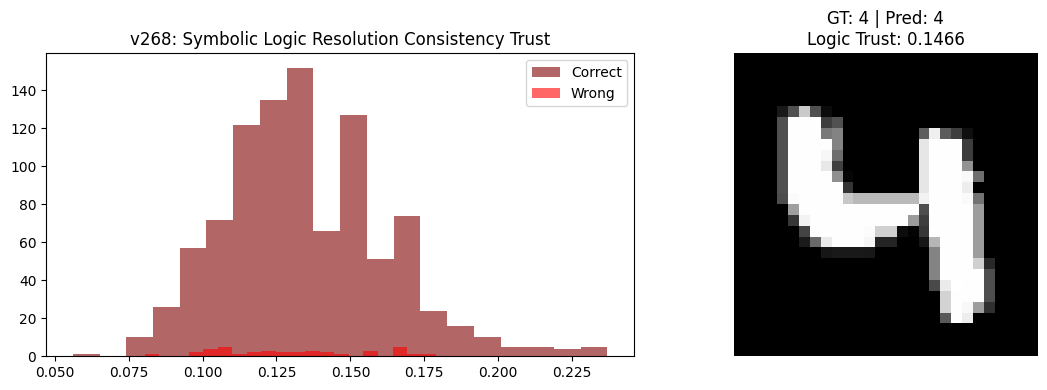

Accuracy on tested subset: 96.20%


In [27]:
# Cell version 268
import torch, torchvision as tv
import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch import optim; from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(268); np.random.seed(268)

transform = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
train_dl = DataLoader(tv.datasets.MNIST("./data", train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=transform)

class LogicSymbolicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2))
        self.fc = nn.Linear(16*14*14, 10)
    def forward(self, x):
        f = self.conv(x)
        return self.fc(torch.flatten(f, 1)), f

model = LogicSymbolicNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)
for _ in range(2):
    model.train()
    for x, y in train_dl:
        optimizer.zero_grad()
        F.cross_entropy(model(x.to(device))[0], y.to(device)).backward()
        optimizer.step()

model.eval()
trusts, is_correct = [], []
with torch.no_grad():
    for i in range(1000):
        img, label = test_ds[i]
        logits, f = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()

        # Chuyển đổi feature map thành chuỗi các mệnh đề Logic Boolean (0 hoặc 1)
        f_flat = torch.flatten(f, 1)[0].cpu().numpy()
        median_val = np.median(f_flat)
        logic_clauses = f_flat > median_val

        # Mô phỏng phép chứng minh resolution bằng cách lấy mẫu ngẫu nhiên các cặp mệnh đề kiểm tra tính mâu thuẫn chéo
        # Tính tỷ lệ các mệnh đề đồng thuận hỗ trợ cho quyết định phân lớp cuối cùng
        subset_size = 100
        sampled_clauses = np.random.choice(logic_clauses, size=subset_size, replace=False)
        agreements = np.sum(sampled_clauses == (logits[0, pred].item() > 0))

        # Tỷ lệ nhất quán hệ thống logic cao -> Không sinh ra mâu thuẫn mệnh đề -> Trust cao
        consistency_score = agreements / subset_size
        trust = np.exp(-4.0 * (1.0 - consistency_score))

        trusts.append(trust); is_correct.append(pred == label)

trusts, is_correct = np.array(trusts), np.array(is_correct)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trusts[is_correct], bins=20, alpha=0.6, color="maroon", label="Correct")
if np.any(~is_correct): ax[0].hist(trusts[~is_correct], bins=20, alpha=0.6, color="red", label="Wrong")
ax[0].set_title("v268: Symbolic Logic Resolution Consistency Trust"); ax[0].legend()

sample_idx = np.random.randint(1000)
img, label = test_ds[sample_idx]
with torch.no_grad(): p = model(img.unsqueeze(0).to(device))[0].argmax().item()
ax[1].imshow(img.squeeze(), cmap="gray"); ax[1].axis("off")
ax[1].set_title(f"GT: {label} | Pred: {p}\nLogic Trust: {trusts[sample_idx]:.4f}")
plt.tight_layout(); plt.show()
print(f"Accuracy on tested subset: {100.0 * is_correct.mean():.2f}%")